# Correlation Analysis
Analysis of the correlation between all the data features.

# 0. Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, f_oneway, chi2_contingency

sns.set_theme()

plt.rcParams['figure.figsize'] = (7, 5)

# 1. Load data

Get data, creating helper functions during the way. Those will be add to utilitary files later in order to be used in models' files.

## 1. 1. Sales data

In [3]:
df_sales = pd.read_csv('../data/train.csv', index_col='id')

df_sales['date'] = pd.to_datetime(df_sales['date'])

print(len(df_sales))
display(df_sales)

3000888


,date,store_nbr,family,sales,onpromotion
id,,,,,
0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,2013-01-01,1,BABY CARE,0.000,0
2,2013-01-01,1,BEAUTY,0.000,0
3,2013-01-01,1,BEVERAGES,0.000,0
4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0
3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,2017-08-15,9,PRODUCE,2419.729,148


## 1. 2. Oil data

In [4]:
def load_oil_data_and_merge(df_sales: pd.DataFrame, oil_data_path: str) -> pd.DataFrame:
    """
    Load oil data and merge it with the sales data.

    Args:
        df_sales (pd.DataFrame): pandas DataFrame with
            the sales data.
        oil_data_path (str): path to the oil data.

    Returns:
        df_sales (pd.DataFrame): original sales DataFrame
            with the oil data merged to it.
    """
    # Load oil data
    df_oil = pd.read_csv(oil_data_path)

    # Cast `date` column to datetime
    df_oil['date'] = pd.to_datetime(df_oil['date'])

    # Fill date gaps
    df_oil = df_oil.set_index('date').sort_index()

    full_idx = pd.date_range(start=df_oil.index.min(), end=df_oil.index.max(), freq='D')
    df_oil = df_oil.reindex(full_idx)

    df_oil['dcoilwtico'] = (
        df_oil['dcoilwtico']
        .interpolate(method='linear', limit_direction='both')
    )

    df_oil.index.name = 'date'
    
    df_oil = df_oil.reset_index()

    # Merge dataframes and return
    df_sales = df_sales.merge(df_oil, on='date', how='left')

    return df_sales


df_sales = load_oil_data_and_merge(
    df_sales=df_sales,
    oil_data_path='../data/oil.csv'
)

print(len(df_sales))
display(df_sales)

3000888


,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,1,AUTOMOTIVE,0.000,0,93.14
1,2013-01-01,1,BABY CARE,0.000,0,93.14
2,2013-01-01,1,BEAUTY,0.000,0,93.14
3,2013-01-01,1,BEVERAGES,0.000,0,93.14
4,2013-01-01,1,BOOKS,0.000,0,93.14
...,...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0,47.57
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.57
3000885,2017-08-15,9,PRODUCE,2419.729,148,47.57
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.57


## 1. 3. Stores data

In [5]:
def load_stores_data_and_merge(df_sales: pd.DataFrame, stores_data_path: str) -> pd.DataFrame:
    """
    Load stores data and merge it to sales data.

    Args:
        df_sales (pd.DataFrame): original sales pandas DataFrame.
        stores_data_path(str): path to the stores data.

    Returns:
        df_sales (pd.DataFrame): original sales pandas DataFrame
            with the stores data added to it.
    """
    # Load data and rename coluns
    df_stores = pd.read_csv(stores_data_path)

    df_stores = df_stores.rename(columns={
        'city': 'store_city',
        'state': 'store_state',
        'type': 'store_type',
        'cluster': 'store_cluster'
    })

    # Merge and return
    df_sales = df_sales.merge(df_stores, on='store_nbr', how='left')

    return df_sales

df_sales = load_stores_data_and_merge(
    df_sales=df_sales,
    stores_data_path='../data/stores.csv'
)

print(len(df_sales))
display(df_sales)

3000888


,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster
0,2013-01-01,1,AUTOMOTIVE,0.000,0,93.14,Quito,Pichincha,D,13
1,2013-01-01,1,BABY CARE,0.000,0,93.14,Quito,Pichincha,D,13
2,2013-01-01,1,BEAUTY,0.000,0,93.14,Quito,Pichincha,D,13
3,2013-01-01,1,BEVERAGES,0.000,0,93.14,Quito,Pichincha,D,13
4,2013-01-01,1,BOOKS,0.000,0,93.14,Quito,Pichincha,D,13
...,...,...,...,...,...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0,47.57,Quito,Pichincha,B,6
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.57,Quito,Pichincha,B,6
3000885,2017-08-15,9,PRODUCE,2419.729,148,47.57,Quito,Pichincha,B,6
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.57,Quito,Pichincha,B,6


## 1. 4. Holidays and events data

In [6]:
def get_holidays_events_data_and_merge(df_sales: pd.DataFrame,
                                       holidays_events_data_path: str) -> pd.DataFrame:
    """
    Load holidays/events data and merge to sales DataFrame. 

    Args:
        df_sales (pd.DataFrame): pandas DataFrame with the sales data.
        holidays_events_data_path (str): path to the events/holidays data.

    Returns:
        df_sales (pd.DataFrame): original sales pandas DataFrame with
            the holidays/events data added to it.
    """
    # Load data
    df_holidays_events = pd.read_csv(holidays_events_data_path)

    # Cast `date_column` to datetime
    df_holidays_events['date'] = pd.to_datetime(df_holidays_events['date'])

    # Remove `Work Day` rows, since they are not
    # actually holidays or events
    df_holidays_events = df_holidays_events[df_holidays_events['type'] != 'Work Day']

    # Remove transferred rows
    df_holidays_events = df_holidays_events[df_holidays_events['transferred'] == False]

    # Rename `description` column
    # to make it more explanatory
    df_holidays_events = df_holidays_events.rename(columns={
        'description': 'event_description'
    })

    # Add national holidays - join only by date
    df_holidays_events_national = df_holidays_events[df_holidays_events['locale'] == 'National'].copy()

    # Select only needed columns
    df_holidays_events_national = df_holidays_events_national[['date', 'event_description']]

    # Group events on the same data
    df_holidays_events_national = df_holidays_events_national.groupby('date')['event_description'].apply(' | '.join).reset_index()

    df_holidays_events_national = df_holidays_events_national.rename(columns={
        'event_description': 'event_description_national'
    })

    df_sales = df_sales.merge(df_holidays_events_national, on='date', how='left')

    # Add regional holidays - join by date and state
    df_holidays_events_regional = df_holidays_events[df_holidays_events['locale'] == 'Regional'].copy()

    df_holidays_events_regional = df_holidays_events_regional[['date', 'locale_name', 'event_description']]

    df_holidays_events_regional = df_holidays_events_regional.groupby(['date', 'locale_name'])['event_description'].apply(' | '.join).reset_index()

    df_holidays_events_regional = df_holidays_events_regional.rename(columns={
        'locale_name': 'store_state',
        'event_description': 'event_description_regional'
    })

    df_sales = df_sales.merge(
        df_holidays_events_regional,
        on=['date', 'store_state'],
        how='left'
    )

    # Add city holidays/events - join by date and city
    df_holidays_events_local = df_holidays_events[df_holidays_events['locale'] == 'Local'].copy()

    df_holidays_events_local = df_holidays_events_local[['date', 'locale_name', 'event_description']]

    df_holidays_events_local = df_holidays_events_local.groupby(['date', 'locale_name'])['event_description'].apply(' | '.join).reset_index()

    df_holidays_events_local = df_holidays_events_local.rename(columns={
        'locale_name': 'store_city',
        'event_description': 'event_description_local'
    })

    df_sales = df_sales.merge(
        df_holidays_events_local,
        on=['date', 'store_city'],
        how='left'
    )

    # Fill rows with no events
    df_sales['event_description_national'] = df_sales['event_description_national'].fillna('N/A')
    df_sales['event_description_regional'] = df_sales['event_description_regional'].fillna('N/A')
    df_sales['event_description_local'] = df_sales['event_description_local'].fillna('N/A')

    return df_sales


df_sales = get_holidays_events_data_and_merge(df_sales, '../data/holidays_events.csv')

print(len(df_sales))
display(df_sales)

3000888


,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local
0,2013-01-01,1,AUTOMOTIVE,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
1,2013-01-01,1,BABY CARE,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
2,2013-01-01,1,BEAUTY,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
3,2013-01-01,1,BEVERAGES,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
4,2013-01-01,1,BOOKS,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A
3000885,2017-08-15,9,PRODUCE,2419.729,148,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A


## 1. 5. Helper function - remove outliers by IQR method

In [7]:
def remove_outliers_by_iqr(df: pd.DataFrame, column_name: str,
                           q: int = 1.5, removal_type: str = 'remove',
                           verbose: bool = False) -> pd.DataFrame:
    """
    Remove outliers using the IQR method.

    Args:
        df (pd.DataFrame): pandas DataFrame with the data.
        column_name (str): name of the column to have the
            outliers removed or clamped.
        q (int, optional): IQR multiplication factor. Defaults
            to 1.5.
        removal_type (str, optional): how to handle the outliers.
            Can be either 'remove', so the outliers will be taken
            off the DataFrame; or 'clamp', where the outliers will
            be clipped. Defaults to 'remove'.
        verbose (bool, optional): flag that indicates if the
            outputs must be printed during the run. Defaults
            to False.

    Returns:
        df (pd.DataFrame): 
    """
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - q * iqr
    upper_bound = q3 + q * iqr

    if verbose:
        print(f"IQR: {iqr}")
        print(f"Lower bound: {lower_bound}")
        print(f"Upper bound: {upper_bound}")

    if removal_type == 'remove':
        df = df.loc[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    else:
        df[column_name] = df[column_name].clip(lower_bound, upper_bound)

    return df

display(remove_outliers_by_iqr(df_sales, 'sales'))

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local
0,2013-01-01,1,AUTOMOTIVE,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
1,2013-01-01,1,BABY CARE,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
2,2013-01-01,1,BEAUTY,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
3,2013-01-01,1,BEVERAGES,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
4,2013-01-01,1,BOOKS,0.000,0,93.14,Quito,Pichincha,D,13,Primer dia del ano,N/A,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000882,2017-08-15,9,PLAYERS AND ELECTRONICS,6.000,0,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A
3000883,2017-08-15,9,POULTRY,438.133,0,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.57,Quito,Pichincha,B,6,N/A,N/A,N/A


## 1. 6. Helper function - calculate correlation and stats by group

In [8]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

def correlation_stats(
    df: pd.DataFrame,
    group_cols: list[str],
    x_col: str,
    y_col: str,
    corr_methods: list[str] = ["pearson", "spearman"]
) -> pd.DataFrame:
    """
    Calculates the correlation, the p-value and the sales amount
    for each group.

    Args:
        df (pd.DataFrame): Inpuy DataFrame.
        group_cols (list[str]): Columns to group the DataFrmae.
        x_col (str): First column's name.
        y_col (str): Second column's name.
        corr_methods (list[str]): List with the correlation methods
            to be applied.

    Returns:
        pd.DataFrame: DataFrame with correlations and y col's sum.
    """

    results = []

    for group_values, group_df in df.groupby(group_cols):
        group_dict = dict(zip(group_cols, group_values))
        group_dict["sum_sales"] = group_df[y_col].sum()
        group_dict["row_count"] = len(group_df[group_df[y_col] > 0])

        if "pearson" in corr_methods:
            try:
                r, p = pearsonr(group_df[x_col], group_df[y_col])
            except Exception:
                r, p = None, None
            group_dict["pearson_correlation"] = r
            group_dict["pearson_pvalue"] = p

        if "spearman" in corr_methods:
            try:
                r, p = spearmanr(group_df[x_col], group_df[y_col])
            except Exception:
                r, p = None, None
            group_dict["spearman_correlation"] = r
            group_dict["spearman_pvalue"] = p

        results.append(group_dict)

    return pd.DataFrame(results)

display(correlation_stats(df_sales, ['store_nbr', 'family'], x_col='dcoilwtico', y_col='sales'))

C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(group_df[x_col], group_df[y_col])
C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(group_df[x_col], group_df[y_col])


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,5.475000e+03,1463,-0.261053,1.228221e-27,-0.268562,3.273686e-29
1,1,BABY CARE,0.000000e+00,0,NaN,NaN,NaN,NaN
2,1,BEAUTY,4.056000e+03,1430,-0.181128,6.919332e-14,-0.148694,8.705981e-10
3,1,BEVERAGES,2.673769e+06,1678,-0.540771,1.620384e-128,-0.508231,2.784672e-111
4,1,BOOKS,2.110000e+02,127,-0.166397,6.364990e-12,-0.134657,2.905204e-08
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,8.888981e+04,1678,-0.213279,8.932336e-19,-0.249845,2.215996e-25
1778,54,PREPARED FOODS,1.030900e+05,1679,-0.367726,4.555845e-55,-0.343430,8.194313e-48
1779,54,PRODUCE,5.961803e+05,1016,-0.644132,5.200973e-198,-0.610533,1.413146e-172
1780,54,SCHOOL AND OFFICE SUPPLIES,1.023000e+03,162,-0.154389,1.901037e-10,-0.227272,3.608964e-21


# 2. Correlation between numerical features and target variable

In [9]:
# Create helper columns to group the DataFrame by dates
df_sales['year_week'] = df_sales['date'] - pd.to_timedelta(df_sales['date'].dt.dayofweek, unit='D')
df_sales['year_month'] = df_sales['date'].values.astype('datetime64[M]')


display(df_sales[['date', 'year_week', 'year_month', 'sales']])

,date,year_week,year_month,sales
0,2013-01-01,2012-12-31,2013-01-01,0.000
1,2013-01-01,2012-12-31,2013-01-01,0.000
2,2013-01-01,2012-12-31,2013-01-01,0.000
3,2013-01-01,2012-12-31,2013-01-01,0.000
4,2013-01-01,2012-12-31,2013-01-01,0.000
...,...,...,...,...
3000883,2017-08-15,2017-08-14,2017-08-01,438.133
3000884,2017-08-15,2017-08-14,2017-08-01,154.553
3000885,2017-08-15,2017-08-14,2017-08-01,2419.729
3000886,2017-08-15,2017-08-14,2017-08-01,121.000


## 2. 1. Oil price

We have found, in a previous analysis, that the oil price may have to be split in three periods: before, during and after a price downfall. The analysis for the whole period will be also included to check this.

### 2. 1. 1. Whole period

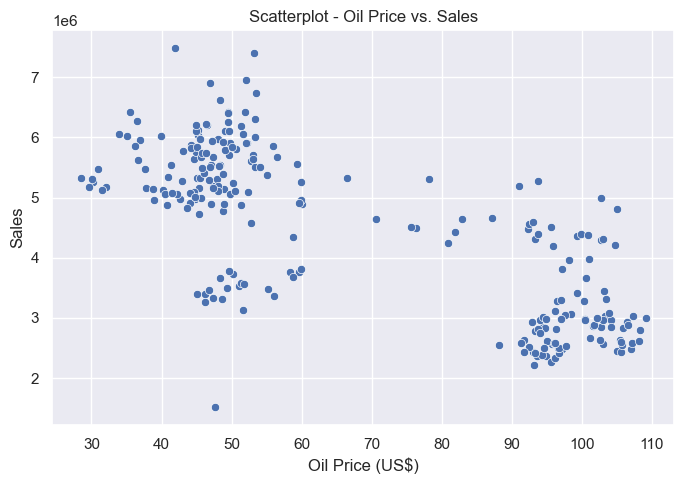

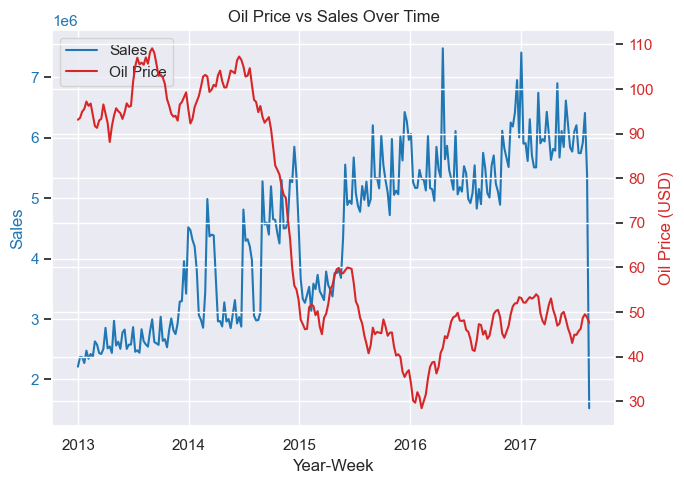

Pearson correlation: -0.628 (0.000)
Spearman correlation: -0.610 (0.000)


In [10]:
# Group features by week for a better visualization/analysis
df_oil_sales_by_week = df_sales.groupby('year_week').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean'
})

df_oil_sales_by_day = df_sales.groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'sum'
})

# Scatterplot
ax = sns.scatterplot(
    data=df_oil_sales_by_week,
    x='dcoilwtico',
    y='sales'
)

ax.set_title('Scatterplot - Oil Price vs. Sales')

ax.set_xlabel('Oil Price (US$)')
ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

# Double x-axis lineplot
fig, ax1 = plt.subplots()

sns.lineplot(
    data=df_oil_sales_by_week,
    x='year_week',
    y='sales',
    ax=ax1,
    color='tab:blue',
    label='Sales',
    legend=False  
)
ax1.set_ylabel('Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

sns.lineplot(
    data=df_oil_sales_by_week,
    x='year_week',
    y='dcoilwtico',
    ax=ax2,
    color='tab:red',
    label='Oil Price',
    legend=False 
)
ax2.set_ylabel('Oil Price (USD)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Year-Week')
ax1.set_title('Oil Price vs Sales Over Time')

ax1.legend(
    handles=[ax1.lines[0], ax2.lines[0]],
    labels=['Sales', 'Oil Price'],
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Correlations
pearson_correlation, pearson_correlation_pvalue = pearsonr(df_oil_sales_by_day['dcoilwtico'], df_oil_sales_by_day['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_oil_sales_by_day['dcoilwtico'], df_oil_sales_by_day['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")


Both the correlations (Pearson and Spearman) and the scatterplot trend indicate that the variables move in separate directions. However, we can see in the lineplot that there are periods that the variables move in the same direction. This may be caused by the price downfall. The analysis for each period will answer if it's caused by that.

Same thing. Let's calculate the correlation by sales/family.

In [11]:
df_correlation_by_granularity = correlation_stats(df_sales, ['store_nbr', 'family'], x_col='dcoilwtico', y_col='sales')

display(df_correlation_by_granularity.sort_values(by='sum_sales', ascending=False))

C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(group_df[x_col], group_df[y_col])
C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(group_df[x_col], group_df[y_col])


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
1431,44,GROCERY I,1.638606e+07,1679,-0.229866,1.246247e-21,-0.263028,4.788504e-28
1464,45,GROCERY I,1.634975e+07,1679,-0.321501,8.513832e-42,-0.331247,2.074086e-44
1530,47,GROCERY I,1.551453e+07,1679,-0.361106,4.994932e-53,-0.344975,2.956915e-48
1497,46,GROCERY I,1.434226e+07,1679,-0.267716,4.954223e-29,-0.255637,1.561331e-26
1422,44,BEVERAGES,1.341786e+07,1679,-0.490543,1.141965e-102,-0.526499,1.001091e-120
...,...,...,...,...,...,...,...,...
367,12,BOOKS,0.000000e+00,0,NaN,NaN,NaN,NaN
565,18,BOOKS,0.000000e+00,0,NaN,NaN,NaN,NaN
1420,44,BABY CARE,0.000000e+00,0,NaN,NaN,NaN,NaN
1042,32,LADIESWEAR,0.000000e+00,0,NaN,NaN,NaN,NaN


Let's check how many groups have p-values below 0.05.

In [12]:
# Groups with null correlation
groups_with_null_correlation = df_correlation_by_granularity[
    (df_correlation_by_granularity['pearson_correlation'].isna()) |
    (df_correlation_by_granularity['spearman_correlation'].isna())
    ]

groups_with_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] < 0.05
]

groups_with_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] < 0.05
]

print(f"Groups with null correlation: {len(groups_with_null_correlation)} ({len(groups_with_null_correlation) / len(df_correlation_by_granularity):.2%})")

print(f"Groups with significant pearson correlation: {len(groups_with_significant_pearson_correlation)} ({len(groups_with_significant_pearson_correlation) / len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_pearson_correlation)
display(groups_with_significant_pearson_correlation.describe())

print(f"Groups with significant spearman correlation: {len(groups_with_significant_spearman_correlation)}  ({len(groups_with_significant_spearman_correlation) / len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_spearman_correlation)
display(groups_with_significant_spearman_correlation.describe())

Groups with null correlation: 53 (2.97%)
Groups with significant pearson correlation: 1587 (89.06%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,5.475000e+03,1463,-0.261053,1.228221e-27,-0.268562,3.273686e-29
2,1,BEAUTY,4.056000e+03,1430,-0.181128,6.919332e-14,-0.148694,8.705981e-10
3,1,BEVERAGES,2.673769e+06,1678,-0.540771,1.620384e-128,-0.508231,2.784672e-111
4,1,BOOKS,2.110000e+02,127,-0.166397,6.364990e-12,-0.134657,2.905204e-08
5,1,BREAD/BAKERY,5.699922e+05,1678,-0.368683,2.288470e-55,-0.434104,2.432697e-78
...,...,...,...,...,...,...,...,...
1776,54,PLAYERS AND ELECTRONICS,3.316000e+03,905,-0.429585,1.389300e-76,-0.518177,2.366954e-116
1777,54,POULTRY,8.888981e+04,1678,-0.213279,8.932336e-19,-0.249845,2.215996e-25
1778,54,PREPARED FOODS,1.030900e+05,1679,-0.367726,4.555845e-55,-0.343430,8.194313e-48
1779,54,PRODUCE,5.961803e+05,1016,-0.644132,5.200973e-198,-0.610533,1.413146e-172


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,1587.000000,1.587000e+03,1587.000000,1587.000000,1.587000e+03,1587.000000,1.587000e+03
mean,27.675488,6.508986e+05,1191.446755,-0.312122,8.128829e-04,-0.345854,1.014780e-02
std,15.577692,1.699575e+06,504.970715,0.250009,4.280778e-03,0.270372,7.657066e-02
min,1.000000,9.000000e+00,5.000000,-0.802103,0.000000e+00,-0.793912,0.000000e+00
25%,14.000000,6.470500e+03,894.000000,-0.517404,1.822286e-116,-0.563065,1.913334e-141
50%,28.000000,4.134700e+04,1169.000000,-0.322434,1.930798e-46,-0.377516,6.592341e-60
75%,41.000000,4.117900e+05,1679.000000,-0.148909,1.452729e-12,-0.159852,3.033655e-15
max,54.000000,1.638606e+07,1679.000000,0.533436,4.689449e-02,0.548906,9.772083e-01


Groups with significant spearman correlation: 1600  (89.79%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,5.475000e+03,1463,-0.261053,1.228221e-27,-0.268562,3.273686e-29
2,1,BEAUTY,4.056000e+03,1430,-0.181128,6.919332e-14,-0.148694,8.705981e-10
3,1,BEVERAGES,2.673769e+06,1678,-0.540771,1.620384e-128,-0.508231,2.784672e-111
4,1,BOOKS,2.110000e+02,127,-0.166397,6.364990e-12,-0.134657,2.905204e-08
5,1,BREAD/BAKERY,5.699922e+05,1678,-0.368683,2.288470e-55,-0.434104,2.432697e-78
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,8.888981e+04,1678,-0.213279,8.932336e-19,-0.249845,2.215996e-25
1778,54,PREPARED FOODS,1.030900e+05,1679,-0.367726,4.555845e-55,-0.343430,8.194313e-48
1779,54,PRODUCE,5.961803e+05,1016,-0.644132,5.200973e-198,-0.610533,1.413146e-172
1780,54,SCHOOL AND OFFICE SUPPLIES,1.023000e+03,162,-0.154389,1.901037e-10,-0.227272,3.608964e-21


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,1600.000000,1.600000e+03,1600.000000,1600.000000,1.600000e+03,1600.000000,1.600000e+03
mean,27.689375,6.426697e+05,1191.921250,-0.308513,9.445173e-03,-0.343328,7.138769e-04
std,15.590094,1.687510e+06,506.026853,0.251637,6.800230e-02,0.271564,4.034112e-03
min,1.000000,9.000000e+00,5.000000,-0.802103,0.000000e+00,-0.793912,0.000000e+00
25%,14.000000,6.475750e+03,897.750000,-0.516340,6.041508e-116,-0.562215,5.956528e-141
50%,28.000000,4.213450e+04,1169.000000,-0.320868,1.635486e-45,-0.375434,2.700518e-59
75%,41.000000,4.020032e+05,1679.000000,-0.145093,4.749741e-12,-0.158079,3.421331e-15
max,54.000000,1.638606e+07,1679.000000,0.533436,9.812997e-01,0.548906,4.801644e-02


Most rows have significant correlations. Let's check the correlation value distribution.

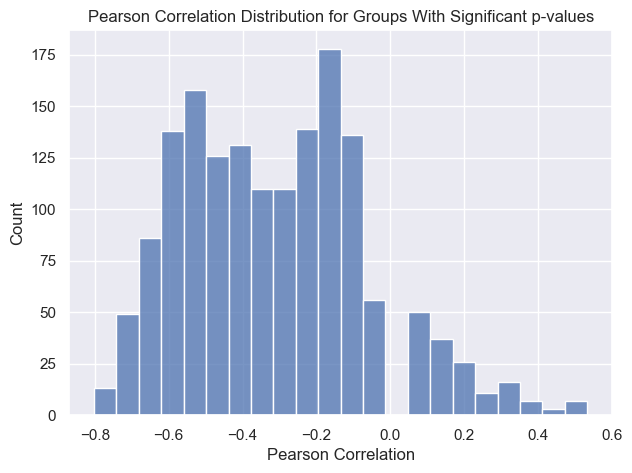

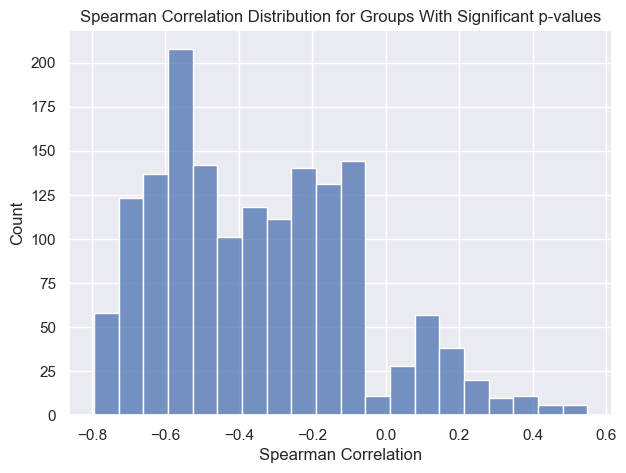

In [13]:
ax = sns.histplot(
    data=groups_with_significant_pearson_correlation,
    x='pearson_correlation'
)

ax.set_title('Pearson Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Pearson Correlation')
plt.show()

ax = sns.histplot(
    data=groups_with_significant_spearman_correlation,
    x='spearman_correlation'
)

ax.set_title('Spearman Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Spearman Correlation')
plt.show()

Most of the correlations are negative and vary from weak to strong. Let's check the groups with no significate p-values.

In [14]:
groups_with_no_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] >= 0.05
]

groups_with_no_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] >= 0.05
]


print(f"Groups with no significant pearson correlation: {len(groups_with_no_significant_pearson_correlation)} ({len(groups_with_no_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_pearson_correlation)
display(groups_with_no_significant_pearson_correlation.describe())

print(f"Groups with no significant spearman correlation: {len(groups_with_no_significant_spearman_correlation)} ({len(groups_with_no_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_spearman_correlation)
display(groups_with_no_significant_spearman_correlation.describe())

Groups with no significant pearson correlation: 142 (7.97%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
13,1,GROCERY II,3.678300e+04,1671,0.023453,0.336127,0.034821,0.153209
17,1,HOME APPLIANCES,5.690000e+02,416,-0.013850,0.570067,0.015499,0.525053
24,1,MEATS,5.276083e+05,1678,0.022173,0.363169,0.055031,0.023925
43,2,EGGS,3.147360e+05,1679,-0.005366,0.825836,0.005257,0.829322
50,2,HOME APPLIANCES,8.060000e+02,579,-0.030917,0.204767,-0.032154,0.187221
...,...,...,...,...,...,...,...,...
1674,51,MEATS,1.072030e+06,1679,-0.001306,0.957291,0.061172,0.012047
1751,54,BEAUTY,1.057000e+03,699,-0.031108,0.201986,-0.002873,0.906215
1763,54,HARDWARE,1.191000e+03,752,-0.030528,0.210529,-0.022556,0.354943
1771,54,"LIQUOR,WINE,BEER",4.019100e+04,1496,-0.025133,0.302656,-0.045169,0.063858


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,142.000000,1.420000e+02,142.000000,142.000000,142.000000,142.000000,1.420000e+02
mean,24.288732,2.864010e+05,1203.746479,-0.005945,0.376817,-0.004533,2.956847e-01
std,15.793248,6.205006e+05,589.484021,0.028034,0.286928,0.077022,3.275489e-01
min,1.000000,1.100000e+01,3.000000,-0.046114,0.050338,-0.376053,1.055579e-57
25%,10.250000,1.257500e+03,765.000000,-0.030302,0.146918,-0.033833,1.112409e-02
50%,20.500000,2.003450e+04,1496.500000,-0.010972,0.298609,0.001637,1.547084e-01
75%,38.000000,3.208522e+05,1679.000000,0.019553,0.569160,0.034818,5.662301e-01
max,54.000000,5.262682e+06,1679.000000,0.047699,0.989678,0.213821,9.971708e-01


Groups with no significant spearman correlation: 129 (7.97%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
13,1,GROCERY II,36783.0,1671,0.023453,0.336127,0.034821,0.153209
17,1,HOME APPLIANCES,569.0,416,-0.013850,0.570067,0.015499,0.525053
43,2,EGGS,314736.0,1679,-0.005366,0.825836,0.005257,0.829322
50,2,HOME APPLIANCES,806.0,579,-0.030917,0.204767,-0.032154,0.187221
53,2,LAWN AND GARDEN,13863.0,1611,-0.090545,0.000199,0.004699,0.847203
...,...,...,...,...,...,...,...,...
1667,51,HOME APPLIANCES,1816.0,896,-0.033626,0.167817,-0.008590,0.724655
1672,51,"LIQUOR,WINE,BEER",270015.0,1498,-0.028419,0.243773,-0.038050,0.118557
1751,54,BEAUTY,1057.0,699,-0.031108,0.201986,-0.002873,0.906215
1763,54,HARDWARE,1191.0,752,-0.030528,0.210529,-0.022556,0.354943


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,129.000000,1.290000e+02,129.000000,129.000000,1.290000e+02,129.000000,129.000000
mean,23.775194,3.517316e+05,1199.100775,-0.019852,3.076417e-01,-0.001469,0.441470
std,15.578050,8.352190e+05,586.219187,0.045413,3.068872e-01,0.025943,0.304094
min,1.000000,1.500000e+01,3.000000,-0.192697,1.504006e-15,-0.046953,0.052231
25%,10.000000,1.231000e+03,752.000000,-0.045368,3.195589e-02,-0.025205,0.162011
50%,23.000000,1.535800e+04,1497.000000,-0.017372,2.101691e-01,-0.000697,0.390569
75%,37.000000,3.444090e+05,1679.000000,0.011897,5.237580e-01,0.018614,0.724725
max,54.000000,6.393697e+06,1679.000000,0.084646,9.896782e-01,0.047313,0.997171


The granularities without significant correlations contain both granularities with few and lot of sales. However, we can see that most of granularities have an import correlation.

Now, let's do this analysis before, during and after the downfall period.

In [15]:
oil_price_downfall_period_start = '2014-07-15'
oil_price_downfall_period_end = '2015-01-15'

### 2. 1. 2. Before the oil price downfall

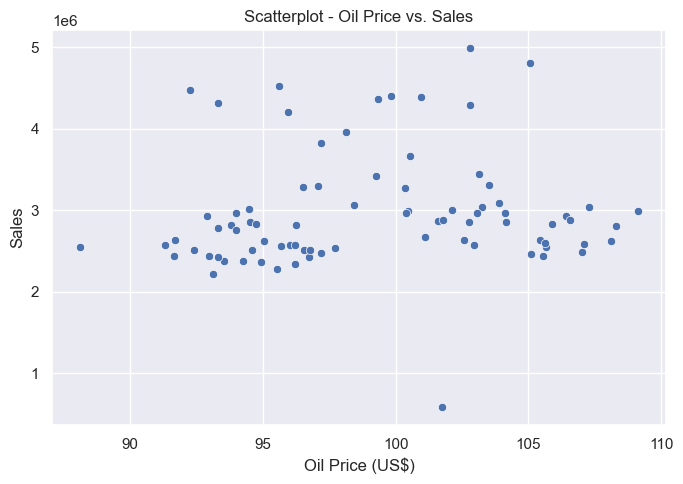

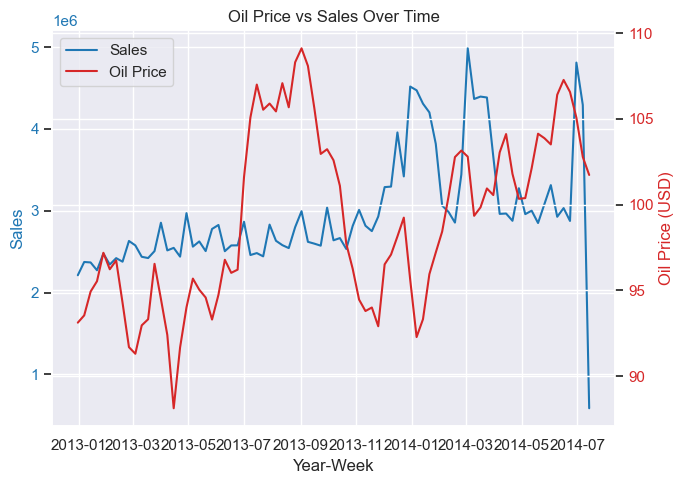

Pearson correlation: 0.061 (0.151)
Spearman correlation: 0.110 (0.009)


In [16]:
df_sales_before_downfall = df_sales[df_sales['date'] < oil_price_downfall_period_start]

# Group features by week for a better visualization/analysis
df_oil_sales_by_week_before_downfall = df_sales_before_downfall.groupby('year_week').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean'
})

df_oil_sales_by_day_before_downfall = df_sales_before_downfall.groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean'
})

# Scatterplot
ax = sns.scatterplot(
    data=df_oil_sales_by_week_before_downfall,
    x='dcoilwtico',
    y='sales'
)

ax.set_title('Scatterplot - Oil Price vs. Sales')

ax.set_xlabel('Oil Price (US$)')
ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

# Double x-axis lineplot
fig, ax1 = plt.subplots()

sns.lineplot(
    data=df_oil_sales_by_week_before_downfall,
    x='year_week',
    y='sales',
    ax=ax1,
    color='tab:blue',
    label='Sales',
    legend=False  
)
ax1.set_ylabel('Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

sns.lineplot(
    data=df_oil_sales_by_week_before_downfall,
    x='year_week',
    y='dcoilwtico',
    ax=ax2,
    color='tab:red',
    label='Oil Price',
    legend=False 
)
ax2.set_ylabel('Oil Price (USD)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Year-Week')
ax1.set_title('Oil Price vs Sales Over Time')

ax1.legend(
    handles=[ax1.lines[0], ax2.lines[0]],
    labels=['Sales', 'Oil Price'],
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Correlations
pearson_correlation, pearson_correlation_pvalue = pearsonr(df_oil_sales_by_day_before_downfall['dcoilwtico'], df_oil_sales_by_day_before_downfall['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_oil_sales_by_day_before_downfall['dcoilwtico'], df_oil_sales_by_day_before_downfall['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")


We can see the variables moving in the same direction in the plots and the Spearman correlation shows a week but significant correlation.

We can see a sales outlier (a week with very few sales). Let's remove it and check again to see if it impacts the results.

IQR: 519951.72867290024
Lower bound: 1763578.5706886495
Upper bound: 3843385.4853802505


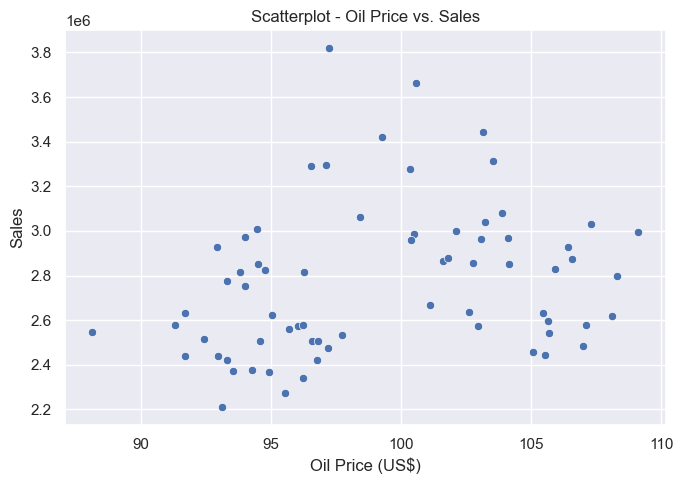

Pearson correlation: 0.061 (0.151)
Spearman correlation: 0.110 (0.009)


In [17]:
df_oil_sales_by_week_before_downfall_no_outliers = remove_outliers_by_iqr(
    df_oil_sales_by_week_before_downfall,
    column_name='sales',
    removal_type='remove',
    verbose=True
)

# Scatterplot
ax = sns.scatterplot(
    data=df_oil_sales_by_week_before_downfall_no_outliers,
    x='dcoilwtico',
    y='sales'
)

ax.set_title('Scatterplot - Oil Price vs. Sales')

ax.set_xlabel('Oil Price (US$)')
ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

# Correlations
pearson_correlation, pearson_correlation_pvalue = pearsonr(df_oil_sales_by_day_before_downfall['dcoilwtico'], df_oil_sales_by_day_before_downfall['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_oil_sales_by_day_before_downfall['dcoilwtico'], df_oil_sales_by_day_before_downfall['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")


We can see week/moderate but significant correlations of the variables moving in the same directions. Let's do the analysis by granularity.

In [18]:
df_correlation_by_granularity = correlation_stats(df_sales_before_downfall, ['store_nbr', 'family'], x_col='dcoilwtico', y_col='sales')

display(df_correlation_by_granularity)

C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(group_df[x_col], group_df[y_col])
C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(group_df[x_col], group_df[y_col])


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,1284.000000,447,0.085371,4.363141e-02,0.053021,2.106904e-01
1,1,BABY CARE,0.000000,0,NaN,NaN,NaN,NaN
2,1,BEAUTY,1048.000000,447,0.067122,1.129159e-01,0.091063,3.134501e-02
3,1,BEVERAGES,563699.000000,557,-0.032798,4.389786e-01,-0.034789,4.116879e-01
4,1,BOOKS,0.000000,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,24782.830222,557,0.035226,4.058372e-01,0.077086,6.857942e-02
1778,54,PREPARED FOODS,25172.000000,557,0.095353,2.416219e-02,0.070008,9.822375e-02
1779,54,PRODUCE,35498.666170,75,-0.013699,7.465537e-01,-0.016520,6.967315e-01
1780,54,SCHOOL AND OFFICE SUPPLIES,5.000000,3,0.060101,1.558726e-01,0.066288,1.174698e-01


In [19]:
# Groups with null correlation
groups_with_null_correlation = df_correlation_by_granularity[
    (df_correlation_by_granularity['pearson_correlation'].isna()) |
    (df_correlation_by_granularity['spearman_correlation'].isna())
    ]

groups_with_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] < 0.05
]

groups_with_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] < 0.05
]

print(f"Groups with null correlation: {len(groups_with_null_correlation)} ({len(groups_with_null_correlation)/len(df_correlation_by_granularity):.2%})")

print(f"Groups with significant pearson correlation: {len(groups_with_significant_pearson_correlation)} ({len(groups_with_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_pearson_correlation)
display(groups_with_significant_pearson_correlation.describe())

print(f"Groups with significant spearman correlation: {len(groups_with_significant_spearman_correlation)} ({len(groups_with_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_spearman_correlation)
display(groups_with_significant_spearman_correlation.describe())

Groups with null correlation: 310 (17.40%)
Groups with significant pearson correlation: 481 (26.99%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,1284.000000,447,0.085371,4.363141e-02,0.053021,2.106904e-01
9,1,DELI,60197.407092,557,-0.113216,7.375030e-03,-0.159944,1.461053e-04
10,1,EGGS,80056.000000,557,-0.098611,1.970392e-02,-0.115457,6.279900e-03
13,1,GROCERY II,12149.000000,550,-0.114355,6.798864e-03,-0.119789,4.567366e-03
20,1,LAWN AND GARDEN,3314.000000,514,0.170223,5.228666e-05,0.182369,1.434204e-05
...,...,...,...,...,...,...,...,...
1759,54,EGGS,25505.000000,557,0.219476,1.592430e-07,0.180643,1.732620e-05
1760,54,FROZEN FOODS,9361.932985,556,0.087802,3.796061e-02,0.269566,9.204966e-11
1770,54,LINGERIE,2989.000000,521,0.095732,2.360293e-02,0.083592,4.822176e-02
1778,54,PREPARED FOODS,25172.000000,557,0.095353,2.416219e-02,0.070008,9.822375e-02


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,481.000000,4.810000e+02,481.000000,481.000000,4.810000e+02,481.000000,4.810000e+02
mean,28.417879,1.954390e+05,453.164241,0.063245,8.057751e-03,0.073648,1.707793e-02
std,15.488370,4.298926e+05,174.693040,0.180895,1.257358e-02,0.200244,7.059466e-02
min,1.000000,3.000000e+00,3.000000,-0.577199,5.703719e-51,-0.679124,7.877070e-77
25%,15.000000,2.802817e+03,445.000000,-0.092406,1.322884e-06,-0.092005,3.516432e-08
50%,28.000000,3.755667e+04,556.000000,0.114600,1.125417e-03,0.124853,1.968930e-04
75%,41.000000,1.462210e+05,557.000000,0.163773,1.045316e-02,0.192522,6.279900e-03
max,54.000000,3.661186e+06,559.000000,0.495871,4.972168e-02,0.454826,8.576249e-01


Groups with significant spearman correlation: 598 (33.56%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
2,1,BEAUTY,1048.000000,447,0.067122,1.129159e-01,0.091063,3.134501e-02
7,1,CLEANING,339541.000000,557,-0.064227,1.293438e-01,-0.095923,2.332364e-02
9,1,DELI,60197.407092,557,-0.113216,7.375030e-03,-0.159944,1.461053e-04
10,1,EGGS,80056.000000,557,-0.098611,1.970392e-02,-0.115457,6.279900e-03
11,1,FROZEN FOODS,64001.832000,557,0.030547,4.710479e-01,0.099803,1.826155e-02
...,...,...,...,...,...,...,...,...
1758,54,DELI,74821.000000,557,0.135333,1.339858e-03,0.153131,2.792207e-04
1759,54,EGGS,25505.000000,557,0.219476,1.592430e-07,0.180643,1.732620e-05
1760,54,FROZEN FOODS,9361.932985,556,0.087802,3.796061e-02,0.269566,9.204966e-11
1770,54,LINGERIE,2989.000000,521,0.095732,2.360293e-02,0.083592,4.822176e-02


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,598.000000,5.980000e+02,598.000000,598.000000,5.980000e+02,598.000000,5.980000e+02
mean,28.075251,2.600901e+05,461.107023,0.055558,9.092906e-02,0.083757,7.468924e-03
std,15.948599,5.739158e+05,166.606414,0.163128,2.031283e-01,0.185230,1.253708e-02
min,1.000000,3.000000e+00,3.000000,-0.577199,5.703719e-51,-0.679124,7.877070e-77
25%,14.000000,3.389500e+03,449.000000,-0.028634,3.074072e-05,0.083775,2.927278e-07
50%,28.000000,6.050074e+04,557.000000,0.092432,3.576871e-03,0.123339,4.282383e-04
75%,41.000000,2.131664e+05,557.000000,0.145835,4.731119e-02,0.188281,9.624102e-03
max,54.000000,4.485696e+06,559.000000,0.495871,9.720435e-01,0.454826,4.950027e-02


Less than half of the groups have significant correlations. Let's check their correlation distribution.

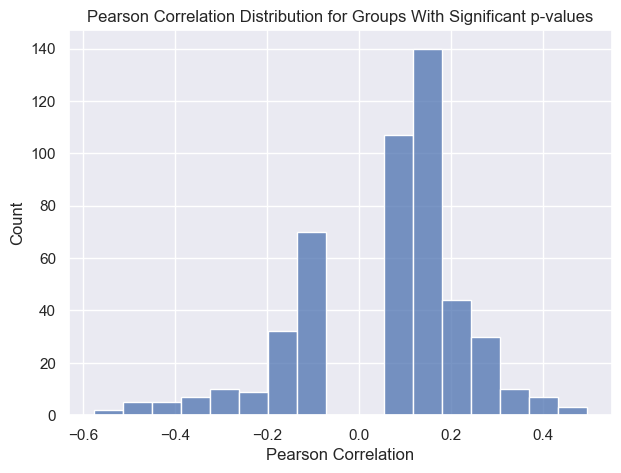

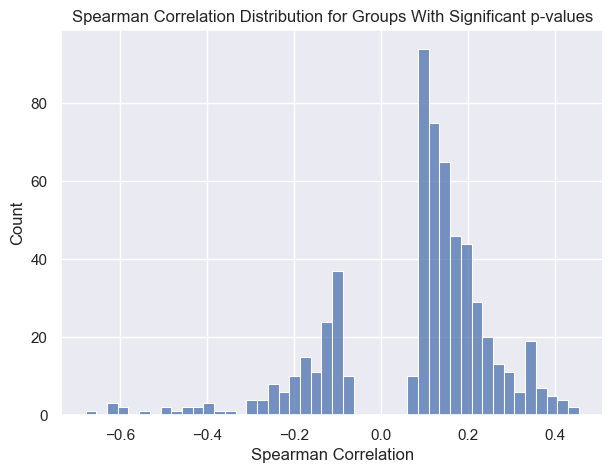

In [20]:
ax = sns.histplot(
    data=groups_with_significant_pearson_correlation,
    x='pearson_correlation'
)

ax.set_title('Pearson Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Pearson Correlation')
plt.show()

ax = sns.histplot(
    data=groups_with_significant_spearman_correlation,
    x='spearman_correlation'
)

ax.set_title('Spearman Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Spearman Correlation')
plt.show()

Most of these groups have week to moderate positive or negative correlations.

Let's check the groups without significant correlations.

In [21]:
groups_with_no_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] >= 0.05
]

groups_with_no_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] >= 0.05
]


print(f"Groups with no significant pearson correlation: {len(groups_with_no_significant_pearson_correlation)} ({len(groups_with_no_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_pearson_correlation)
display(groups_with_no_significant_pearson_correlation.describe())

print(f"Groups with no significant spearman correlation: {len(groups_with_no_significant_spearman_correlation)} ({len(groups_with_no_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_spearman_correlation)
display(groups_with_no_significant_spearman_correlation.describe())

Groups with no significant pearson correlation: 991 (55.61%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
2,1,BEAUTY,1048.000000,447,0.067122,0.112916,0.091063,0.031345
3,1,BEVERAGES,563699.000000,557,-0.032798,0.438979,-0.034789,0.411688
5,1,BREAD/BAKERY,155231.267868,557,-0.046889,0.268413,-0.046401,0.273432
6,1,CELEBRATION,1015.000000,74,-0.048976,0.247659,-0.025360,0.549609
7,1,CLEANING,339541.000000,557,-0.064227,0.129344,-0.095923,0.023324
...,...,...,...,...,...,...,...,...
1775,54,PET SUPPLIES,2.000000,2,-0.002987,0.943830,-0.007334,0.862643
1776,54,PLAYERS AND ELECTRONICS,201.000000,66,0.002938,0.944739,-0.002211,0.958396
1777,54,POULTRY,24782.830222,557,0.035226,0.405837,0.077086,0.068579
1779,54,PRODUCE,35498.666170,75,-0.013699,0.746554,-0.016520,0.696731


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,991.00000,9.910000e+02,991.000000,991.000000,991.000000,991.000000,9.910000e+02
mean,26.36226,1.478823e+05,306.881937,0.000842,0.519176,0.015070,4.609605e-01
std,16.17502,4.424978e+05,232.281150,0.038720,0.287160,0.061681,2.974948e-01
min,1.00000,1.000000e+00,1.000000,-0.082376,0.051585,-0.293348,3.541718e-24
25%,11.00000,5.760000e+02,75.000000,-0.025343,0.264769,-0.020710,1.643690e-01
50%,27.00000,3.645000e+03,347.000000,-0.003553,0.532704,-0.007334,5.388858e-01
75%,40.50000,8.872132e+04,557.000000,0.028192,0.765365,0.046904,6.890418e-01
max,54.00000,4.763363e+06,559.000000,0.081695,0.997054,0.410854,9.954958e-01


Groups with no significant spearman correlation: 874 (49.05%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,1284.000000,447,0.085371,0.043631,0.053021,0.210690
3,1,BEVERAGES,563699.000000,557,-0.032798,0.438979,-0.034789,0.411688
5,1,BREAD/BAKERY,155231.267868,557,-0.046889,0.268413,-0.046401,0.273432
6,1,CELEBRATION,1015.000000,74,-0.048976,0.247659,-0.025360,0.549609
8,1,DAIRY,271915.000000,557,0.077855,0.065855,0.075337,0.075117
...,...,...,...,...,...,...,...,...
1776,54,PLAYERS AND ELECTRONICS,201.000000,66,0.002938,0.944739,-0.002211,0.958396
1777,54,POULTRY,24782.830222,557,0.035226,0.405837,0.077086,0.068579
1778,54,PREPARED FOODS,25172.000000,557,0.095353,0.024162,0.070008,0.098224
1779,54,PRODUCE,35498.666170,75,-0.013699,0.746554,-0.016520,0.696731


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,874.000000,8.740000e+02,874.000000,874.000000,874.000000,874.000000,874.000000
mean,26.321510,9.728109e+04,281.864989,-0.002252,0.530896,0.000311,0.526956
std,15.967703,2.974410e+05,232.063694,0.039743,0.289064,0.036592,0.257534
min,1.000000,1.000000e+00,1.000000,-0.117273,0.000204,-0.081912,0.050754
25%,12.000000,5.092500e+02,75.000000,-0.026948,0.285312,-0.021644,0.304798
50%,27.000000,2.328500e+03,121.500000,-0.005307,0.555252,-0.011968,0.587428
75%,40.000000,5.137050e+04,557.000000,0.022372,0.772237,0.027551,0.705313
max,54.000000,4.763363e+06,559.000000,0.156444,0.997054,0.082670,0.995496


There are groups with and without significant correlations with different amount of sales.

### 2. 1. 3. During the oil price downfall

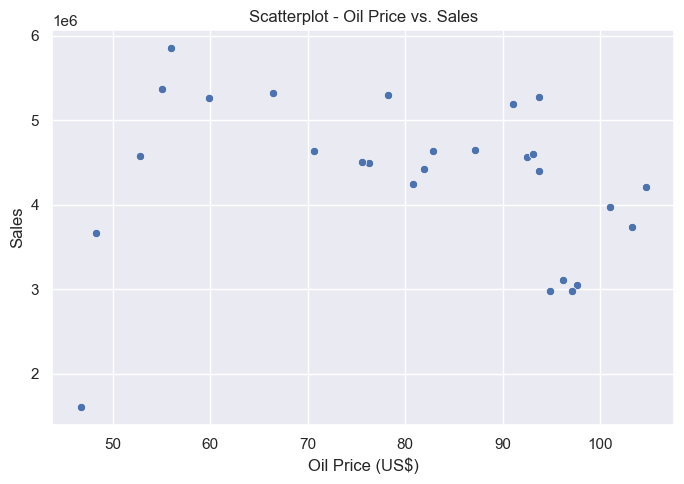

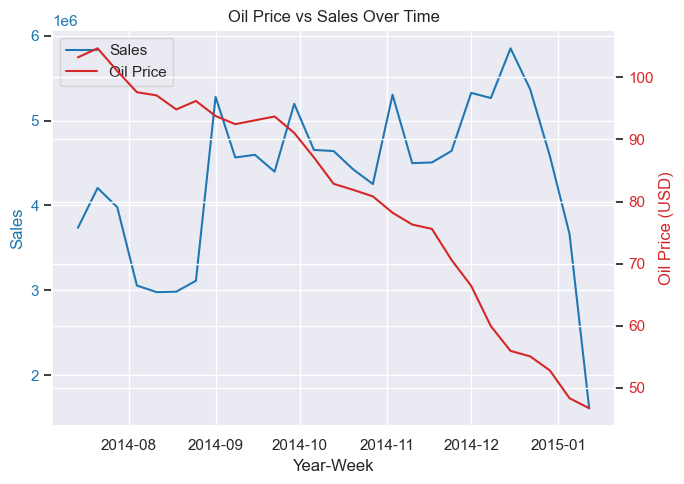

Pearson correlation: -0.254 (0.001)
Spearman correlation: -0.317 (0.000)


In [22]:
df_sales_during_downfall = df_sales[df_sales['date'].between(oil_price_downfall_period_start, oil_price_downfall_period_end)]

# Group features by week for a better visualization/analysis
df_oil_sales_by_week_during_downfall = df_sales_during_downfall.groupby('year_week').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean'
})

df_oil_sales_by_day_during_downfall = df_sales_during_downfall.groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean'
})

# Scatterplot
ax = sns.scatterplot(
    data=df_oil_sales_by_week_during_downfall,
    x='dcoilwtico',
    y='sales'
)

ax.set_title('Scatterplot - Oil Price vs. Sales')

ax.set_xlabel('Oil Price (US$)')
ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

# Double x-axis lineplot
fig, ax1 = plt.subplots()

sns.lineplot(
    data=df_oil_sales_by_week_during_downfall,
    x='year_week',
    y='sales',
    ax=ax1,
    color='tab:blue',
    label='Sales',
    legend=False  
)
ax1.set_ylabel('Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

sns.lineplot(
    data=df_oil_sales_by_week_during_downfall,
    x='year_week',
    y='dcoilwtico',
    ax=ax2,
    color='tab:red',
    label='Oil Price',
    legend=False 
)
ax2.set_ylabel('Oil Price (USD)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Year-Week')
ax1.set_title('Oil Price vs Sales Over Time')

ax1.legend(
    handles=[ax1.lines[0], ax2.lines[0]],
    labels=['Sales', 'Oil Price'],
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Correlations
pearson_correlation, pearson_correlation_pvalue = pearsonr(df_oil_sales_by_day_during_downfall['dcoilwtico'], df_oil_sales_by_day_during_downfall['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_oil_sales_by_day_during_downfall['dcoilwtico'], df_oil_sales_by_day_during_downfall['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")


It seems to have a negative moderate correlation (confirmed by Spearman and Pearson correlations). Let's look at it without the point with few sales.

IQR: 1068225.6789079998
Lower bound: 2788733.7220291505
Upper bound: 5993410.75875315


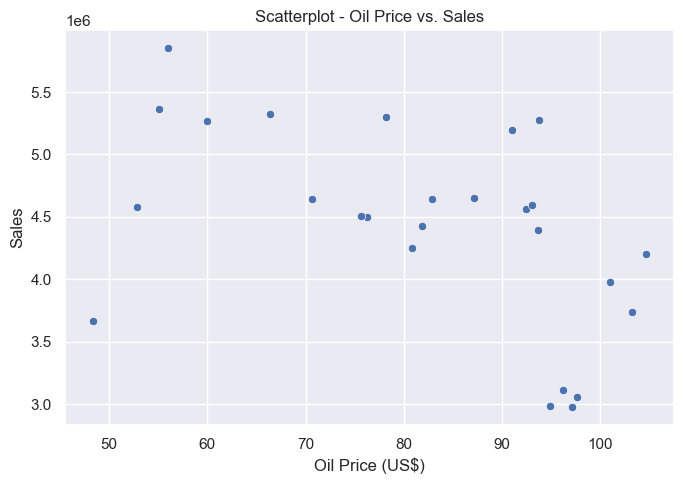

Pearson correlation: -0.254 (0.001)
Spearman correlation: -0.317 (0.000)


In [23]:
df_oil_sales_by_week_during_downfall_no_outliers = remove_outliers_by_iqr(
    df=df_oil_sales_by_week_during_downfall,
    column_name='sales',
    q=1,
    verbose=True
)

# Scatterplot
ax = sns.scatterplot(
    data=df_oil_sales_by_week_during_downfall_no_outliers,
    x='dcoilwtico',
    y='sales'
)

ax.set_title('Scatterplot - Oil Price vs. Sales')

ax.set_xlabel('Oil Price (US$)')
ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

# Correlations
pearson_correlation, pearson_correlation_pvalue = pearsonr(df_oil_sales_by_day_during_downfall['dcoilwtico'], df_oil_sales_by_day_during_downfall['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_oil_sales_by_day_during_downfall['dcoilwtico'], df_oil_sales_by_day_during_downfall['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")


 Let's break it down by granularity.

In [24]:
df_correlation_by_granularity = correlation_stats(df_sales_during_downfall, ['store_nbr', 'family'], x_col='dcoilwtico', y_col='sales')

display(df_correlation_by_granularity)

C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(group_df[x_col], group_df[y_col])
C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(group_df[x_col], group_df[y_col])


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,562.000000,156,-0.007795,0.916367,-0.036020,0.627371
1,1,BABY CARE,0.000000,0,NaN,NaN,NaN,NaN
2,1,BEAUTY,443.000000,153,-0.042390,0.567765,-0.011506,0.876806
3,1,BEVERAGES,308089.000000,183,-0.029811,0.687902,-0.130328,0.077845
4,1,BOOKS,0.000000,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,9883.505989,182,-0.040405,0.586050,0.079651,0.282471
1778,54,PREPARED FOODS,11661.000000,183,-0.190640,0.009538,-0.228777,0.001786
1779,54,PRODUCE,67748.851020,138,-0.038211,0.606567,-0.122194,0.098449
1780,54,SCHOOL AND OFFICE SUPPLIES,7.000000,5,0.200511,0.006351,0.272772,0.000180


In [25]:
# Groups with null correlation
groups_with_null_correlation = df_correlation_by_granularity[
    (df_correlation_by_granularity['pearson_correlation'].isna()) |
    (df_correlation_by_granularity['spearman_correlation'].isna())
    ]

groups_with_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] < 0.05
]

groups_with_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] < 0.05
]

print(f"Groups with null correlation: {len(groups_with_null_correlation)} ({len(groups_with_null_correlation)/len(df_correlation_by_granularity):.2%})")

print(f"Groups with significant pearson correlation: {len(groups_with_significant_pearson_correlation)} ({len(groups_with_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_pearson_correlation)
display(groups_with_significant_pearson_correlation.describe())

print(f"Groups with significant spearman correlation: {len(groups_with_significant_spearman_correlation)} ({len(groups_with_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_spearman_correlation)
display(groups_with_significant_spearman_correlation.describe())

Groups with null correlation: 304 (17.06%)
Groups with significant pearson correlation: 710 (39.84%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
9,1,DELI,20362.709000,183,-0.290742,6.233922e-05,-0.320774,9.020130e-06
11,1,FROZEN FOODS,26268.667015,183,-0.368117,2.732328e-07,-0.238789,1.097094e-03
12,1,GROCERY I,386717.000000,183,-0.206215,4.978454e-03,-0.259438,3.761325e-04
13,1,GROCERY II,4883.000000,183,-0.210845,4.066957e-03,-0.175002,1.750032e-02
16,1,HOME AND KITCHEN II,904.000000,146,-0.304825,2.585067e-05,-0.385984,6.259296e-08
...,...,...,...,...,...,...,...,...
1770,54,LINGERIE,941.000000,165,0.408677,8.448274e-09,0.441262,3.621445e-10
1774,54,PERSONAL CARE,32139.000000,183,-0.233728,1.407133e-03,-0.258877,3.876703e-04
1775,54,PET SUPPLIES,30.000000,22,-0.165772,2.451861e-02,-0.236791,1.211113e-03
1778,54,PREPARED FOODS,11661.000000,183,-0.190640,9.537663e-03,-0.228777,1.786084e-03


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,710.000000,7.100000e+02,710.000000,710.000000,7.100000e+02,710.000000,7.100000e+02
mean,27.459155,9.246362e+04,159.454930,-0.220123,6.628821e-03,-0.219278,4.172754e-02
std,15.438047,2.191121e+05,37.701524,0.199115,1.184524e-02,0.209734,1.229301e-01
min,1.000000,6.000000e+00,4.000000,-0.600204,2.168402e-19,-0.664420,8.477599e-25
25%,14.000000,1.507250e+03,152.000000,-0.336738,1.958161e-06,-0.344972,7.646679e-07
50%,27.000000,1.336300e+04,181.500000,-0.249866,3.438942e-04,-0.243330,4.604411e-04
75%,40.000000,6.241425e+04,183.000000,-0.178618,7.831566e-03,-0.146926,1.317373e-02
max,54.000000,1.876259e+06,184.000000,0.424152,4.987265e-02,0.500200,8.906959e-01


Groups with significant spearman correlation: 755 (42.37%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
7,1,CLEANING,118516.000000,183,-0.113155,1.261744e-01,-0.177711,1.580429e-02
8,1,DAIRY,114797.000000,183,-0.087038,2.400649e-01,-0.178310,1.544917e-02
9,1,DELI,20362.709000,183,-0.290742,6.233922e-05,-0.320774,9.020130e-06
11,1,FROZEN FOODS,26268.667015,183,-0.368117,2.732328e-07,-0.238789,1.097094e-03
12,1,GROCERY I,386717.000000,183,-0.206215,4.978454e-03,-0.259438,3.761325e-04
...,...,...,...,...,...,...,...,...
1770,54,LINGERIE,941.000000,165,0.408677,8.448274e-09,0.441262,3.621445e-10
1774,54,PERSONAL CARE,32139.000000,183,-0.233728,1.407133e-03,-0.258877,3.876703e-04
1775,54,PET SUPPLIES,30.000000,22,-0.165772,2.451861e-02,-0.236791,1.211113e-03
1778,54,PREPARED FOODS,11661.000000,183,-0.190640,9.537663e-03,-0.228777,1.786084e-03


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,755.000000,7.550000e+02,755.000000,755.000000,7.550000e+02,755.000000,7.550000e+02
mean,27.498013,1.062250e+05,157.111258,-0.206625,5.547082e-02,-0.230773,6.643926e-03
std,15.814271,2.344870e+05,38.365730,0.190398,1.341727e-01,0.198460,1.138390e-02
min,1.000000,2.000000e+00,2.000000,-0.600204,2.168402e-19,-0.664420,8.477599e-25
25%,13.500000,1.507500e+03,138.000000,-0.327742,3.376867e-06,-0.332339,1.623344e-06
50%,27.000000,1.443600e+04,179.000000,-0.231765,6.820126e-04,-0.239979,6.695409e-04
75%,41.000000,8.178052e+04,183.000000,-0.125120,2.698088e-02,-0.178986,7.436200e-03
max,54.000000,1.876259e+06,184.000000,0.424152,9.192847e-01,0.500200,4.995126e-02


Less than half of the granularities seem to have a significant Pearson/Spearman correlation. Let's look at the correlation distribution.

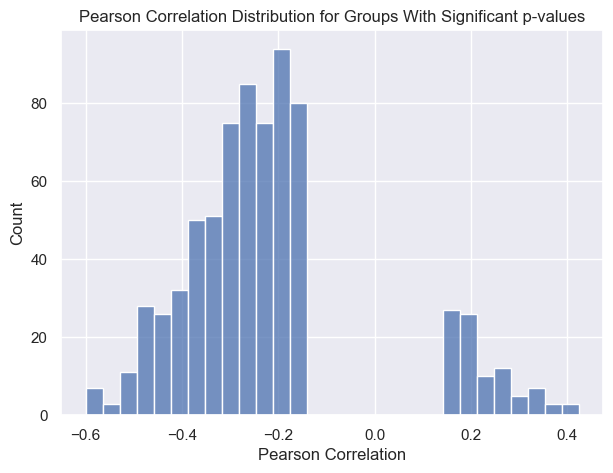

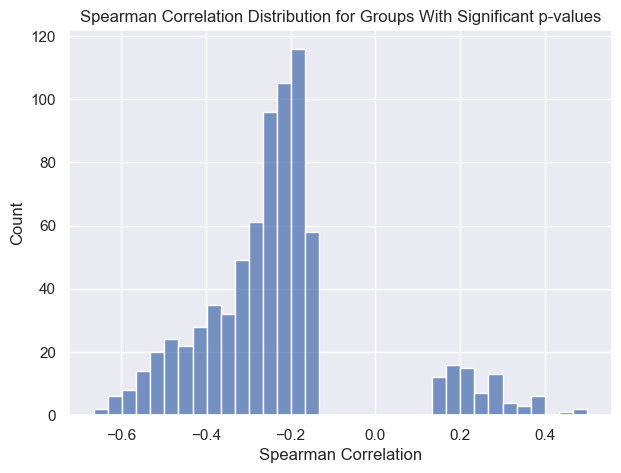

In [26]:
ax = sns.histplot(
    data=groups_with_significant_pearson_correlation,
    x='pearson_correlation'
)

ax.set_title('Pearson Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Pearson Correlation')
plt.show()

ax = sns.histplot(
    data=groups_with_significant_spearman_correlation,
    x='spearman_correlation'
)

ax.set_title('Spearman Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Spearman Correlation')
plt.show()

Most of these groups have week/moderate (some of them strong) correlations. Let's look at the groups without significant correlations.


In [27]:
groups_with_no_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] >= 0.05
]

groups_with_no_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] >= 0.05
]


print(f"Groups with no significant pearson correlation: {len(groups_with_no_significant_pearson_correlation)} ({len(groups_with_no_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_pearson_correlation)
display(groups_with_no_significant_pearson_correlation.describe())

print(f"Groups with no significant spearman correlation: {len(groups_with_no_significant_spearman_correlation)} ({len(groups_with_no_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_spearman_correlation)
display(groups_with_no_significant_spearman_correlation.describe())

Groups with no significant pearson correlation: 768 (43.10%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,562.000000,156,-0.007795,0.916367,-0.036020,0.627371
2,1,BEAUTY,443.000000,153,-0.042390,0.567765,-0.011506,0.876806
3,1,BEVERAGES,308089.000000,183,-0.029811,0.687902,-0.130328,0.077845
5,1,BREAD/BAKERY,62436.891040,183,0.006334,0.931997,-0.031136,0.674797
6,1,CELEBRATION,3233.000000,136,-0.002143,0.976963,-0.141579,0.055232
...,...,...,...,...,...,...,...,...
1773,54,MEATS,8932.255996,183,0.021398,0.773108,-0.003534,0.962027
1776,54,PLAYERS AND ELECTRONICS,367.000000,118,-0.054875,0.459394,-0.064989,0.380776
1777,54,POULTRY,9883.505989,182,-0.040405,0.586050,0.079651,0.282471
1779,54,PRODUCE,67748.851020,138,-0.038211,0.606567,-0.122194,0.098449


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,768.000000,7.680000e+02,768.000000,768.000000,768.000000,768.000000,7.680000e+02
mean,26.589844,6.641746e+04,140.410156,-0.023544,0.455548,-0.062307,3.287809e-01
std,16.436905,1.715627e+05,51.572733,0.072408,0.288649,0.094862,2.982422e-01
min,1.000000,1.000000e+00,1.000000,-0.144319,0.050636,-0.374502,1.630051e-07
25%,11.000000,3.897500e+02,124.000000,-0.082506,0.189317,-0.130000,6.900780e-02
50%,28.000000,2.809000e+03,147.000000,-0.029955,0.432053,-0.071796,2.419652e-01
75%,41.000000,4.733525e+04,183.000000,0.025577,0.700641,0.000906,5.626853e-01
max,54.000000,1.589973e+06,183.000000,0.143561,0.998485,0.226946,9.984677e-01


Groups with no significant spearman correlation: 723 (40.57%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,562.000000,156,-0.007795,0.916367,-0.036020,0.627371
2,1,BEAUTY,443.000000,153,-0.042390,0.567765,-0.011506,0.876806
3,1,BEVERAGES,308089.000000,183,-0.029811,0.687902,-0.130328,0.077845
5,1,BREAD/BAKERY,62436.891040,183,0.006334,0.931997,-0.031136,0.674797
6,1,CELEBRATION,3233.000000,136,-0.002143,0.976963,-0.141579,0.055232
...,...,...,...,...,...,...,...,...
1773,54,MEATS,8932.255996,183,0.021398,0.773108,-0.003534,0.962027
1776,54,PLAYERS AND ELECTRONICS,367.000000,118,-0.054875,0.459394,-0.064989,0.380776
1777,54,POULTRY,9883.505989,182,-0.040405,0.586050,0.079651,0.282471
1779,54,PRODUCE,67748.851020,138,-0.038211,0.606567,-0.122194,0.098449


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,723.000000,7.230000e+02,723.000000,723.000000,723.000000,723.000000,723.000000
mean,26.495159,5.042587e+04,141.672199,-0.025404,0.432485,-0.040533,0.383284
std,16.116729,1.405232e+05,52.417265,0.097936,0.316413,0.075511,0.280601
min,1.000000,1.000000e+00,1.000000,-0.342230,0.000002,-0.144639,0.050122
25%,11.000000,3.760000e+02,123.500000,-0.082748,0.134189,-0.104432,0.135704
50%,27.000000,2.661000e+03,165.000000,-0.019855,0.420495,-0.054298,0.316801
75%,40.000000,3.850250e+04,183.000000,0.036465,0.716875,0.011649,0.616593
max,54.000000,1.589973e+06,184.000000,0.262713,0.998485,0.143154,0.998468


Similar distribution of sales.

### 2. 1. 4. After the oil price downfall

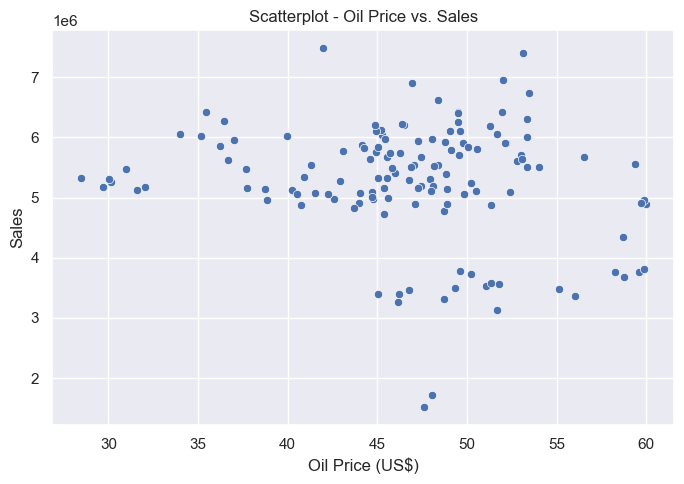

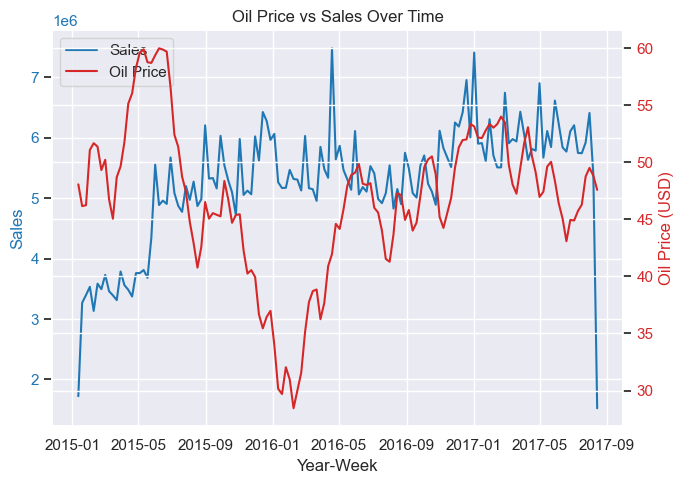

Pearson correlation: -0.179 (0.037)
Spearman correlation: -0.082 (0.342)


In [28]:
df_sales_after_downfall = df_sales[df_sales['date'] > oil_price_downfall_period_end]

# Group features by week for a better visualization/analysis
df_oil_sales_by_week_after_downfall = df_sales_after_downfall.groupby('year_week').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean'
})

# Scatterplot
ax = sns.scatterplot(
    data=df_oil_sales_by_week_after_downfall,
    x='dcoilwtico',
    y='sales'
)

ax.set_title('Scatterplot - Oil Price vs. Sales')

ax.set_xlabel('Oil Price (US$)')
ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

# Double x-axis lineplot
fig, ax1 = plt.subplots()

sns.lineplot(
    data=df_oil_sales_by_week_after_downfall,
    x='year_week',
    y='sales',
    ax=ax1,
    color='tab:blue',
    label='Sales',
    legend=False  
)
ax1.set_ylabel('Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

sns.lineplot(
    data=df_oil_sales_by_week_after_downfall,
    x='year_week',
    y='dcoilwtico',
    ax=ax2,
    color='tab:red',
    label='Oil Price',
    legend=False 
)
ax2.set_ylabel('Oil Price (USD)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Year-Week')
ax1.set_title('Oil Price vs Sales Over Time')

ax1.legend(
    handles=[ax1.lines[0], ax2.lines[0]],
    labels=['Sales', 'Oil Price'],
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Correlations
pearson_correlation, pearson_correlation_pvalue = pearsonr(df_oil_sales_by_week_after_downfall['dcoilwtico'], df_oil_sales_by_week_after_downfall['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_oil_sales_by_week_after_downfall['dcoilwtico'], df_oil_sales_by_week_after_downfall['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")


Pearson points a small but significant correlation. Let's look at it without the outliers.

IQR: 923649.8988976246
Lower bound: 4056508.997930051
Upper bound: 6827458.694622925


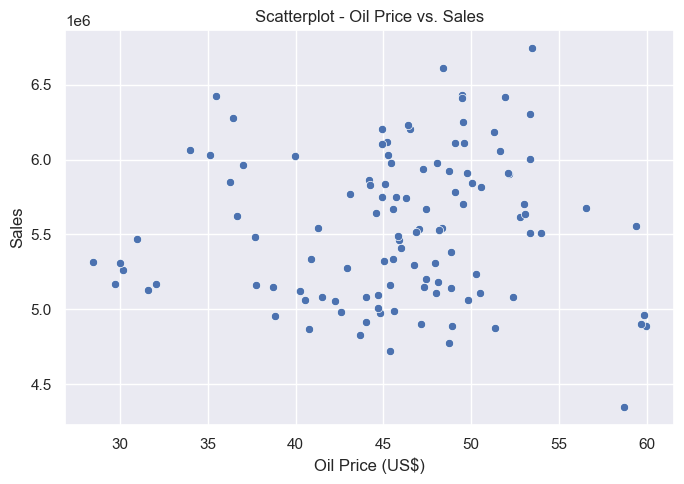

Pearson correlation: 0.055 (0.567)
Spearman correlation: 0.123 (0.197)


In [29]:
df_oil_sales_by_week_after_downfall_no_outliers = remove_outliers_by_iqr(
    df=df_oil_sales_by_week_after_downfall,
    column_name='sales',
    q=1,
    verbose=True
)

# Scatterplot
ax = sns.scatterplot(
    data=df_oil_sales_by_week_after_downfall_no_outliers,
    x='dcoilwtico',
    y='sales'
)

ax.set_title('Scatterplot - Oil Price vs. Sales')

ax.set_xlabel('Oil Price (US$)')
ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

# Correlations
pearson_correlation, pearson_correlation_pvalue = pearsonr(df_oil_sales_by_week_after_downfall_no_outliers['dcoilwtico'], df_oil_sales_by_week_after_downfall_no_outliers['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_oil_sales_by_week_after_downfall_no_outliers['dcoilwtico'], df_oil_sales_by_week_after_downfall_no_outliers['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")


The points seem to be very spread. Let's break it down by granularity.

In [30]:
df_correlation_by_granularity = correlation_stats(df_sales_after_downfall, ['store_nbr', 'family'], x_col='dcoilwtico', y_col='sales')

display(df_correlation_by_granularity)

C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(group_df[x_col], group_df[y_col])
C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(group_df[x_col], group_df[y_col])


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,3.629000e+03,860,-0.131756,5.034251e-05,-0.123238,1.507338e-04
1,1,BABY CARE,0.000000e+00,0,NaN,NaN,NaN,NaN
2,1,BEAUTY,2.565000e+03,830,0.055913,8.648508e-02,0.002450,9.401660e-01
3,1,BEVERAGES,1.801981e+06,938,-0.113255,4.999571e-04,-0.070316,3.102115e-02
4,1,BOOKS,2.110000e+02,127,0.135244,3.150037e-05,0.193693,2.090723e-09
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,5.422348e+04,939,-0.013763,6.732761e-01,0.002387,9.417050e-01
1778,54,PREPARED FOODS,6.625700e+04,939,0.100608,2.001909e-03,0.051151,1.168735e-01
1779,54,PRODUCE,4.929328e+05,803,-0.234505,3.196008e-13,-0.149106,4.357465e-06
1780,54,SCHOOL AND OFFICE SUPPLIES,1.011000e+03,154,0.046273,1.560986e-01,-0.035830,2.722044e-01


In [31]:
# Groups with null correlation
groups_with_null_correlation = df_correlation_by_granularity[
    (df_correlation_by_granularity['pearson_correlation'].isna()) |
    (df_correlation_by_granularity['spearman_correlation'].isna())
    ]

groups_with_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] < 0.05
]

groups_with_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] < 0.05
]

print(f"Groups with null correlation: {len(groups_with_null_correlation)} ({len(groups_with_null_correlation)/len(df_correlation_by_granularity):.2%})")

print(f"Groups with significant pearson correlation: {len(groups_with_significant_pearson_correlation)} ({len(groups_with_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_pearson_correlation)
display(groups_with_significant_pearson_correlation.describe())

print(f"Groups with significant spearman correlation: {len(groups_with_significant_spearman_correlation)} ({len(groups_with_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_spearman_correlation)
display(groups_with_significant_spearman_correlation.describe())

Groups with null correlation: 54 (3.03%)
Groups with significant pearson correlation: 960 (53.87%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,3.629000e+03,860,-0.131756,5.034251e-05,-0.123238,1.507338e-04
3,1,BEVERAGES,1.801981e+06,938,-0.113255,4.999571e-04,-0.070316,3.102115e-02
4,1,BOOKS,2.110000e+02,127,0.135244,3.150037e-05,0.193693,2.090723e-09
6,1,CELEBRATION,1.253800e+04,789,-0.197825,9.302277e-10,-0.213623,3.570029e-11
9,1,DELI,1.264770e+05,938,0.069882,3.207781e-02,0.069798,3.228558e-02
...,...,...,...,...,...,...,...,...
1772,54,MAGAZINES,7.080000e+02,415,-0.101986,1.733126e-03,-0.124671,1.259454e-04
1775,54,PET SUPPLIES,1.400000e+02,109,0.120357,2.150906e-04,0.130341,6.069097e-05
1776,54,PLAYERS AND ELECTRONICS,2.748000e+03,721,-0.113522,4.847762e-04,-0.173924,7.911986e-08
1778,54,PREPARED FOODS,6.625700e+04,939,0.100608,2.001909e-03,0.051151,1.168735e-01


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,960.000000,9.600000e+02,960.000000,960.000000,9.600000e+02,960.000000,9.600000e+02
mean,26.566667,3.701065e+05,779.059375,-0.049939,4.840174e-03,-0.039383,2.244349e-02
std,15.403497,9.620837e+05,224.401681,0.155973,1.015627e-02,0.160626,8.863832e-02
min,1.000000,9.000000e+00,5.000000,-0.448793,7.970208e-48,-0.405471,2.922498e-51
25%,13.000000,4.644750e+03,746.750000,-0.162636,4.246044e-09,-0.168493,1.427110e-09
50%,26.000000,2.201350e+04,839.500000,-0.092714,5.962586e-05,-0.085310,2.205939e-05
75%,40.000000,2.421635e+05,939.000000,0.096728,3.784831e-03,0.105427,2.564439e-03
max,54.000000,8.995770e+06,939.000000,0.365715,4.956795e-02,0.463363,8.754607e-01


Groups with significant spearman correlation: 1017 (57.07%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,3.629000e+03,860,-0.131756,5.034251e-05,-0.123238,1.507338e-04
3,1,BEVERAGES,1.801981e+06,938,-0.113255,4.999571e-04,-0.070316,3.102115e-02
4,1,BOOKS,2.110000e+02,127,0.135244,3.150037e-05,0.193693,2.090723e-09
6,1,CELEBRATION,1.253800e+04,789,-0.197825,9.302277e-10,-0.213623,3.570029e-11
9,1,DELI,1.264770e+05,938,0.069882,3.207781e-02,0.069798,3.228558e-02
...,...,...,...,...,...,...,...,...
1770,54,LINGERIE,3.310000e+03,781,0.095336,3.419485e-03,0.102308,1.675467e-03
1772,54,MAGAZINES,7.080000e+02,415,-0.101986,1.733126e-03,-0.124671,1.259454e-04
1775,54,PET SUPPLIES,1.400000e+02,109,0.120357,2.150906e-04,0.130341,6.069097e-05
1776,54,PLAYERS AND ELECTRONICS,2.748000e+03,721,-0.113522,4.847762e-04,-0.173924,7.911986e-08


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,1017.000000,1.017000e+03,1017.000000,1017.000000,1.017000e+03,1017.000000,1.017000e+03
mean,27.004916,3.572272e+05,767.025565,-0.043709,3.794650e-02,-0.040178,4.650252e-03
std,15.169676,9.385200e+05,237.463415,0.151836,1.259778e-01,0.161885,1.018961e-02
min,1.000000,9.000000e+00,5.000000,-0.448793,7.970208e-48,-0.405471,2.922498e-51
25%,13.000000,4.305000e+03,722.000000,-0.154832,1.170792e-08,-0.168051,1.710070e-09
50%,27.000000,1.923700e+04,831.000000,-0.079429,1.335599e-04,-0.093872,2.478980e-05
75%,40.000000,2.196118e+05,939.000000,0.092309,8.383044e-03,0.104052,2.200563e-03
max,54.000000,8.995770e+06,939.000000,0.365715,9.862503e-01,0.463363,4.919584e-02


Most of the granularities have significant correlation. Let's look at the correlations distribution.

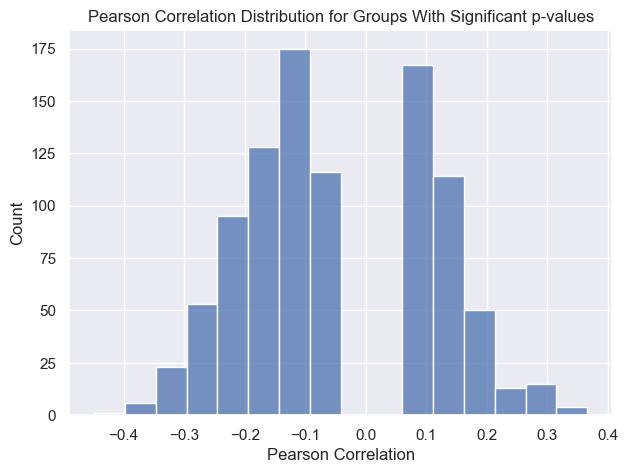

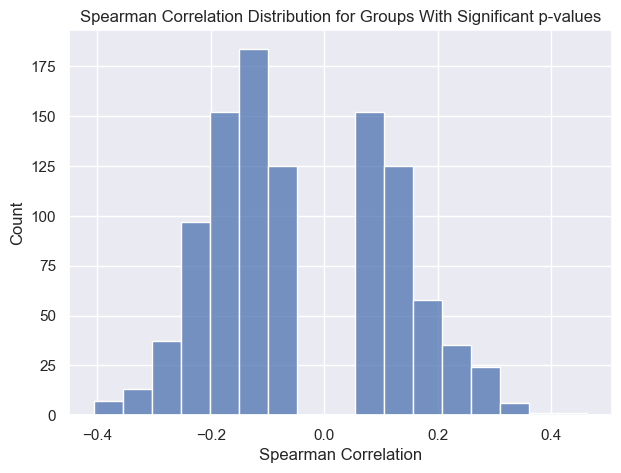

In [32]:
ax = sns.histplot(
    data=groups_with_significant_pearson_correlation,
    x='pearson_correlation'
)

ax.set_title('Pearson Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Pearson Correlation')
plt.show()

ax = sns.histplot(
    data=groups_with_significant_spearman_correlation,
    x='spearman_correlation'
)

ax.set_title('Spearman Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Spearman Correlation')
plt.show()

Mostly weak or moderate positive/negative correlations. Let's look at the groups without significant correlations.

In [33]:
groups_with_no_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] >= 0.05
]

groups_with_no_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] >= 0.05
]


print(f"Groups with no significant pearson correlation: {len(groups_with_no_significant_pearson_correlation)} ({len(groups_with_no_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_pearson_correlation)
display(groups_with_no_significant_pearson_correlation.describe())

print(f"Groups with no significant spearman correlation: {len(groups_with_no_significant_spearman_correlation)} ({len(groups_with_no_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_spearman_correlation)
display(groups_with_no_significant_spearman_correlation.describe())

Groups with no significant pearson correlation: 768 (43.10%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
2,1,BEAUTY,2565.000000,830,0.055913,0.086485,0.002450,0.940166
5,1,BREAD/BAKERY,352324.048955,938,0.013291,0.683865,0.001869,0.954352
7,1,CLEANING,620468.000000,938,-0.005086,0.876187,0.006298,0.846998
8,1,DAIRY,667642.000000,938,-0.039763,0.222991,-0.043620,0.181246
10,1,EGGS,130233.000000,938,0.001896,0.953685,0.006352,0.845704
...,...,...,...,...,...,...,...,...
1773,54,MEATS,52481.764982,939,0.045492,0.163210,0.025590,0.432990
1774,54,PERSONAL CARE,191630.000000,939,-0.025227,0.439549,-0.021516,0.509754
1777,54,POULTRY,54223.475981,939,-0.013763,0.673276,0.002387,0.941705
1780,54,SCHOOL AND OFFICE SUPPLIES,1011.000000,154,0.046273,0.156099,-0.035830,0.272204


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,768.000000,7.680000e+02,768.000000,768.000000,768.000000,768.000000,7.680000e+02
mean,28.455729,4.702180e+05,743.126302,0.002476,0.423599,0.000948,3.827132e-01
std,15.831186,1.215999e+06,298.985025,0.035154,0.286677,0.061505,3.195663e-01
min,1.000000,6.000000e+00,1.000000,-0.063634,0.050814,-0.381643,5.418244e-34
25%,15.000000,3.393250e+03,665.750000,-0.026797,0.163968,-0.025943,9.368452e-02
50%,29.000000,4.406627e+04,921.000000,0.004881,0.361081,0.008293,3.019425e-01
75%,43.000000,2.943826e+05,939.000000,0.031042,0.667214,0.038800,6.746340e-01
max,54.000000,1.015253e+07,939.000000,0.063687,0.999628,0.170145,9.996665e-01


Groups with no significant spearman correlation: 711 (39.90%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
2,1,BEAUTY,2565.000000,830,0.055913,0.086485,0.002450,0.940166
5,1,BREAD/BAKERY,352324.048955,938,0.013291,0.683865,0.001869,0.954352
7,1,CLEANING,620468.000000,938,-0.005086,0.876187,0.006298,0.846998
8,1,DAIRY,667642.000000,938,-0.039763,0.222991,-0.043620,0.181246
10,1,EGGS,130233.000000,938,0.001896,0.953685,0.006352,0.845704
...,...,...,...,...,...,...,...,...
1774,54,PERSONAL CARE,191630.000000,939,-0.025227,0.439549,-0.021516,0.509754
1777,54,POULTRY,54223.475981,939,-0.013763,0.673276,0.002387,0.941705
1778,54,PREPARED FOODS,66257.000000,939,0.100608,0.002002,0.051151,0.116873
1780,54,SCHOOL AND OFFICE SUPPLIES,1011.000000,154,0.046273,0.156099,-0.035830,0.272204


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,711.000000,7.110000e+02,711.000000,711.000000,7.110000e+02,711.000000,711.000000
mean,27.980309,4.966661e+05,757.458509,-0.002233,4.098154e-01,0.005318,0.437047
std,16.233062,1.257659e+06,290.886751,0.042909,3.001477e-01,0.034525,0.297642
min,1.000000,6.000000e+00,1.000000,-0.191969,2.916316e-09,-0.063833,0.050285
25%,14.000000,4.006500e+03,719.000000,-0.030027,1.318455e-01,-0.021472,0.158404
50%,28.000000,6.608046e+04,933.000000,0.001001,3.584686e-01,0.007104,0.376905
75%,43.000000,3.206473e+05,939.000000,0.029879,6.656267e-01,0.034499,0.718606
max,54.000000,1.015253e+07,939.000000,0.137307,9.996277e-01,0.063738,0.999667


Similar distribution of sales.

### 2. 1. 5. Summary

The variable's behavior is different according to every period. A dummy variable will have to be used to indicate if an observation belongs to the period before, during or after the oil price's downfall.

## 2. 2. Promotion

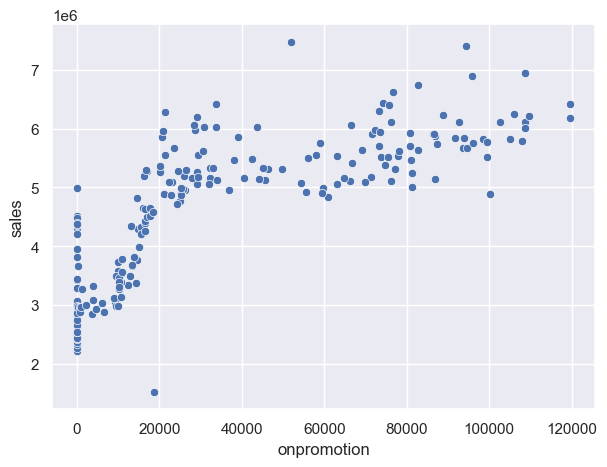

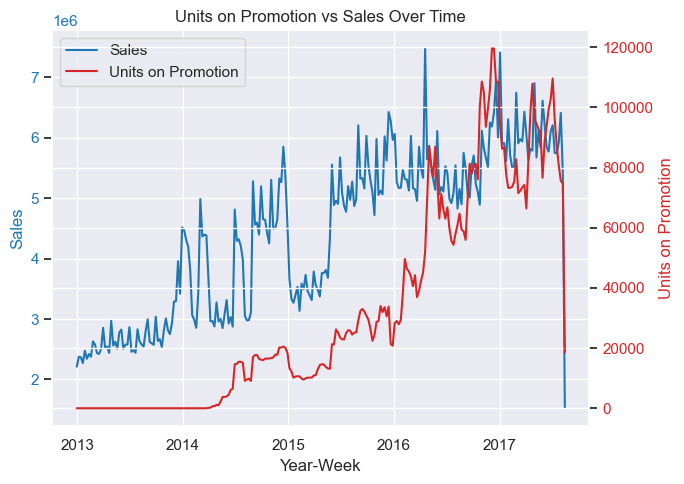

Pearson correlation: 0.575 (0.000)
Spearman correlation: 0.701 (0.000)


In [34]:
# Group promotion by day and week for better visualizations/analysis
df_promotion_and_sales_by_day = df_sales.groupby('date').agg({
    'sales': 'sum',
    'onpromotion': 'sum'
})


df_promotion_and_sales_by_week = df_sales.groupby('year_week').agg({
    'sales': 'sum',
    'onpromotion': 'sum'
})

# Scatterplot

sns.scatterplot(
    data=df_promotion_and_sales_by_week,
    x='onpromotion',
    y='sales'
)

plt.show()

# Double x-axis lineplot
fig, ax1 = plt.subplots()

sns.lineplot(
    data=df_promotion_and_sales_by_week,
    x='year_week',
    y='sales',
    ax=ax1,
    color='tab:blue',
    label='Sales',
    legend=False  
)
ax1.set_ylabel('Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

sns.lineplot(
    data=df_promotion_and_sales_by_week,
    x='year_week',
    y='onpromotion',
    ax=ax2,
    color='tab:red',
    label='Units on Promotion',
    legend=False 
)
ax2.set_ylabel('Units on Promotion', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Year-Week')
ax1.set_title('Units on Promotion vs Sales Over Time')

ax1.legend(
    handles=[ax1.lines[0], ax2.lines[0]],
    labels=['Sales', 'Units on Promotion'],
    loc='upper left'
)

plt.tight_layout()
plt.show()

pearson_correlation, pearson_correlation_pvalue = pearsonr(df_promotion_and_sales_by_day['onpromotion'], df_promotion_and_sales_by_day['sales'])
spearman_correlation, spearman_correlation_pvalue = spearmanr(df_promotion_and_sales_by_day['onpromotion'], df_promotion_and_sales_by_day['sales'])

print(f"Pearson correlation: {pearson_correlation:.3f} ({pearson_correlation_pvalue:.3f})")
print(f"Spearman correlation: {spearman_correlation:.3f} ({spearman_correlation_pvalue:.3f})")

The plots show that the variables move in the same direction, as well as the correlations (that show a strong/moderate positive correlation). Let's remove the rows low sales/items on promotion and check again.

### 2. 2. 2. Removing outliers

In [35]:
display(df_promotion_and_sales_by_week[df_promotion_and_sales_by_week['onpromotion'] > 0].sort_values(by='onpromotion').head(n=10))
display(df_promotion_and_sales_by_week.sort_values(by='sales').head(n=10))

,sales,onpromotion
year_week,,
2014-03-31,3.661813e+06,151
2014-04-07,2.961873e+06,174
2014-04-14,2.966321e+06,682
2014-04-21,2.877355e+06,708
2014-05-05,2.958824e+06,1032
2014-04-28,3.275913e+06,1116
2014-05-12,3.000849e+06,2267
2014-05-19,2.850335e+06,3731
2014-05-26,3.082288e+06,3776


,sales,onpromotion
year_week,,
2017-08-14,1.523584e+06,18648
2012-12-31,2.211570e+06,0
2013-01-21,2.272165e+06,0
2013-02-04,2.342470e+06,0
2013-01-14,2.368007e+06,0
2013-01-07,2.373618e+06,0
2013-02-18,2.377201e+06,0
2013-02-11,2.420609e+06,0
2013-03-18,2.421728e+06,0


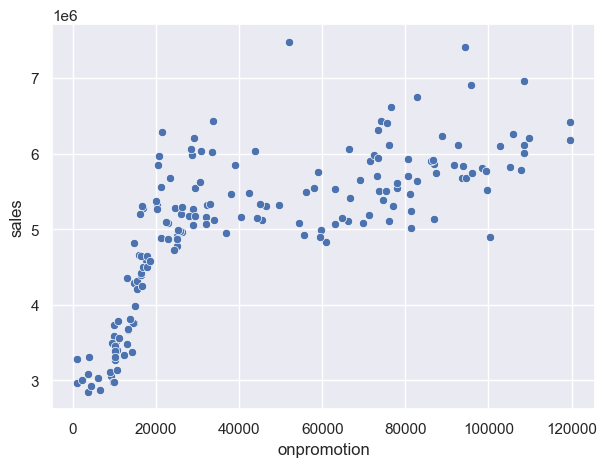

In [36]:
# Scatterplot
df_promotion_and_sales_by_week_no_outliers = df_promotion_and_sales_by_week[df_promotion_and_sales_by_week['onpromotion'] >= 1000]
df_promotion_and_sales_by_week_no_outliers = df_promotion_and_sales_by_week_no_outliers[df_promotion_and_sales_by_week_no_outliers['sales'] >= 2000000]

sns.scatterplot(
    data=df_promotion_and_sales_by_week_no_outliers,
    x='onpromotion',
    y='sales'
)

plt.show()

Still strong correlations.

### 2. 2. 3. By granularity

In [37]:
df_correlation_by_granularity = correlation_stats(df_sales, ['store_nbr', 'family'], x_col='onpromotion', y_col='sales')

display(df_correlation_by_granularity)

C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(group_df[x_col], group_df[y_col])
C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_9876\4152311031.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(group_df[x_col], group_df[y_col])


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,5.475000e+03,1463,0.048558,4.633246e-02,0.073047,2.705280e-03
1,1,BABY CARE,0.000000e+00,0,NaN,NaN,NaN,NaN
2,1,BEAUTY,4.056000e+03,1430,0.371147,3.849338e-56,0.317974,7.118962e-41
3,1,BEVERAGES,2.673769e+06,1678,0.523888,2.431547e-119,0.658449,7.518587e-210
4,1,BOOKS,2.110000e+02,127,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,8.888981e+04,1678,0.167593,4.474367e-12,0.202634,4.600572e-17
1778,54,PREPARED FOODS,1.030900e+05,1679,0.094703,9.936033e-05,0.174329,5.857173e-13
1779,54,PRODUCE,5.961803e+05,1016,0.451783,1.784247e-85,0.671051,7.974029e-221
1780,54,SCHOOL AND OFFICE SUPPLIES,1.023000e+03,162,0.838845,0.000000e+00,0.758274,7.966735e-315


In [38]:
# Groups with null correlation
groups_with_null_correlation = df_correlation_by_granularity[
    (df_correlation_by_granularity['pearson_correlation'].isna()) |
    (df_correlation_by_granularity['spearman_correlation'].isna())
    ]

groups_with_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] < 0.05
]

groups_with_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] < 0.05
]

print(f"Groups with null correlation: {len(groups_with_null_correlation)} ({len(groups_with_null_correlation)/len(df_correlation_by_granularity):.2%})")

print(f"Groups with significant pearson correlation: {len(groups_with_significant_pearson_correlation)} ({len(groups_with_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_pearson_correlation)
display(groups_with_significant_pearson_correlation.describe())

print(f"Groups with significant spearman correlation: {len(groups_with_significant_spearman_correlation)} ({len(groups_with_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_significant_spearman_correlation)
display(groups_with_significant_spearman_correlation.describe())

Groups with null correlation: 182 (10.21%)
Groups with significant pearson correlation: 1394 (78.23%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,5.475000e+03,1463,0.048558,4.633246e-02,0.073047,2.705280e-03
2,1,BEAUTY,4.056000e+03,1430,0.371147,3.849338e-56,0.317974,7.118962e-41
3,1,BEVERAGES,2.673769e+06,1678,0.523888,2.431547e-119,0.658449,7.518587e-210
5,1,BREAD/BAKERY,5.699922e+05,1678,0.285377,6.370502e-33,0.403136,8.025285e-67
7,1,CLEANING,1.078525e+06,1678,0.130672,7.389624e-08,0.157261,8.635961e-11
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,8.888981e+04,1678,0.167593,4.474367e-12,0.202634,4.600572e-17
1778,54,PREPARED FOODS,1.030900e+05,1679,0.094703,9.936033e-05,0.174329,5.857173e-13
1779,54,PRODUCE,5.961803e+05,1016,0.451783,1.784247e-85,0.671051,7.974029e-221
1780,54,SCHOOL AND OFFICE SUPPLIES,1.023000e+03,162,0.838845,0.000000e+00,0.758274,7.966735e-315


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,1394.000000,1.394000e+03,1394.000000,1394.000000,1.394000e+03,1394.000000,1.394000e+03
mean,28.092539,7.480710e+05,1256.954806,0.286623,1.387306e-03,0.336122,7.177998e-03
std,15.602268,1.799595e+06,469.364486,0.188830,5.799866e-03,0.221618,5.775391e-02
min,1.000000,1.200000e+01,6.000000,-0.251008,0.000000e+00,-0.305680,0.000000e+00
25%,15.000000,1.001375e+04,980.250000,0.143764,2.626792e-68,0.161528,1.949191e-99
50%,28.000000,9.576424e+04,1497.000000,0.257347,7.052313e-27,0.298562,3.378433e-36
75%,42.000000,5.229523e+05,1679.000000,0.407322,2.593974e-09,0.483633,1.133636e-11
max,54.000000,1.638606e+07,1679.000000,0.944011,4.780710e-02,0.994238,8.093486e-01


Groups with significant spearman correlation: 1451 (81.43%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
0,1,AUTOMOTIVE,5.475000e+03,1463,0.048558,4.633246e-02,0.073047,2.705280e-03
2,1,BEAUTY,4.056000e+03,1430,0.371147,3.849338e-56,0.317974,7.118962e-41
3,1,BEVERAGES,2.673769e+06,1678,0.523888,2.431547e-119,0.658449,7.518587e-210
5,1,BREAD/BAKERY,5.699922e+05,1678,0.285377,6.370502e-33,0.403136,8.025285e-67
6,1,CELEBRATION,1.678600e+04,999,0.047532,5.115257e-02,0.177589,2.125863e-13
...,...,...,...,...,...,...,...,...
1777,54,POULTRY,8.888981e+04,1678,0.167593,4.474367e-12,0.202634,4.600572e-17
1778,54,PREPARED FOODS,1.030900e+05,1679,0.094703,9.936033e-05,0.174329,5.857173e-13
1779,54,PRODUCE,5.961803e+05,1016,0.451783,1.784247e-85,0.671051,7.974029e-221
1780,54,SCHOOL AND OFFICE SUPPLIES,1.023000e+03,162,0.838845,0.000000e+00,0.758274,7.966735e-315


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,1451.000000,1.451000e+03,1451.000000,1451.000000,1.451000e+03,1451.000000,1.451000e+03
mean,27.869056,7.281839e+05,1254.296347,0.275974,1.830887e-02,0.326950,1.130805e-03
std,15.611559,1.768779e+06,470.677541,0.191938,9.292716e-02,0.222312,5.195437e-03
min,1.000000,1.200000e+01,6.000000,-0.251008,0.000000e+00,-0.305680,0.000000e+00
25%,14.000000,9.290500e+03,978.500000,0.130742,5.486243e-66,0.150873,1.595908e-96
50%,28.000000,8.702622e+04,1497.000000,0.247762,5.500370e-25,0.287719,1.748502e-33
75%,41.000000,5.171505e+05,1679.000000,0.400865,4.146224e-08,0.477255,2.483830e-10
max,54.000000,1.638606e+07,1679.000000,0.944011,9.963542e-01,0.994238,4.650724e-02


Most granularities have significant correlations. Let's look at the correlation distribution.

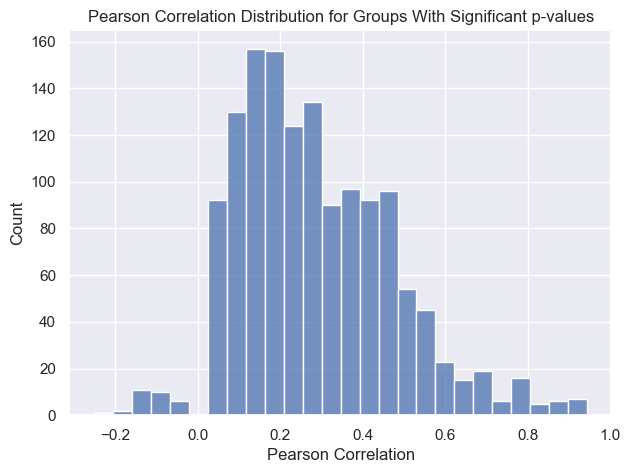

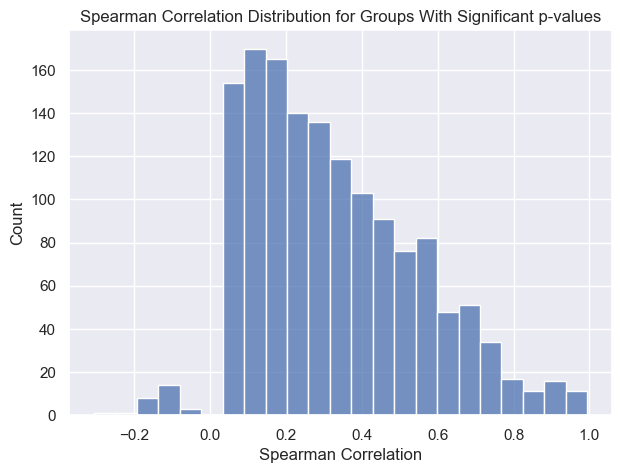

In [39]:
ax = sns.histplot(
    data=groups_with_significant_pearson_correlation,
    x='pearson_correlation'
)

ax.set_title('Pearson Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Pearson Correlation')
plt.show()

ax = sns.histplot(
    data=groups_with_significant_spearman_correlation,
    x='spearman_correlation'
)

ax.set_title('Spearman Correlation Distribution for Groups With Significant p-values')
ax.set_xlabel('Spearman Correlation')
plt.show()

Most of the correlations are positive, weak or moderate. Let's look at the granularities with non-significant correlations.

In [40]:
groups_with_no_significant_pearson_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['pearson_pvalue'] >= 0.05
]

groups_with_no_significant_spearman_correlation = df_correlation_by_granularity[
    df_correlation_by_granularity['spearman_pvalue'] >= 0.05
]


print(f"Groups with no significant pearson correlation: {len(groups_with_no_significant_pearson_correlation)} ({len(groups_with_no_significant_pearson_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_pearson_correlation)
display(groups_with_no_significant_pearson_correlation.describe())

print(f"Groups with no significant spearman correlation: {len(groups_with_no_significant_spearman_correlation)} ({len(groups_with_no_significant_spearman_correlation)/len(df_correlation_by_granularity):.2%})")
display(groups_with_no_significant_spearman_correlation)
display(groups_with_no_significant_spearman_correlation.describe())

Groups with no significant pearson correlation: 206 (11.56%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
6,1,CELEBRATION,16786.000000,999,0.047532,0.051153,0.177589,2.125863e-13
13,1,GROCERY II,36783.000000,1671,0.029478,0.226648,0.042489,8.132047e-02
27,1,PLAYERS AND ELECTRONICS,8913.000000,1002,0.039400,0.106035,0.039869,1.019437e-01
33,2,AUTOMOTIVE,9100.000000,1621,0.042486,0.081337,0.046888,5.438411e-02
43,2,EGGS,314736.000000,1679,-0.046369,0.057117,0.050364,3.877585e-02
...,...,...,...,...,...,...,...,...
1649,50,SEAFOOD,39881.438515,1679,0.006053,0.803956,-0.048563,4.630802e-02
1663,51,GROCERY II,53548.000000,1678,0.029869,0.220539,0.055119,2.370248e-02
1664,51,HARDWARE,2393.000000,1098,0.008329,0.732679,0.019279,4.291573e-01
1667,51,HOME APPLIANCES,1816.000000,896,0.033605,0.168079,0.046329,5.733045e-02


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,206.000000,2.060000e+02,206.000000,206.000000,206.000000,206.000000,2.060000e+02
mean,25.009709,1.484245e+05,1254.684466,0.014086,0.412877,0.040411,2.327588e-01
std,15.333047,3.394610e+05,424.397952,0.023734,0.296387,0.056032,2.828686e-01
min,1.000000,2.950000e+02,222.000000,-0.046810,0.050704,-0.215395,5.061877e-35
25%,11.250000,3.340000e+03,950.250000,-0.000102,0.120824,0.014531,9.014636e-03
50%,25.500000,9.777000e+03,1421.000000,0.017329,0.370840,0.036156,9.673467e-02
75%,38.000000,5.917229e+04,1677.000000,0.033876,0.667440,0.058692,3.364798e-01
max,54.000000,1.801940e+06,1679.000000,0.047624,1.000000,0.294402,9.653699e-01


Groups with no significant spearman correlation: 149 (8.36%)


,store_nbr,family,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
13,1,GROCERY II,36783.0000,1671,0.029478,2.266482e-01,0.042489,0.081320
27,1,PLAYERS AND ELECTRONICS,8913.0000,1002,0.039400,1.060346e-01,0.039869,0.101944
33,2,AUTOMOTIVE,9100.0000,1621,0.042486,8.133696e-02,0.046888,0.054384
47,2,HARDWARE,1972.0000,1019,-0.003045,9.006376e-01,0.003950,0.871336
52,2,LADIESWEAR,29539.0000,1016,0.001854,9.393917e-01,0.006627,0.785815
...,...,...,...,...,...,...,...,...
1640,50,MAGAZINES,7858.0000,994,-0.014601,5.493416e-01,-0.005069,0.835339
1659,51,DELI,436009.4755,1679,0.192425,1.650544e-15,0.047507,0.051272
1664,51,HARDWARE,2393.0000,1098,0.008329,7.326791e-01,0.019279,0.429157
1667,51,HOME APPLIANCES,1816.0000,896,0.033605,1.680787e-01,0.046329,0.057330


,store_nbr,sum_sales,row_count,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
count,149.000000,1.490000e+02,149.000000,149.000000,1.490000e+02,149.000000,149.000000
mean,26.006711,1.126945e+05,1279.704698,0.013534,4.055056e-01,0.016610,0.377944
std,15.408183,2.825949e+05,389.819232,0.051441,3.253420e-01,0.022958,0.272094
min,1.000000,5.570000e+02,375.000000,-0.139902,1.427215e-32,-0.046624,0.050987
25%,12.000000,3.110000e+03,966.000000,-0.003045,8.028578e-02,0.003950,0.150355
50%,26.000000,9.100000e+03,1467.000000,0.013498,3.869501e-01,0.023276,0.300804
75%,39.000000,5.199800e+04,1670.000000,0.029478,6.854790e-01,0.033767,0.620597
max,54.000000,1.801940e+06,1679.000000,0.283838,1.000000e+00,0.047566,0.965370


Similar sales/row count distribution.

### 2. 2. 4. Summary

There is a general positive correlation between the variables. 

## 2. 5. Heatmap

Plot a heatmap between all the numerical features.

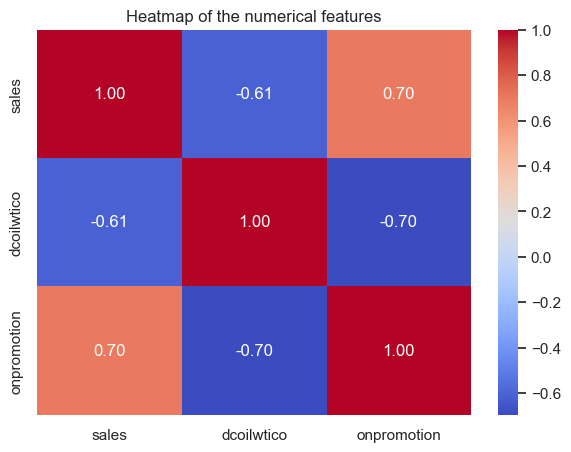

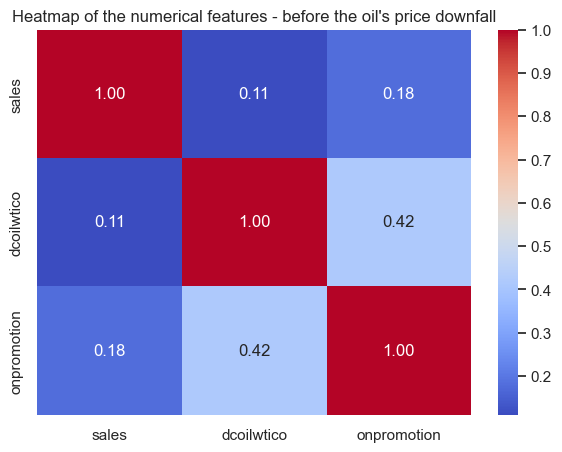

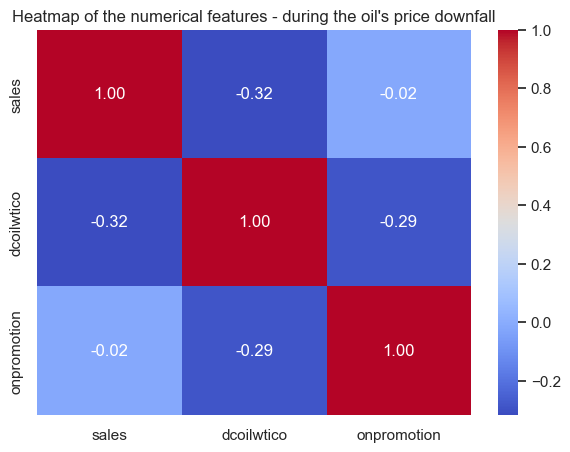

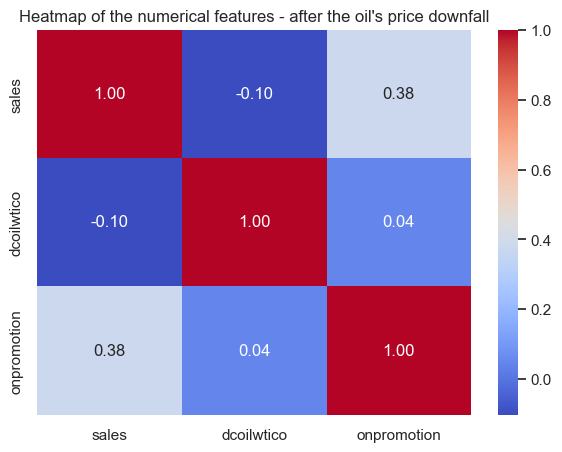

In [41]:
# Whole period
features_by_day = df_sales.groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean',
    'onpromotion': 'sum'
})

corr = features_by_day.corr(method='spearman')

ax = sns.heatmap(
    corr, 
    annot=True,     
    cmap='coolwarm',
    fmt=".2f"       
)

ax.set_title("Heatmap of the numerical features")

plt.show()

# Before the oil price's downfall period
features_by_day_before_downfall = df_sales[df_sales['date'] < oil_price_downfall_period_start].groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean',
    'onpromotion': 'sum'
})

corr = features_by_day_before_downfall.corr(method='spearman')

ax = sns.heatmap(
    corr, 
    annot=True,     
    cmap='coolwarm',
    fmt=".2f"       
)

ax.set_title("Heatmap of the numerical features - before the oil's price downfall")

plt.show()

# During the oil price's downfall period
features_by_day_during_downfall = df_sales[df_sales['date'].between(oil_price_downfall_period_start, oil_price_downfall_period_end)].groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean',
    'onpromotion': 'sum'
})

corr = features_by_day_during_downfall.corr(method='spearman')

ax = sns.heatmap(
    corr, 
    annot=True,     
    cmap='coolwarm',
    fmt=".2f"       
)

ax.set_title("Heatmap of the numerical features - during the oil's price downfall")

plt.show()

# After the oil price's downfall period
features_by_day_after_downfall = df_sales[df_sales['date'] > oil_price_downfall_period_end].groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean',
    'onpromotion': 'sum'
})

corr = features_by_day_after_downfall.corr(method='spearman')

ax = sns.heatmap(
    corr, 
    annot=True,     
    cmap='coolwarm',
    fmt=".2f"       
)

ax.set_title("Heatmap of the numerical features - after the oil's price downfall")

plt.show()

The correlations between the features and the target variable are the same we've seen before. However, we can see that the correlation between oil price's and items on promotion change according to the period. It emphasizes the need to create a dummy variable according to the oil price period (before/during/after the downfall).

# 3. Correlation between categorical features and target variable

## 3. 1. Store city

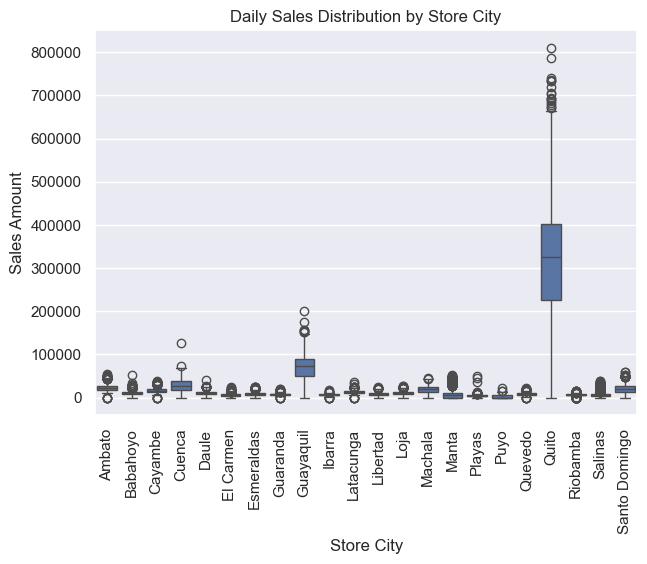

In [42]:
df_sales_by_day = df_sales.groupby(['store_city', 'date'])['sales'].sum().reset_index()

ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_city',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Store City')

ax.set_xlabel('Store City')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()

We can see a significant difference between the amount of sales between the cities, since Quito (Ecuador's capital) has a much bigger amount of sales. Guayaquil, a big city, also has a bigger amount. 
Let's see those results without Quito.

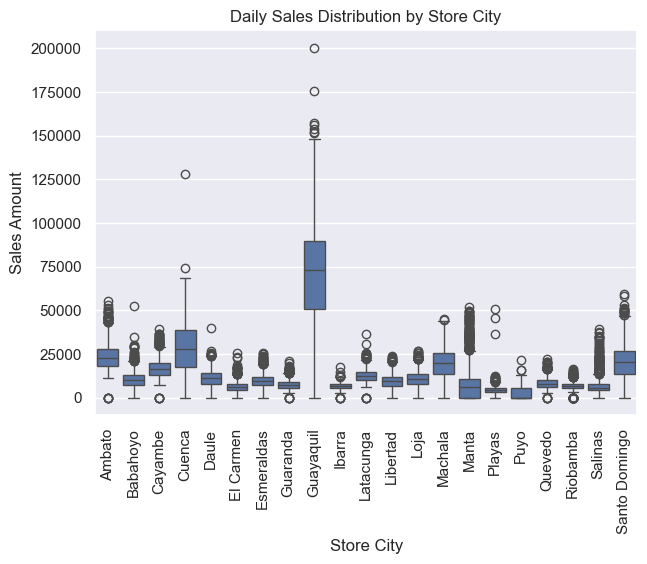

In [43]:
df_sales_by_day = df_sales_by_day[df_sales_by_day['store_city'] != 'Quito']

ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_city',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Store City')

ax.set_xlabel('Store City')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()

Also a visible difference between the cities.

Let's check it without Guayaquil, so we see only the cities with less sales than the 2 biggest ones.

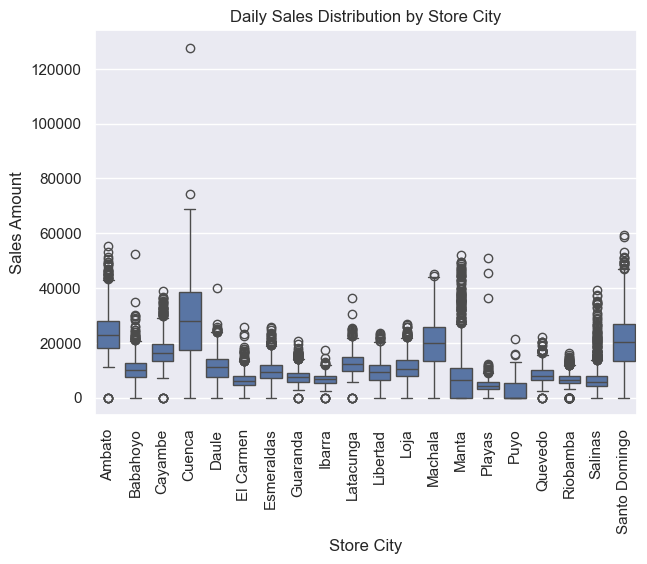

In [44]:
df_sales_by_day = df_sales_by_day[df_sales_by_day['store_city'] != 'Guayaquil']

ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_city',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Store City')

ax.set_xlabel('Store City')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()

Again, a visible difference between the cities.

By those results, we can see that there is a significant correlation between store city and sales. However, this feature will only be useful if an unique model will be used for the whole data. If a single model will be trained for each granularity, it will be useless, since the model's granularity is store/family/day, and a store belongs to one city only.

## 3. 2. Store state

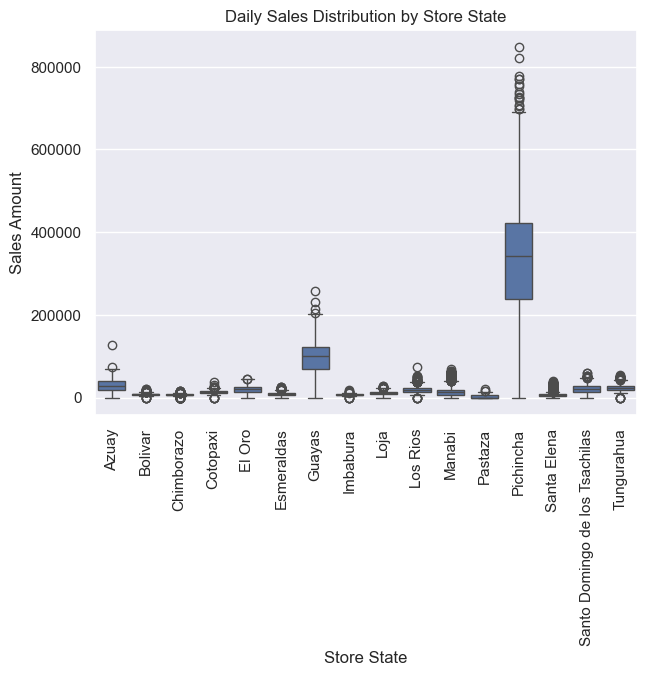

In [45]:
df_sales_by_day = df_sales.groupby(['store_state', 'date'])['sales'].sum().reset_index()

ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_state',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Store State')

ax.set_xlabel('Store State')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()


We can see a big difference in the sales amount in Pichincha (Quito's state) and Guayas (Guayquil's state). Let's remove Pichincha (Quito's state) and check again.

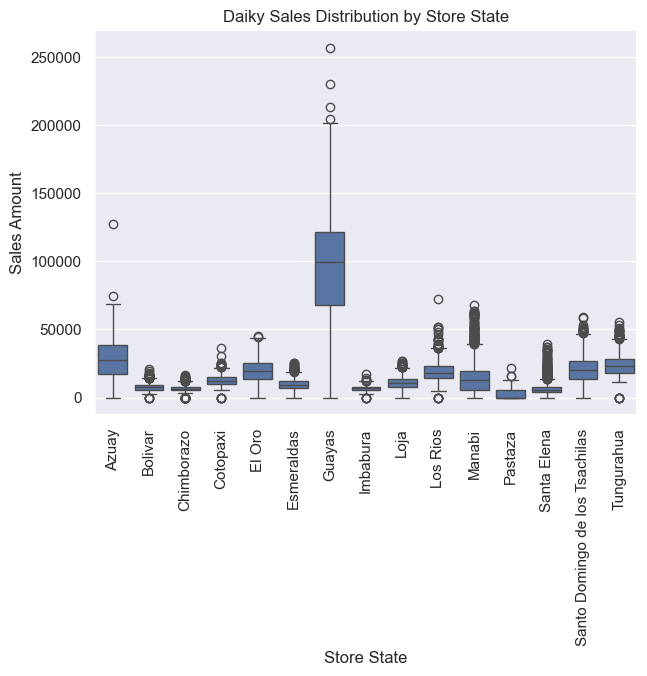

In [46]:
df_sales_by_day = df_sales_by_day[df_sales_by_day['store_state'] != 'Pichincha']
 
ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_state',
    y='sales'    
)

ax.set_title('Daiky Sales Distribution by Store State')

ax.set_xlabel('Store State')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()

Same behavior. Let's look at it without Guayas.

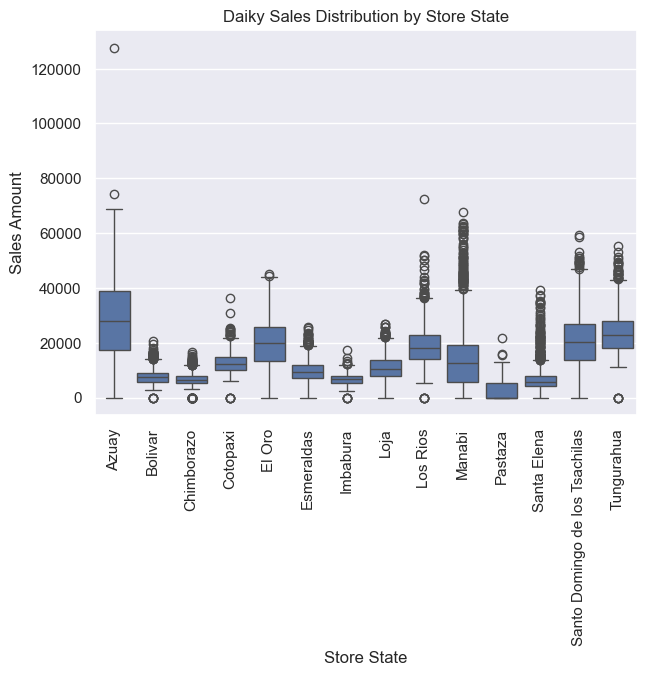

In [47]:
df_sales_by_day = df_sales_by_day[df_sales_by_day['store_state'] != 'Guayas']
 
ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_state',
    y='sales'    
)

ax.set_title('Daiky Sales Distribution by Store State')

ax.set_xlabel('Store State')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()

A visible difference in sales.

Therefore, there is a clear correlation between the store's state and the sales. However, the same thing than the city must be said: it will only be useful if a single model is trained for the whole data.

## 3. 3. Store type

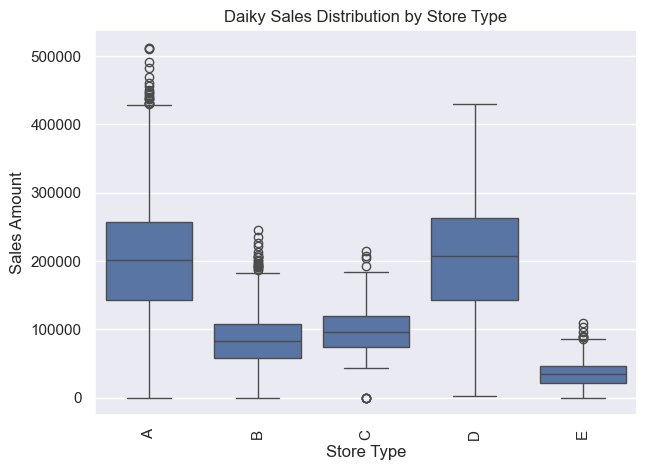

In [48]:
df_sales_by_day = df_sales.groupby(['store_type', 'date'])['sales'].sum().reset_index()

ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_type',
    y='sales'    
)

ax.set_title('Daiky Sales Distribution by Store Type')

ax.set_xlabel('Store Type')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()

The plot and the correlation metrics show a difference of the sales amount between the store types, with A and D being the types with the most sales.

The same thing about store state and city must be said about store type.

## 3. 4. Store cluster

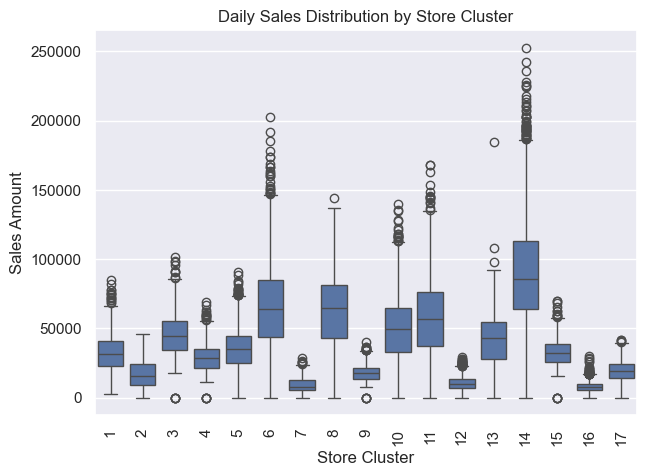

In [49]:
df_sales_by_day = df_sales.groupby(['store_cluster', 'date'])['sales'].sum().reset_index()

ax = sns.boxplot(
    data=df_sales_by_day,
    x='store_cluster',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Store Cluster')

ax.set_xlabel('Store Cluster')
ax.set_ylabel('Sales Amount')

plt.xticks(rotation=90)

plt.show()

A visible diference in the sales amount, with clusters 6, 8, 11 and 14 having a bigger daily sales amount. The same thing about the previous categorical variables need to be said about this one.

## 3. 5. National events/holidays

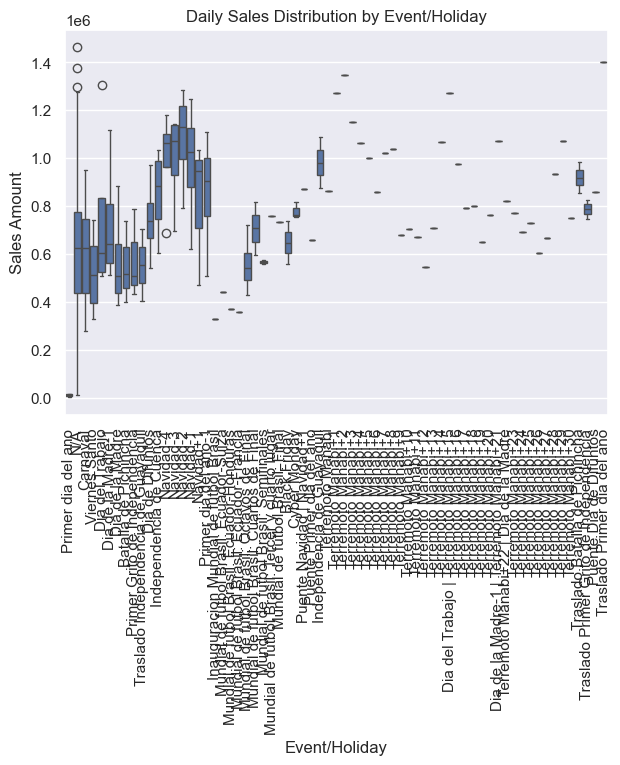

In [50]:
df_sales_by_day = df_sales.groupby(['date', 'event_description_national'])['sales'].sum().reset_index()

ax = sns.boxplot(
    data=df_sales_by_day,
    x='event_description_national',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Event/Holiday')

ax.set_xlabel('Event/Holiday')
ax.set_ylabel('Sales Amount')

plt.rcParams['figure.figsize'] = (20, 12)

plt.xticks(rotation=90)

plt.show()

## 3. 6. Regional events/holidays

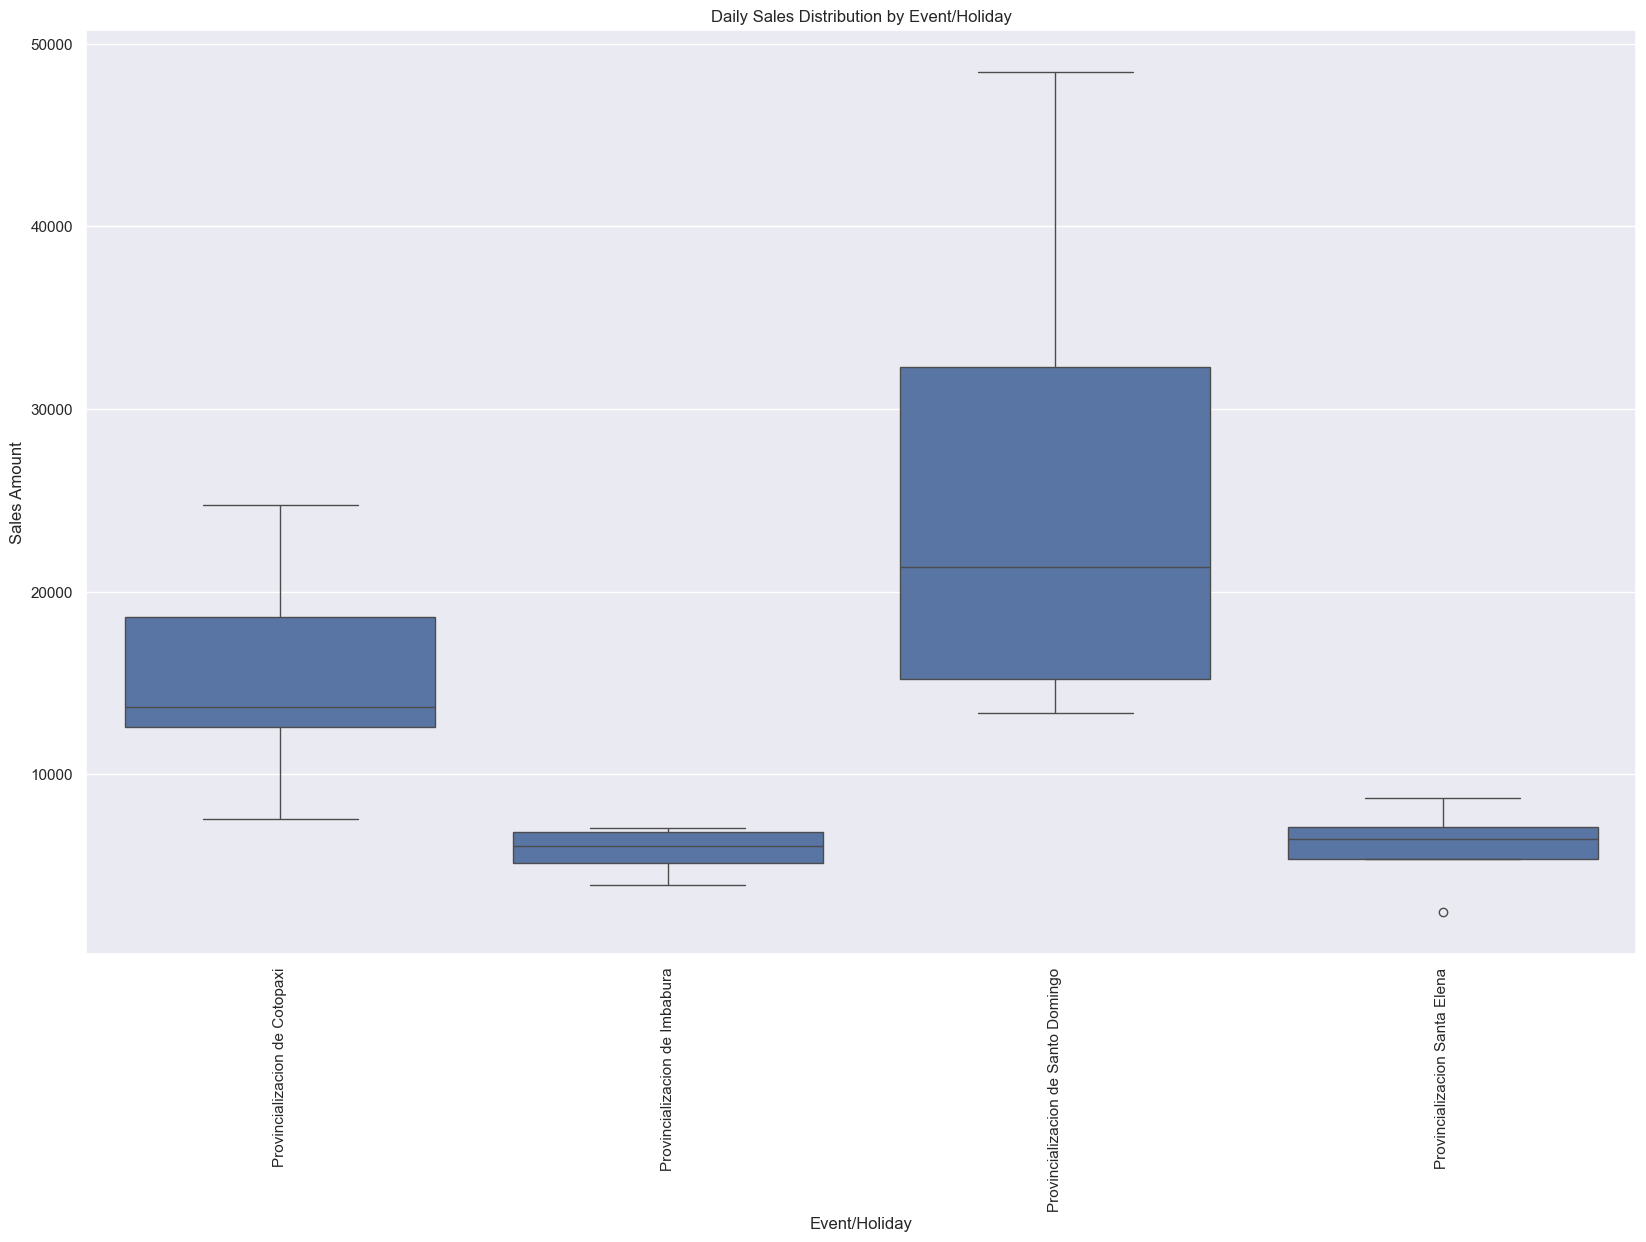

In [51]:
df_sales_by_day = df_sales.groupby(['date', 'event_description_regional'])['sales'].sum().reset_index()

ax = sns.boxplot(
    # Remove rows with no events for a better visualization
    data=df_sales_by_day[df_sales_by_day['event_description_regional'] != 'N/A'],
    x='event_description_regional',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Event/Holiday')

ax.set_xlabel('Event/Holiday')
ax.set_ylabel('Sales Amount')

plt.rcParams['figure.figsize'] = (20, 12)

plt.xticks(rotation=90)

plt.show()

## 3. 7. Local events/holidays

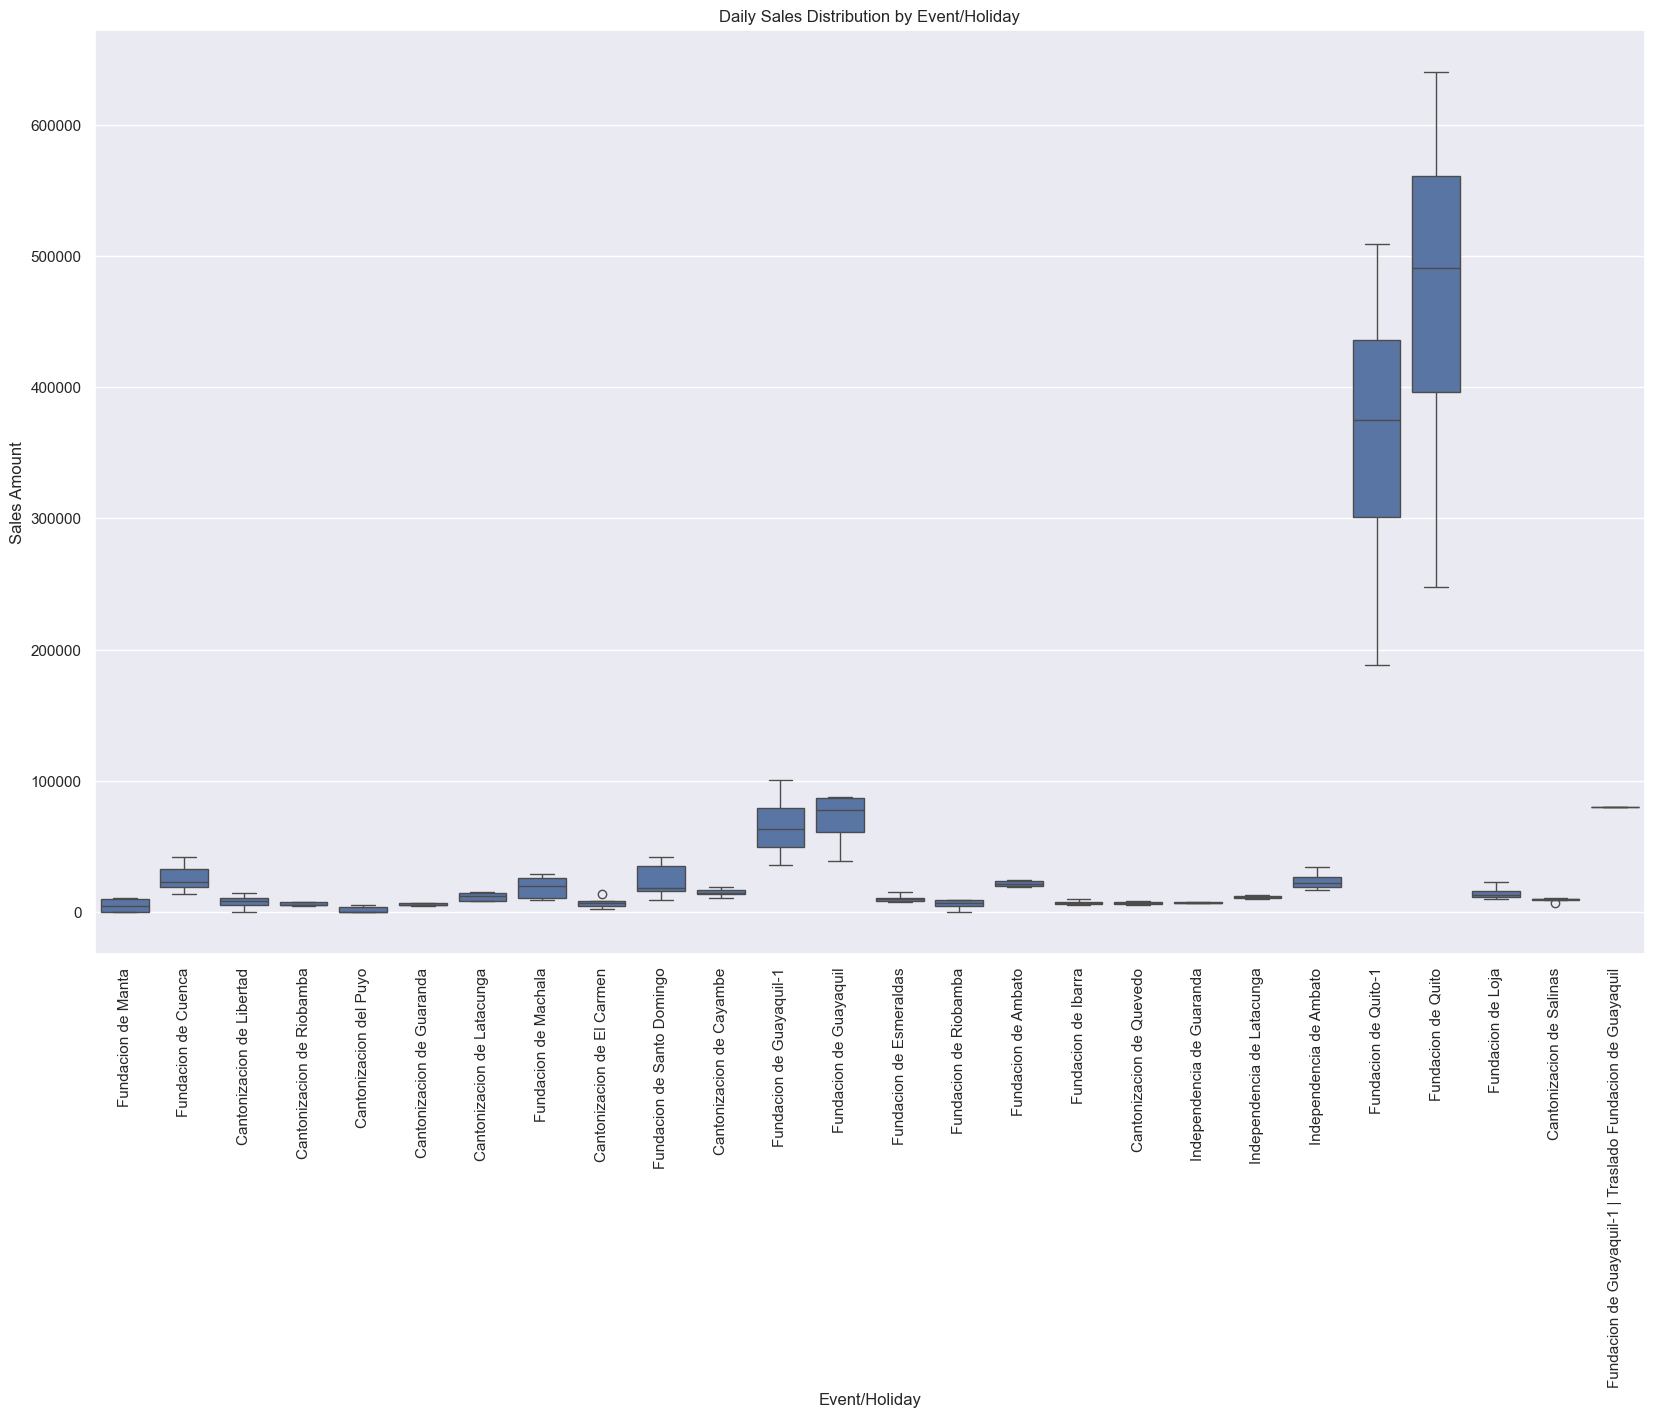

In [52]:
df_sales_by_day = df_sales.groupby(['date', 'event_description_local'])['sales'].sum().reset_index()

ax = sns.boxplot(
    # Remove rows with no events for a better visualization
    data=df_sales_by_day[df_sales_by_day['event_description_local'] != 'N/A'],
    x='event_description_local',
    y='sales'    
)

ax.set_title('Daily Sales Distribution by Event/Holiday')

ax.set_xlabel('Event/Holiday')
ax.set_ylabel('Sales Amount')

plt.rcParams['figure.figsize'] = (20, 12)

plt.xticks(rotation=90)

plt.show()

We can see in the plots that the national, regional and local events have a significant difference in the sales amount.

# 4. Autocorrelation

## 4. 1. Whole data

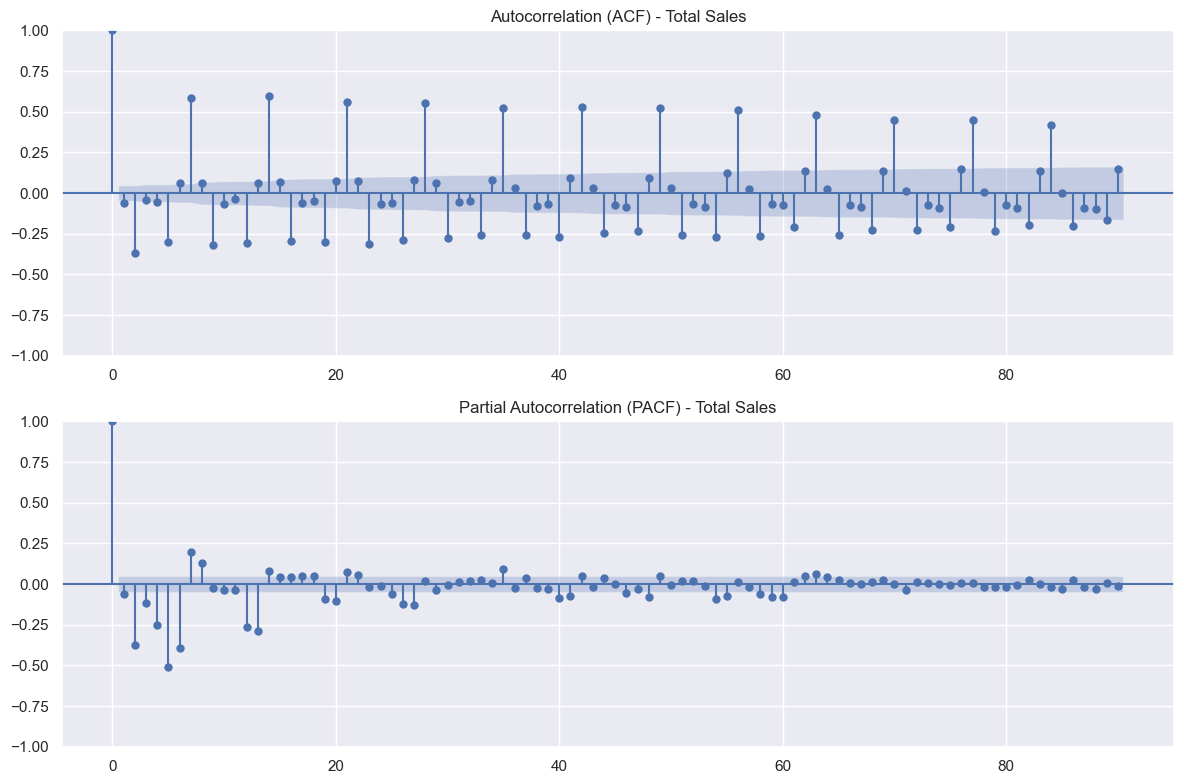

In [53]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Aggregated series
df_sales_daily = df_sales.groupby('date')['sales'].sum().reset_index()

# Using diff for series to be non-stationary
diff_sales = df_sales_daily['sales'].diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(diff_sales, ax=axes[0], lags=90)
axes[0].set_title('Autocorrelation (ACF) - Total Sales')

plot_pacf(diff_sales, ax=axes[1], lags=90)
axes[1].set_title('Partial Autocorrelation (PACF) - Total Sales')

plt.tight_layout()
plt.show()


We can see a clear weekly seasonal pattern in the plots, with peaks at each 7 days. This probably means that there are days of the week with more sales. Now, we are going to:

- check which days of the weeks have more sales;
- calculate the sales differentiation again with lag 7 and check if the series remains stationary to check the weekly seasonality pattern.


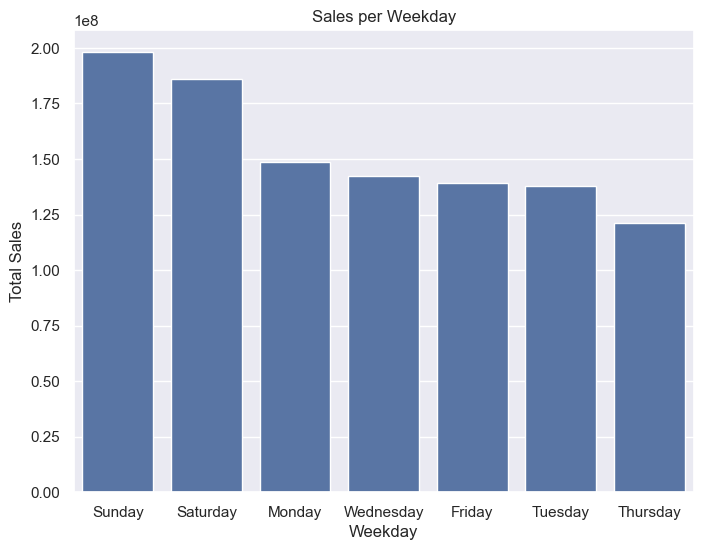

,weekday,sales
3,Sunday,1.980523e+08
2,Saturday,1.861015e+08
1,Monday,1.488278e+08
6,Wednesday,1.423787e+08
0,Friday,1.390978e+08
5,Tuesday,1.379221e+08
4,Thursday,1.212646e+08


In [54]:
df_sales_daily_weekday = df_sales_daily.copy()

df_sales_daily_weekday['weekday'] = df_sales_daily_weekday['date'].dt.strftime('%A')

df_sales_daily_weekday = df_sales_daily_weekday.groupby('weekday').agg({
    'sales': 'sum'
}).reset_index()

df_sales_daily_weekday = df_sales_daily_weekday.sort_values(by='sales', ascending=False)

plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.barplot(
    data=df_sales_daily_weekday,
    x='weekday',
    y='sales'
)

ax.set_title('Sales per Weekday')
ax.set_xlabel('Weekday')
ax.set_ylabel('Total Sales')

plt.show()

display(df_sales_daily_weekday)

Cleary more sales on the weekends.

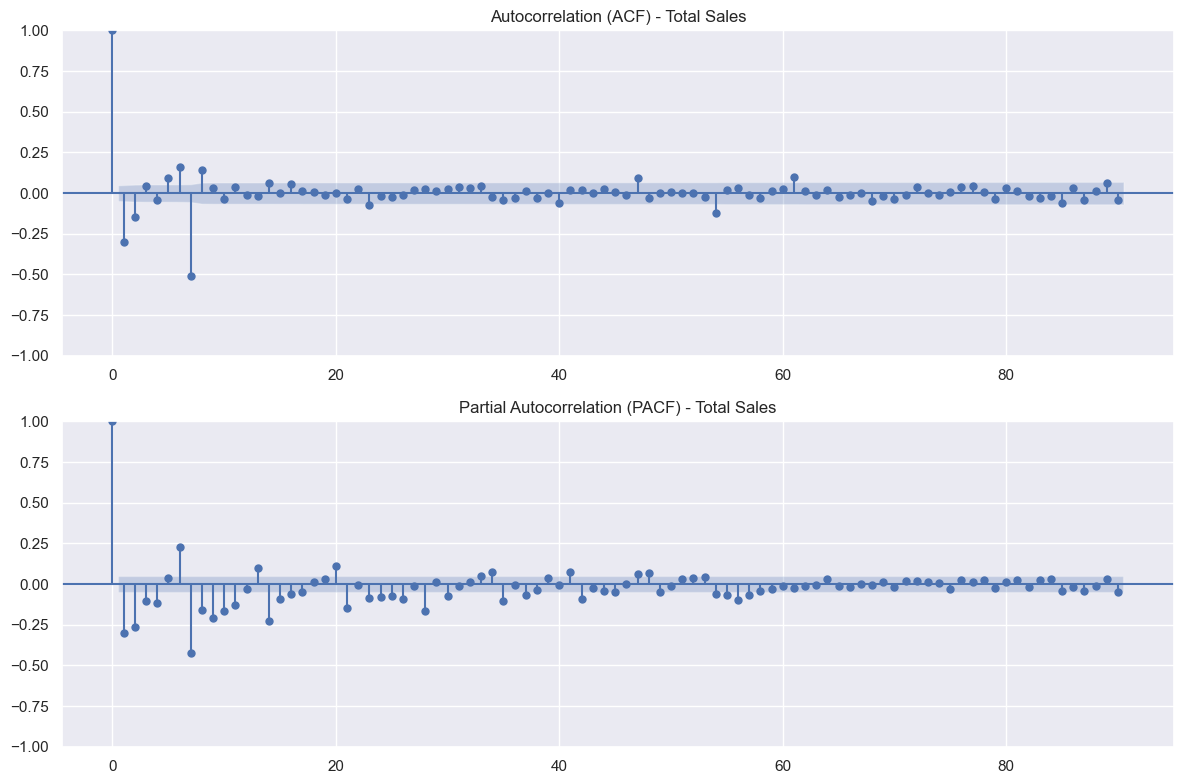

In [55]:
diff_sales = diff_sales.diff(7).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(diff_sales, ax=axes[0], lags=90)
axes[0].set_title('Autocorrelation (ACF) - Total Sales')

plot_pacf(diff_sales, ax=axes[1], lags=90)
axes[1].set_title('Partial Autocorrelation (PACF) - Total Sales')

plt.tight_layout()
plt.show()


We can see that the 7-day peaks disappeared and the series is stationary, confirming the weekly seasonality.

## 4. 2. By Granularity

In [56]:
from statsmodels.tsa.stattools import acf, pacf
from tqdm import tqdm
from statsmodels.tsa.stattools import adfuller

results = []

for (store, family), group in tqdm(df_sales.groupby(['store_nbr', 'family']), desc='Calculating ACF and PACF by group'):
    series = group.sort_values('date')['sales']

    try:
        result = adfuller(series)

        if result[1] > 0.05:
            series_test = series.diff(1).dropna()
        else:
            series_test = series.copy()
    except:
        series_test = series.copy()
    
    # Calculate ACF and PACF up to 90 lags
    acf_values = acf(series_test, nlags=90, missing='drop')
    pacf_values = pacf(series_test, nlags=90) 
    
    results.append({
        'store_nbr': store,
        'family': family,
        
        # ACF values
        'acf_lag1': acf_values[1] if len(acf_values) > 1 else None,
        'acf_lag7': acf_values[7] if len(acf_values) > 7 else None,
        'acf_lag30': acf_values[30] if len(acf_values) > 30 else None,
        'acf_lag90': acf_values[90] if len(acf_values) > 90 else None,
        
        # PACF values
        'pacf_lag1': pacf_values[1] if len(pacf_values) > 1 else None,
        'pacf_lag7': pacf_values[7] if len(pacf_values) > 7 else None,
        'pacf_lag30': pacf_values[30] if len(pacf_values) > 30 else None,
        'pacf_lag90': pacf_values[90] if len(pacf_values) > 90 else None,
        
        # General info
        'total_sales': series.sum(),
        'n_obs': len(series[series > 0])
    })

# Convert to DataFrame
df_corr = pd.DataFrame(results)

def classify_pattern(row):
    if row['acf_lag7'] and abs(row['acf_lag7']) > 0.5:
        return 'weekly seasonality (strong ACF)'
    elif row['acf_lag30'] and abs(row['acf_lag30']) > 0.5:
        return 'monthly seasonality (strong ACF)'   
    elif row['pacf_lag1'] and abs(row['pacf_lag1']) > 0.5:
        return 'short-term dependency (strong PACF)'
    else:
        return 'noisy / weak autocorrelation'

df_corr['pattern'] = df_corr.apply(classify_pattern, axis=1)

df_corr.head()


Calculating ACF and PACF by group:   0%|          | 1/1782 [00:02<1:09:23,  2.34s/it]c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
Calculating ACF and PACF by group:  15%|█▌        | 268/1782 [03:03<21:04,  1.20it/s]c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is sing

,store_nbr,family,acf_lag1,acf_lag7,acf_lag30,acf_lag90,pacf_lag1,pacf_lag7,pacf_lag30,pacf_lag90,total_sales,n_obs,pattern
0,1,AUTOMOTIVE,0.100196,0.161336,0.058470,0.079064,0.100255,0.138279,-0.003081,-0.007906,5475.0,1463,noisy / weak autocorrelation
1,1,BABY CARE,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,0,noisy / weak autocorrelation
2,1,BEAUTY,0.141335,0.179576,0.099971,0.040442,0.141419,0.133499,0.022139,-0.003968,4056.0,1430,noisy / weak autocorrelation
3,1,BEVERAGES,0.570290,0.788129,0.402848,0.352489,0.570629,0.618071,-0.068907,0.051349,2673769.0,1678,weekly seasonality (strong ACF)
4,1,BOOKS,-0.414634,0.029617,0.092334,0.019164,-0.414881,-0.178841,-0.029448,0.042315,211.0,127,noisy / weak autocorrelation


In [74]:
display(df_corr.sort_values(by='total_sales', ascending=False).head(n=50))

,store_nbr,family,acf_lag1,acf_lag7,acf_lag30,acf_lag90,pacf_lag1,pacf_lag7,pacf_lag30,pacf_lag90,total_sales,n_obs,pattern
1431,44,GROCERY I,0.375548,0.496789,-0.025751,0.228594,0.375771,0.373210,-0.005437,0.050970,1.638606e+07,1679,noisy / weak autocorrelation
1464,45,GROCERY I,0.451661,0.484372,0.071073,0.294822,0.451929,0.338984,-0.027514,0.002094,1.634975e+07,1679,noisy / weak autocorrelation
1530,47,GROCERY I,0.535765,0.701043,0.097620,0.426878,0.536083,0.455130,0.104665,-0.015162,1.551453e+07,1679,weekly seasonality (strong ACF)
1497,46,GROCERY I,0.508897,0.682091,-0.009706,0.420586,0.509200,0.416043,0.042739,0.005625,1.434226e+07,1679,weekly seasonality (strong ACF)
1422,44,BEVERAGES,0.666953,0.829340,0.250756,0.459775,0.667349,0.494839,0.047104,-0.008942,1.341786e+07,1679,weekly seasonality (strong ACF)
78,3,GROCERY I,0.547871,0.619485,0.092767,0.337136,0.548197,0.357005,0.054335,-0.017054,1.297047e+07,1679,weekly seasonality (strong ACF)
1563,48,GROCERY I,0.488189,0.673765,-0.004896,0.432251,0.488479,0.459094,0.104451,0.008041,1.283099e+07,1679,weekly seasonality (strong ACF)
1455,45,BEVERAGES,-0.035068,0.683083,-0.215852,0.185057,-0.035089,0.188278,-0.006401,0.000343,1.137035e+07,1679,weekly seasonality (strong ACF)
69,3,BEVERAGES,0.740345,0.854814,0.395857,0.514629,0.740785,0.495592,0.041859,0.028792,1.135159e+07,1679,weekly seasonality (strong ACF)
1596,49,GROCERY I,0.736076,0.732850,0.440252,0.484491,0.736513,0.354791,0.035028,-0.021337,1.108798e+07,1679,weekly seasonality (strong ACF)


pattern
noisy / weak autocorrelation           973
weekly seasonality (strong ACF)        621
short-term dependency (strong PACF)    188
Name: count, dtype: int64

,pattern,total_sales
2,weekly seasonality (strong ACF),7.243329e+08
0,noisy / weak autocorrelation,2.755329e+08
1,short-term dependency (strong PACF),7.377915e+07


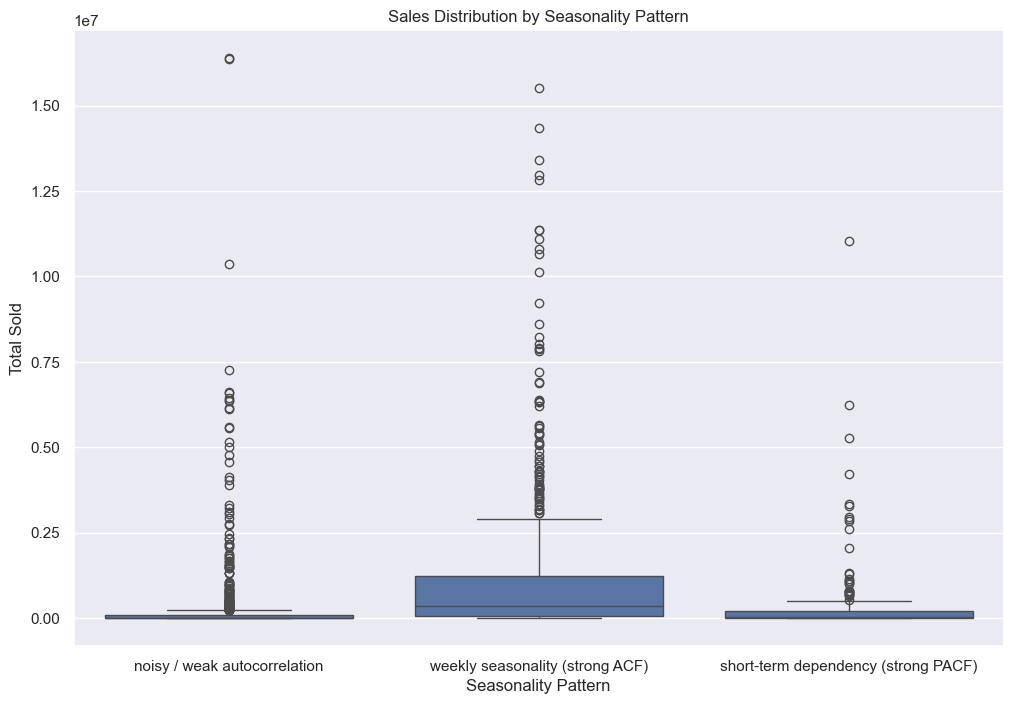

In [57]:
display(df_corr['pattern'].value_counts())
display(df_corr.groupby('pattern')['total_sales'].sum().reset_index().sort_values(by='total_sales', ascending=False))

plt.rcParams['figure.figsize'] = (12, 8)

ax = sns.boxplot(
    data=df_corr,
    x='pattern',
    y='total_sales'
)

ax.set_title('Sales Distribution by Seasonality Pattern')
ax.set_xlabel('Seasonality Pattern')
ax.set_ylabel('Total Sold')

plt.show()

We can see that the granularities with a strong weekly seasonality are the ones that sell the most. Therefore, it's mandatory to choose features and models for it to be recognized.

However, noisy and short-term dependency granularities still represent a lot of sales. So it will probably be needed to choose different models for different types of series.

# 5. Correlation between the features themselves

## 5. 1. Categorical features vs. categorical features

In [58]:
import numpy as np

categorical_features = ['store_city', 'store_state', 'store_type', 'store_cluster', 'event_description_national', 'event_description_regional', 'event_description_local']

for i in range(len(categorical_features)):
    for j in range(i + 1, len(categorical_features) ):
        col_1 = categorical_features[i]
        col_2 = categorical_features[j]

        df_sales_aux = df_sales.copy()

        contingency_table = pd.crosstab(df_sales_aux[col_1], df_sales_aux[col_2])

        try:
            # Calculate Cramér's V value
            chi2, _, _, _ = chi2_contingency(contingency_table)

            n = contingency_table.sum().sum()
            k = min(contingency_table.shape) - 1

            cramers_v_value = np.sqrt(chi2 / (n * k))

            print(f"Feature 1: {col_1}")
            print(f"Feature 2: {col_2}")


            print(f"Cramér's V value: {cramers_v_value:.2f}")

            if cramers_v_value < 0.1:
                print('Very weak association')
            elif cramers_v_value < 0.3:
                print('Weak association')
            elif cramers_v_value <= 0.5:
                print('Moderate association')
            else:
                print('Strong association')

            print('------------------------\n\n')
        except Exception as ex:
            print(ex)

Feature 1: store_city
Feature 2: store_state
Cramér's V value: 1.00
Strong association
------------------------


Feature 1: store_city
Feature 2: store_type
Cramér's V value: 0.63
Strong association
------------------------


Feature 1: store_city
Feature 2: store_cluster
Cramér's V value: 0.61
Strong association
------------------------


Feature 1: store_city
Feature 2: event_description_national
Cramér's V value: 0.00
Very weak association
------------------------


Feature 1: store_city
Feature 2: event_description_regional
Cramér's V value: 0.05
Very weak association
------------------------


Feature 1: store_city
Feature 2: event_description_local
Cramér's V value: 0.06
Very weak association
------------------------


Feature 1: store_state
Feature 2: store_type
Cramér's V value: 0.52
Strong association
------------------------


Feature 1: store_state
Feature 2: store_cluster
Cramér's V value: 0.57
Strong association
------------------------


Feature 1: store_state
Feature 2:

We can see that most of the store info is dependent between themselves. This is expected for store city and state, but not so much for store city/state and store type/cluster. This probably means that stores are classified on clusters/types based on their location. Let's check it out.

In [59]:
display(df_sales[['store_cluster', 'store_city']].drop_duplicates().sort_values(by='store_cluster'))
display(df_sales[['store_type', 'store_city']].drop_duplicates().sort_values(by='store_type'))
display(df_sales[['store_cluster', 'store_state']].drop_duplicates().sort_values(by='store_cluster'))
display(df_sales[['store_type', 'store_state']].drop_duplicates().sort_values(by='store_type'))

,store_cluster,store_city
627,1,Daule
561,1,Salinas
528,1,Guayaquil
990,2,Cuenca
858,3,Quevedo
759,3,Guayaquil
924,3,Playas
1122,3,Machala
1617,3,El Carmen
231,3,Santo Domingo


,store_type,store_city
1551,A,Manta
1518,A,Guayaquil
1485,A,Ambato
1254,A,Quito
792,B,Babahoyo
66,B,Cayambe
297,B,Quito
1056,B,Cuenca
429,B,Santo Domingo
891,B,Guayaquil


,store_cluster,store_state
561,1,Santa Elena
528,1,Guayas
990,2,Azuay
858,3,Los Rios
759,3,Guayas
1122,3,El Oro
1617,3,Manabi
231,3,Santo Domingo de los Tsachilas
1155,4,El Oro
1023,4,Loja


,store_type,store_state
1551,A,Manabi
1518,A,Guayas
1485,A,Tungurahua
1254,A,Pichincha
792,B,Los Rios
66,B,Pichincha
1056,B,Azuay
429,B,Santo Domingo de los Tsachilas
891,B,Guayas
1122,C,El Oro


We can see that the store types/clusters are not equally distributed by place. The correlation between by features may be a problem for some models (like linear ones), leading to instability or under/overfitting. However, this is not a problem at all if different models are trained for each granularity.

## 5 2. Categorical features vs. numerical features

### 5. 2. 1. Oil price

### 5. 2. 1. 1. Before oil price downfall

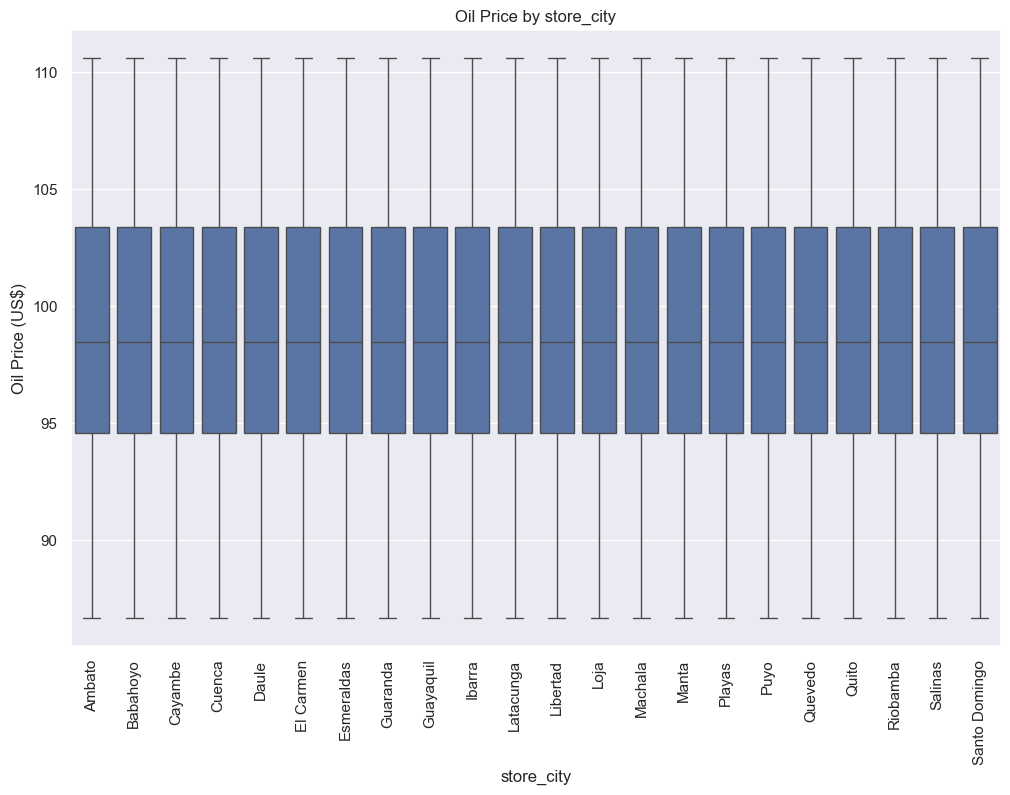

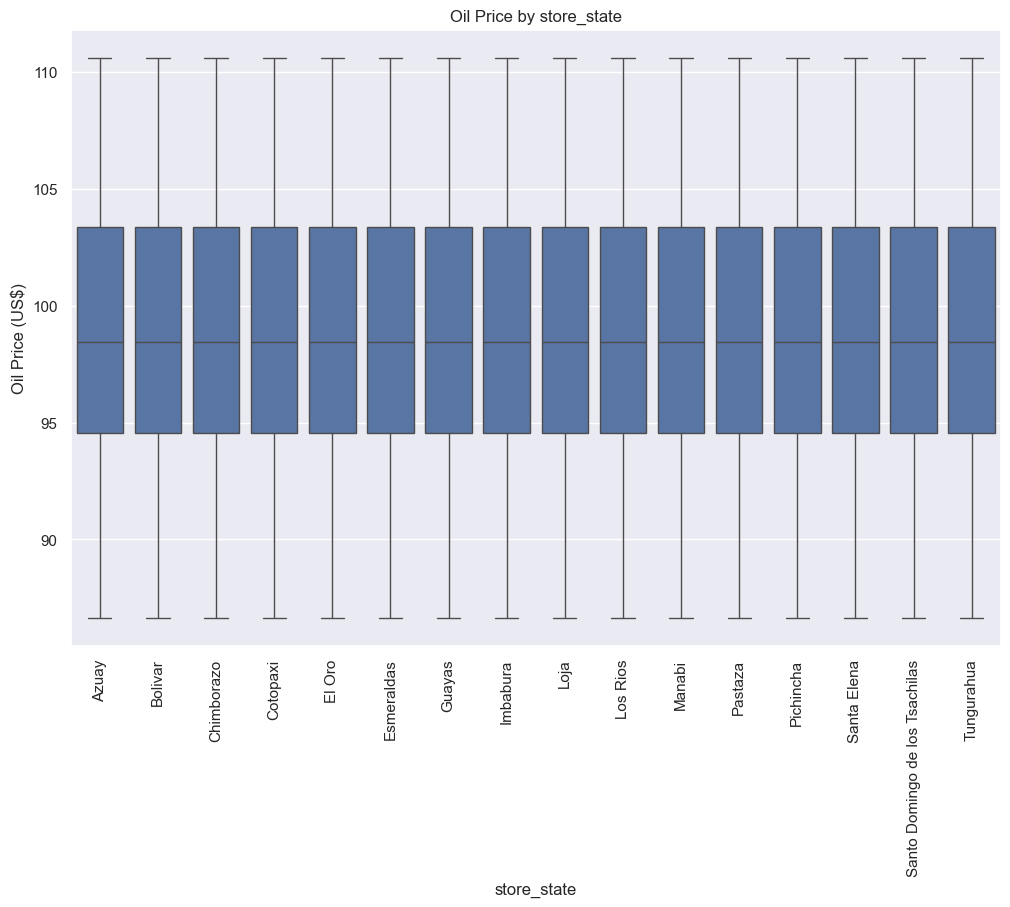

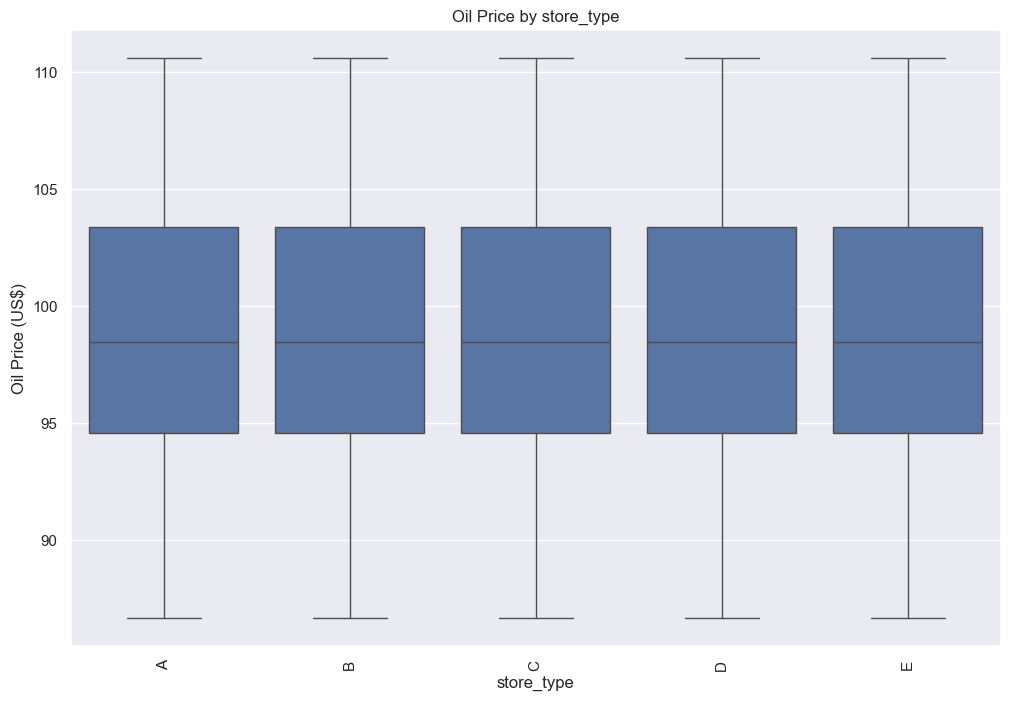

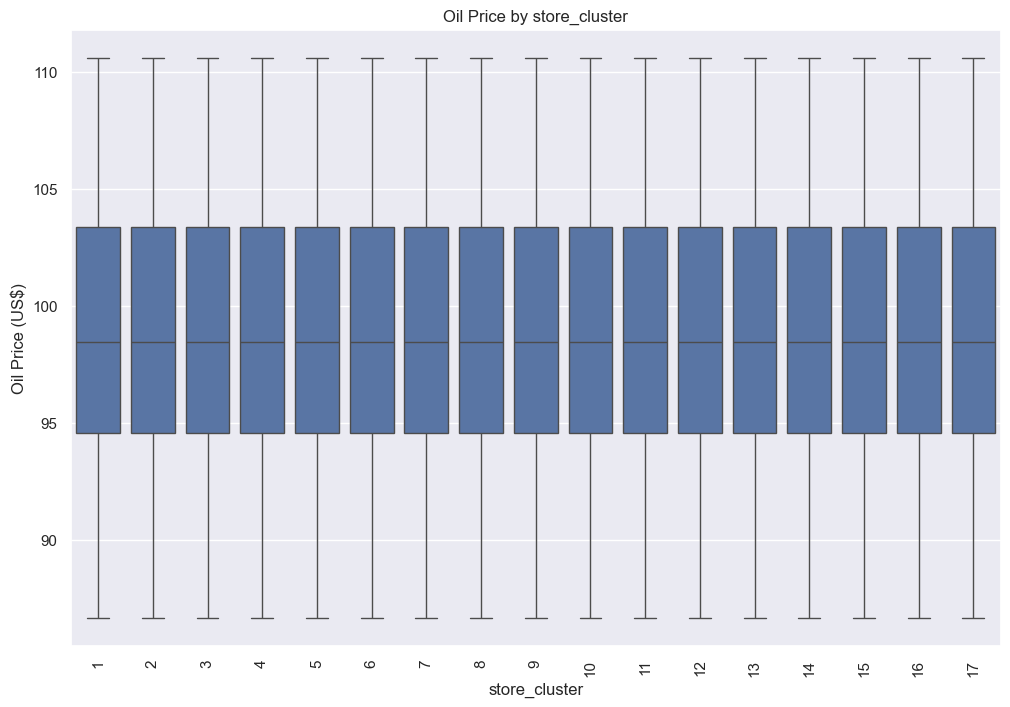

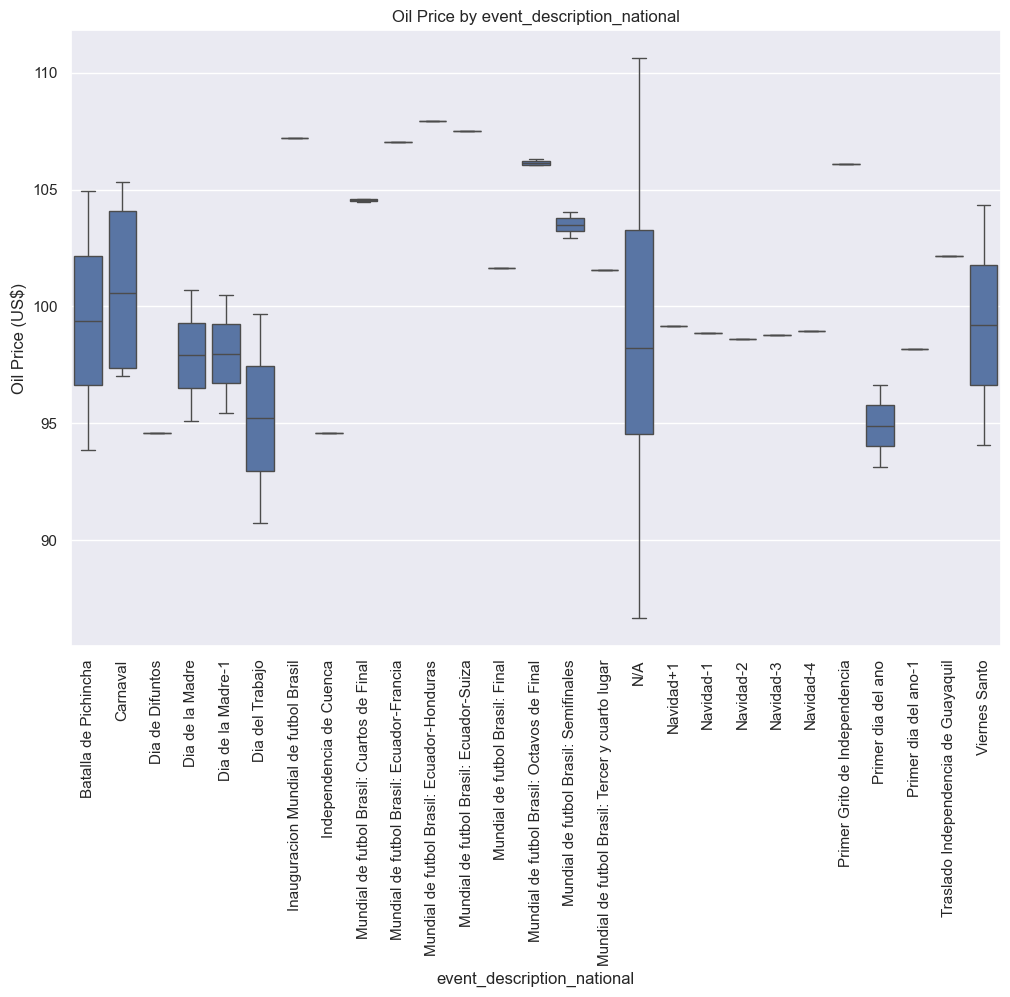

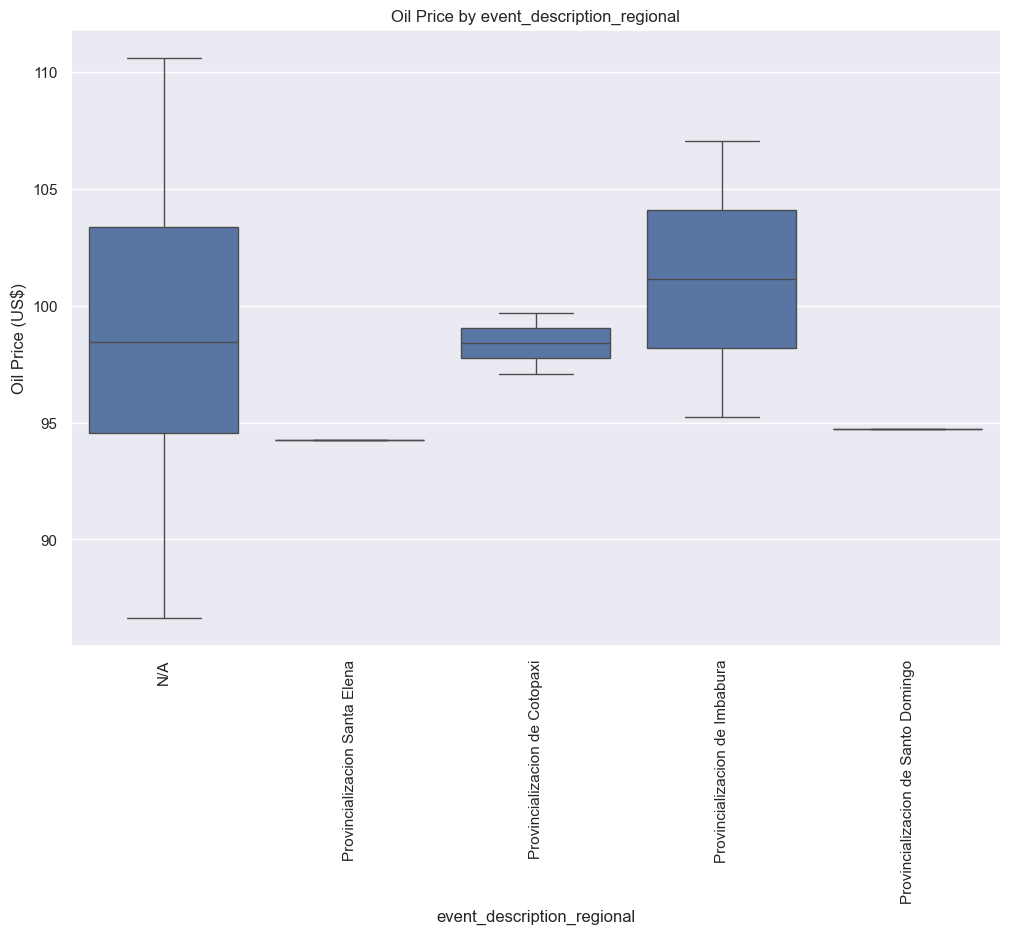

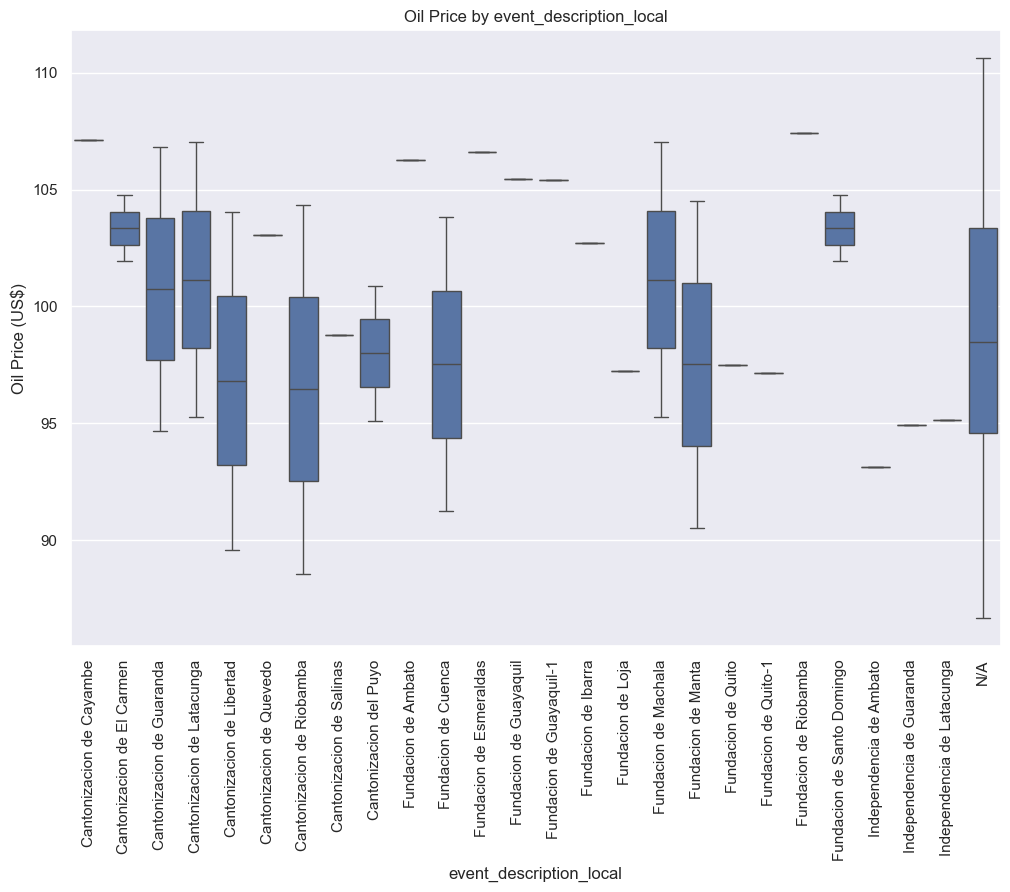

In [60]:
for categorical_var in categorical_features:
    df_oil_price_by_day = df_sales[df_sales['date'] < oil_price_downfall_period_start].groupby([categorical_var, 'date'])['dcoilwtico'].mean().reset_index()

    ax = sns.boxplot(
        data=df_oil_price_by_day,
        x=categorical_var,
        y='dcoilwtico'
    )

    ax.set_title(f'Oil Price by {categorical_var}')

    ax.set_xlabel(categorical_var)
    ax.set_ylabel('Oil Price (US$)')

    plt.xticks(rotation=90)

    plt.show()

#### 4. 2. 1. 2. During oil price downfall

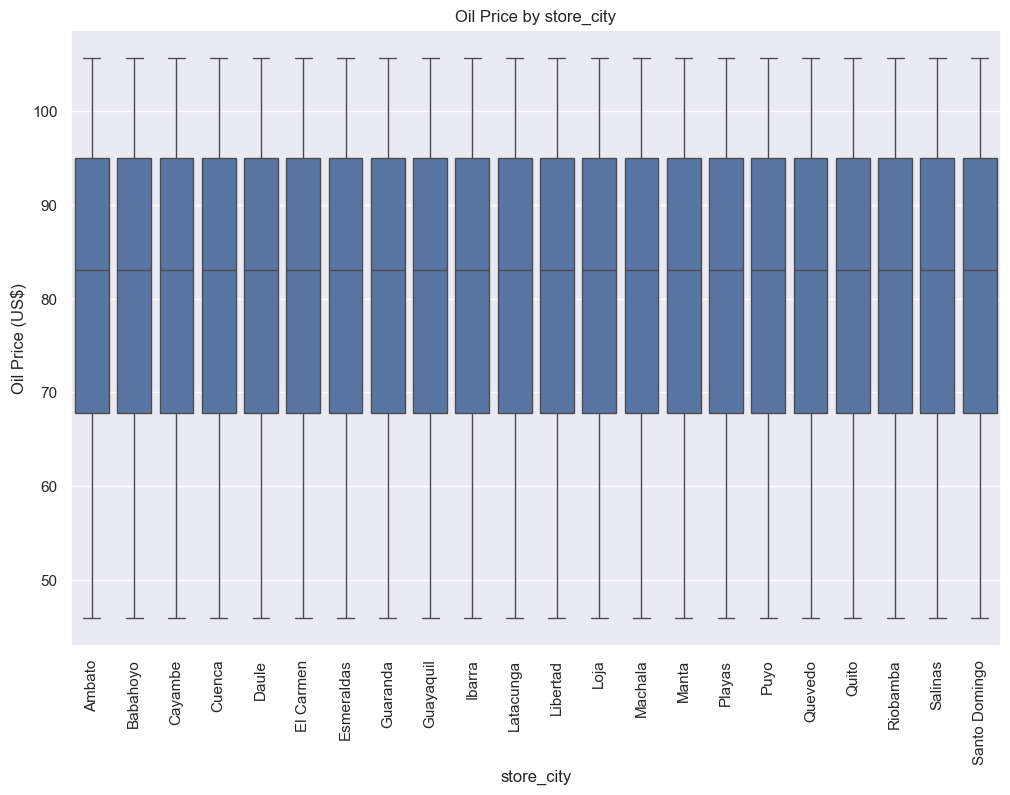

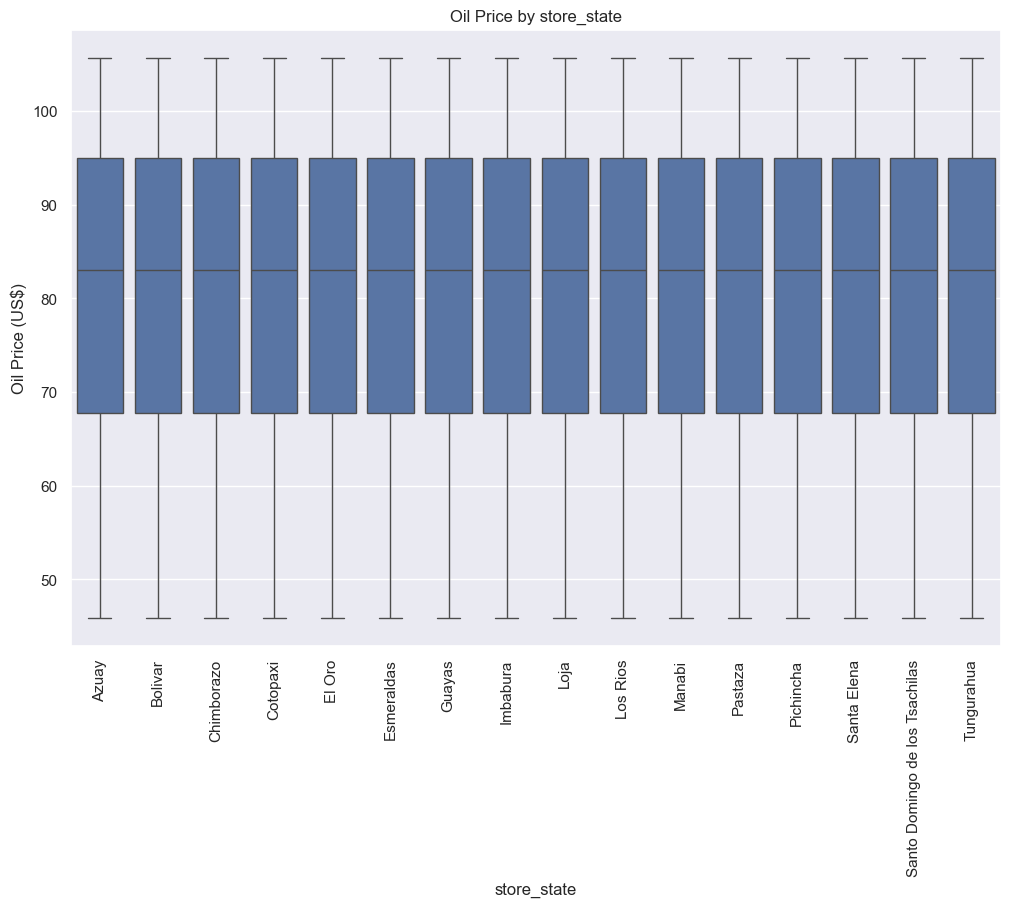

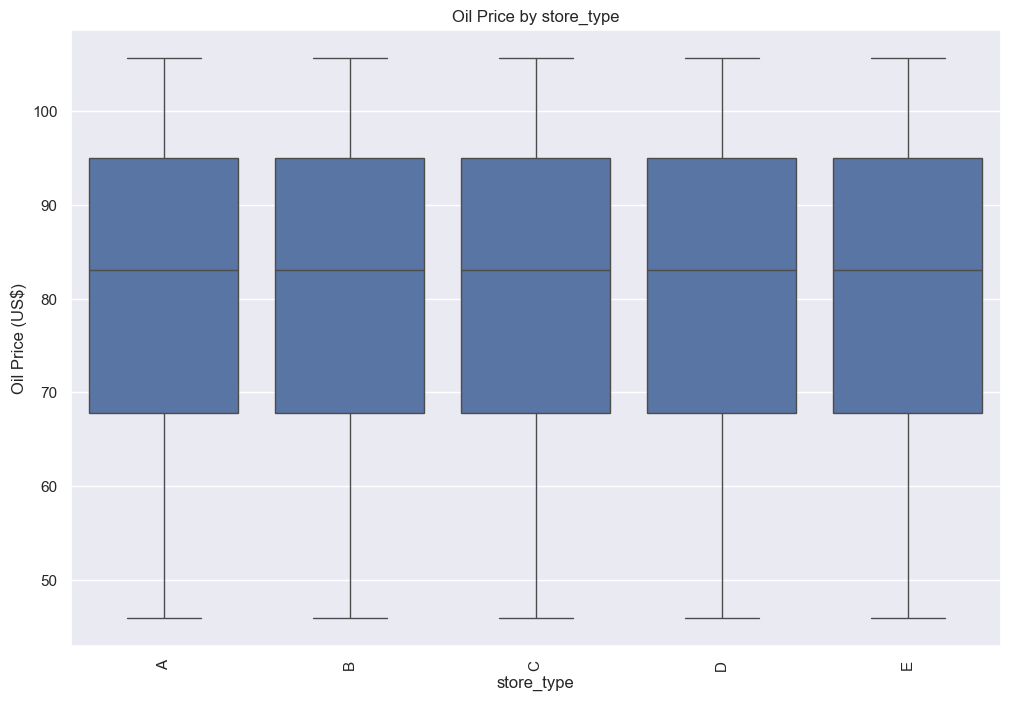

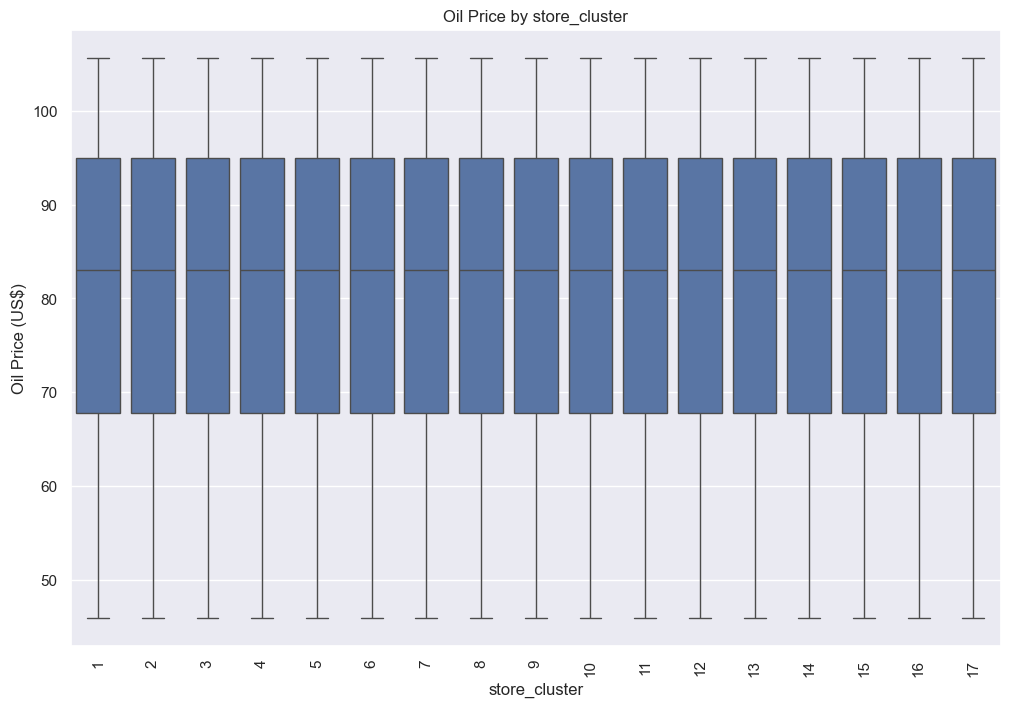

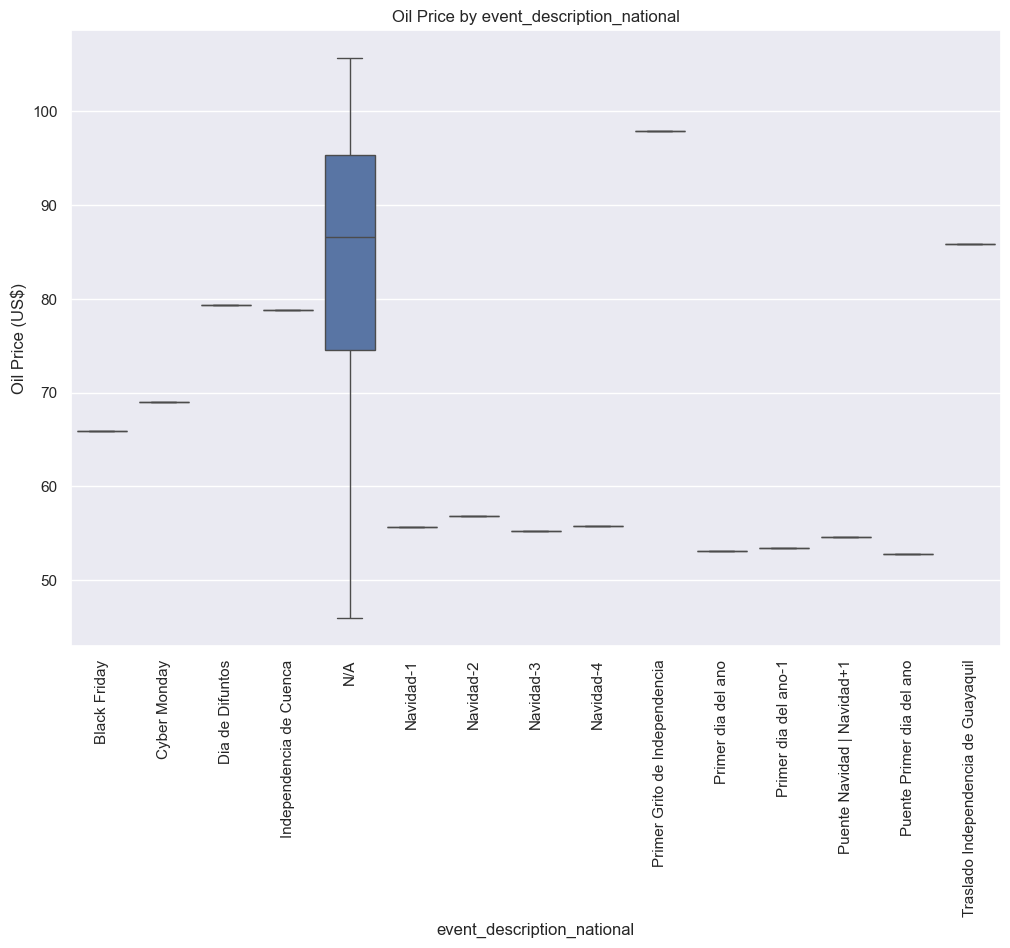

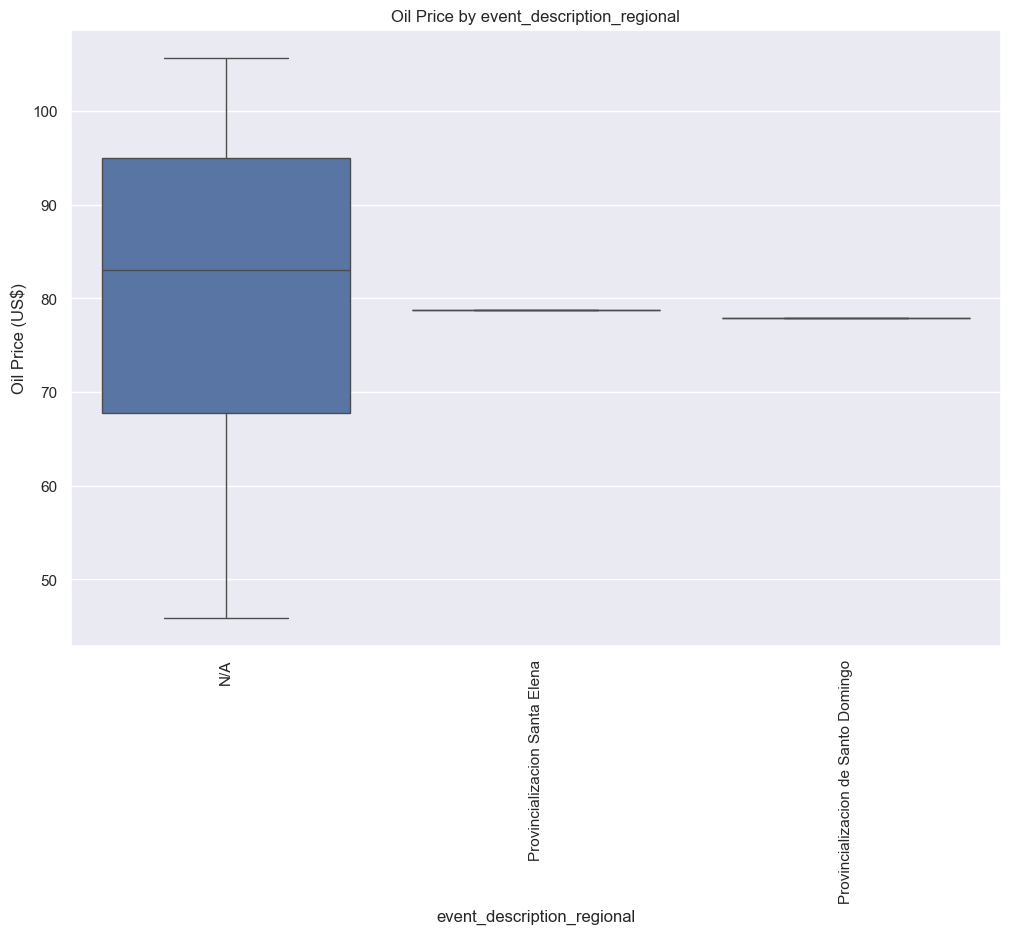

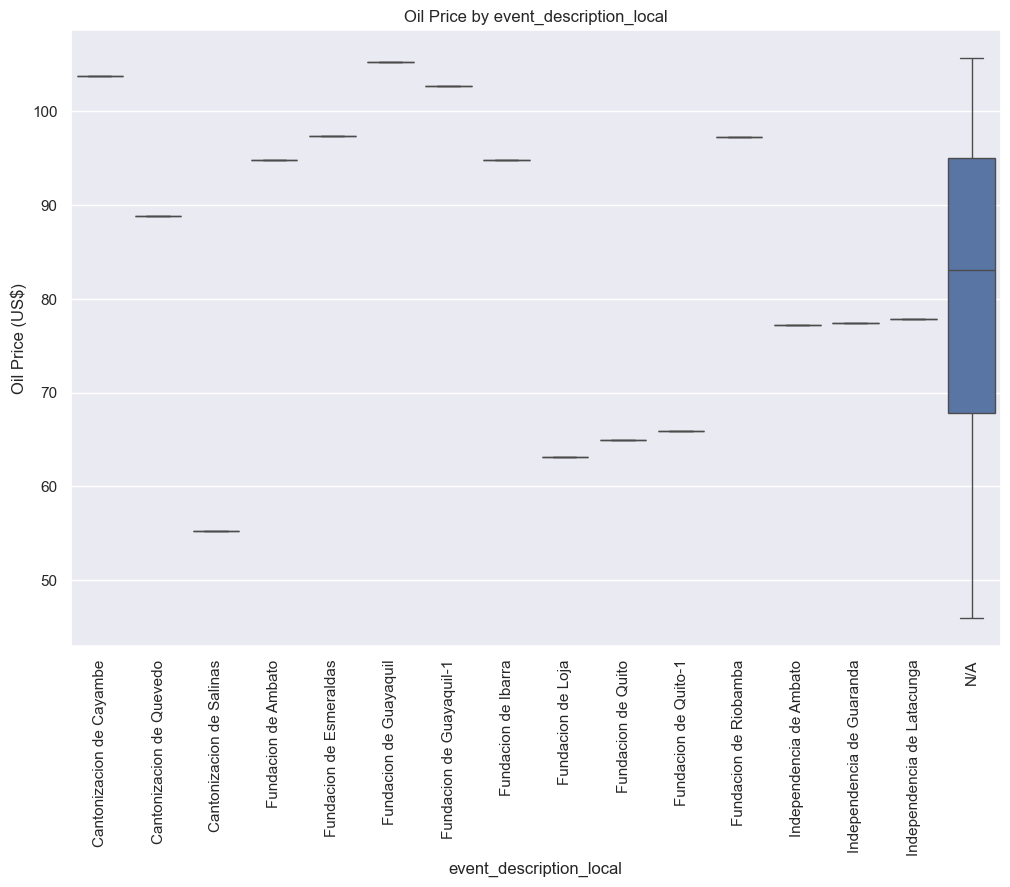

In [61]:
for categorical_var in categorical_features:
    df_oil_price_by_day = df_sales[df_sales['date'].between(oil_price_downfall_period_start, oil_price_downfall_period_end)].groupby([categorical_var, 'date'])['dcoilwtico'].mean().reset_index()

    ax = sns.boxplot(
        data=df_oil_price_by_day,
        x=categorical_var,
        y='dcoilwtico'
    )

    ax.set_title(f'Oil Price by {categorical_var}')

    ax.set_xlabel(categorical_var)
    ax.set_ylabel('Oil Price (US$)')

    plt.xticks(rotation=90)

    plt.show()

#### 4. 2. 1. 3. After oil price downfall

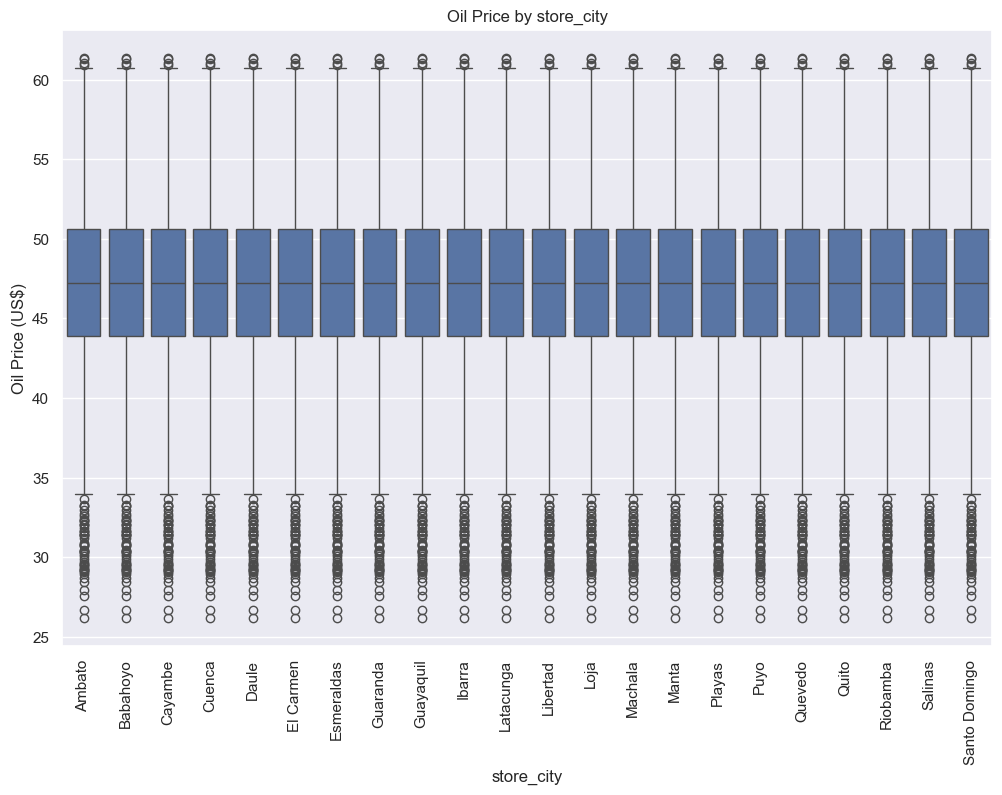

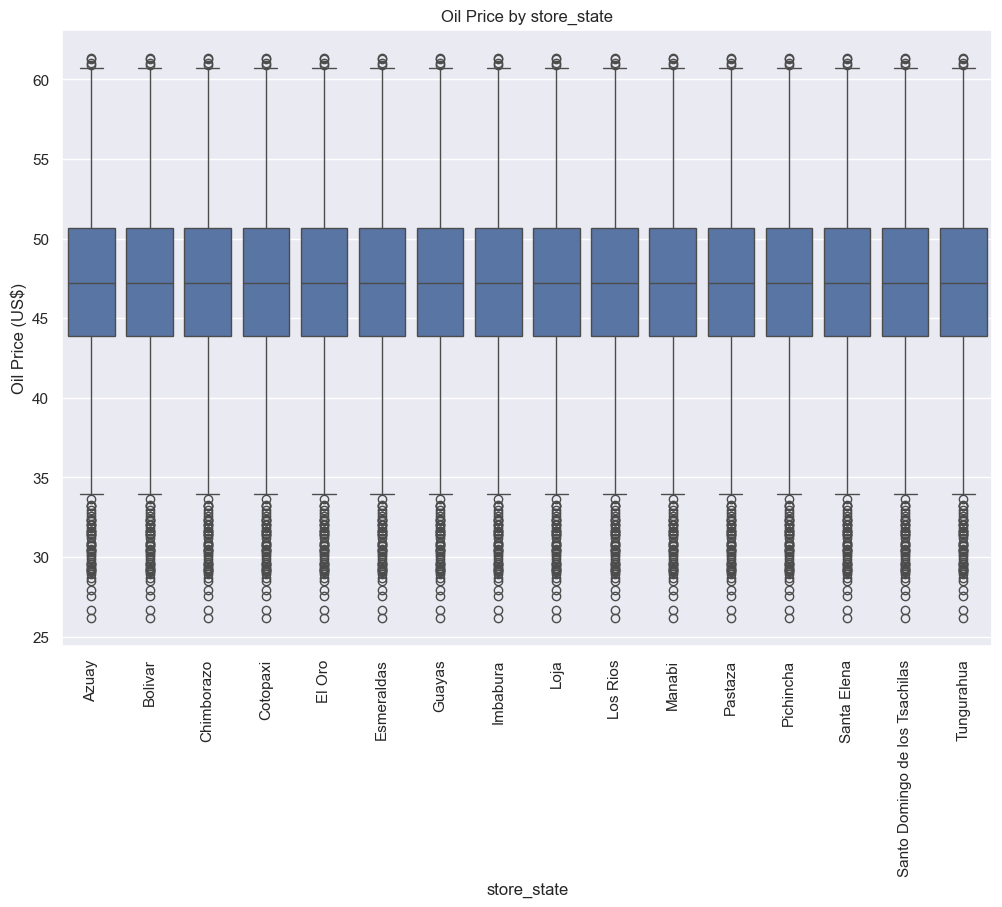

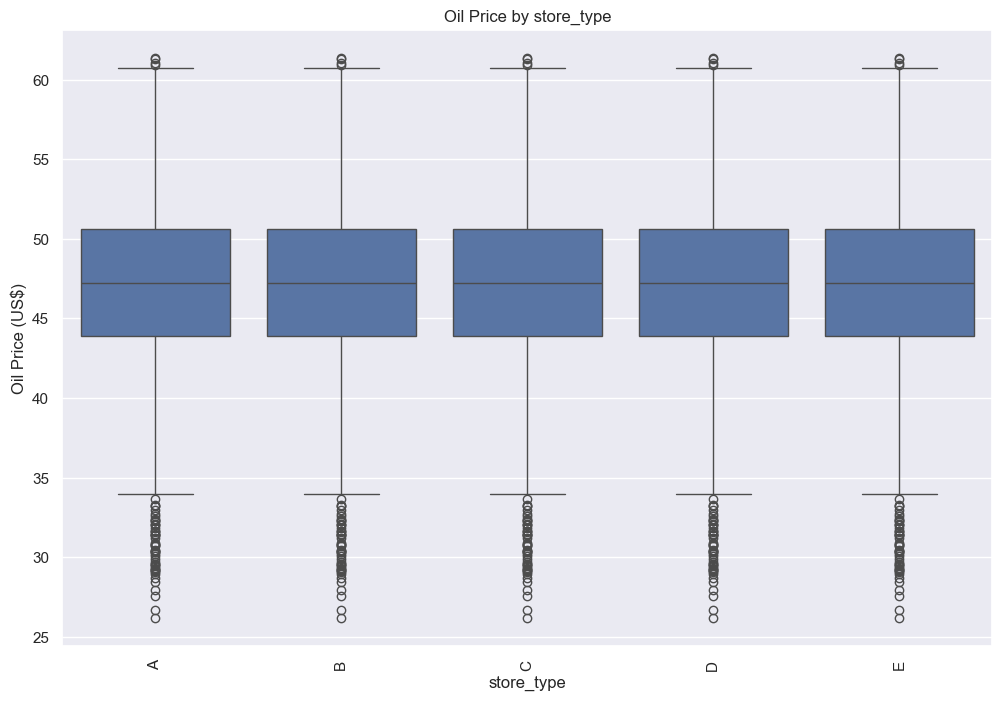

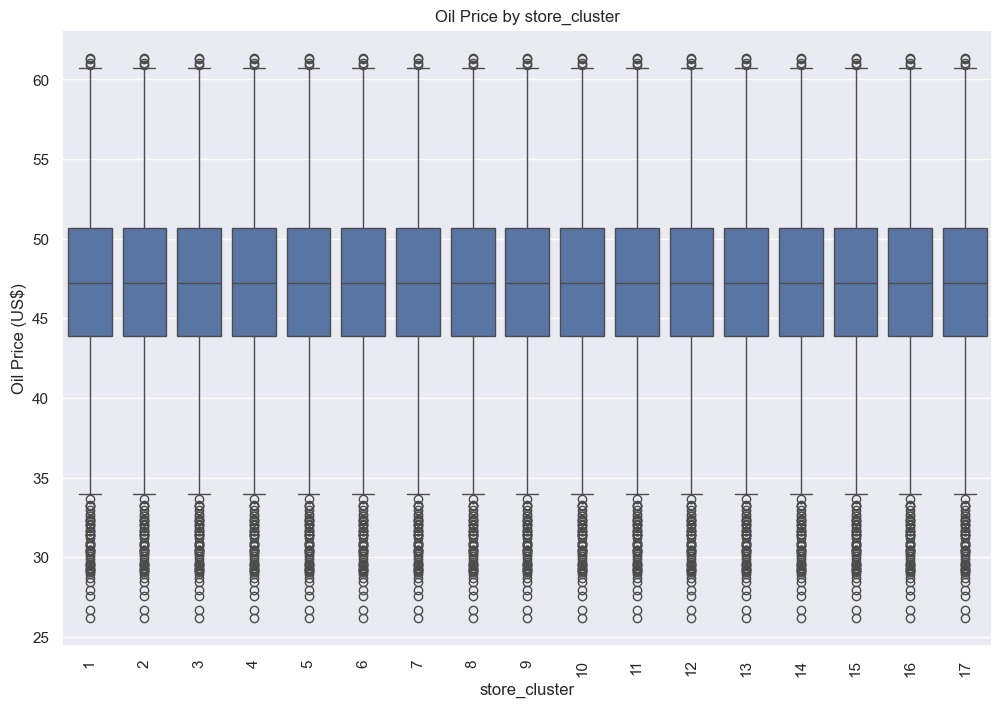

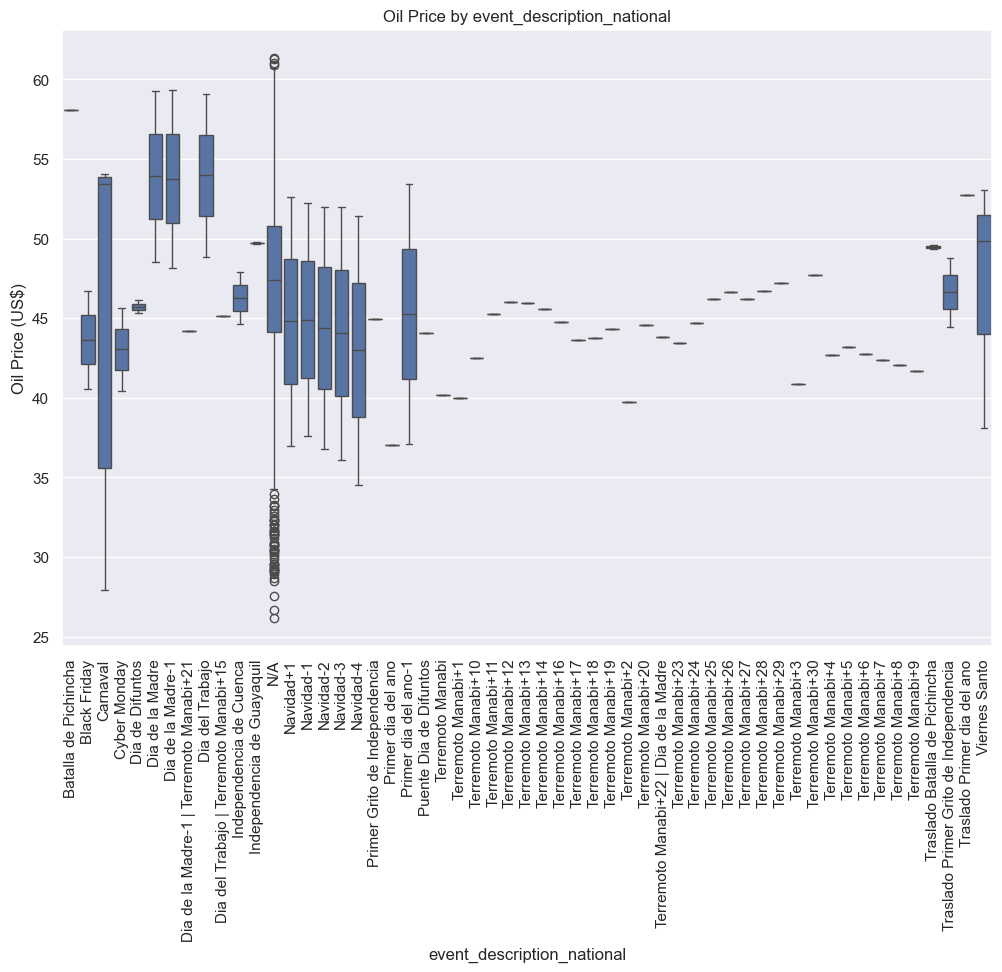

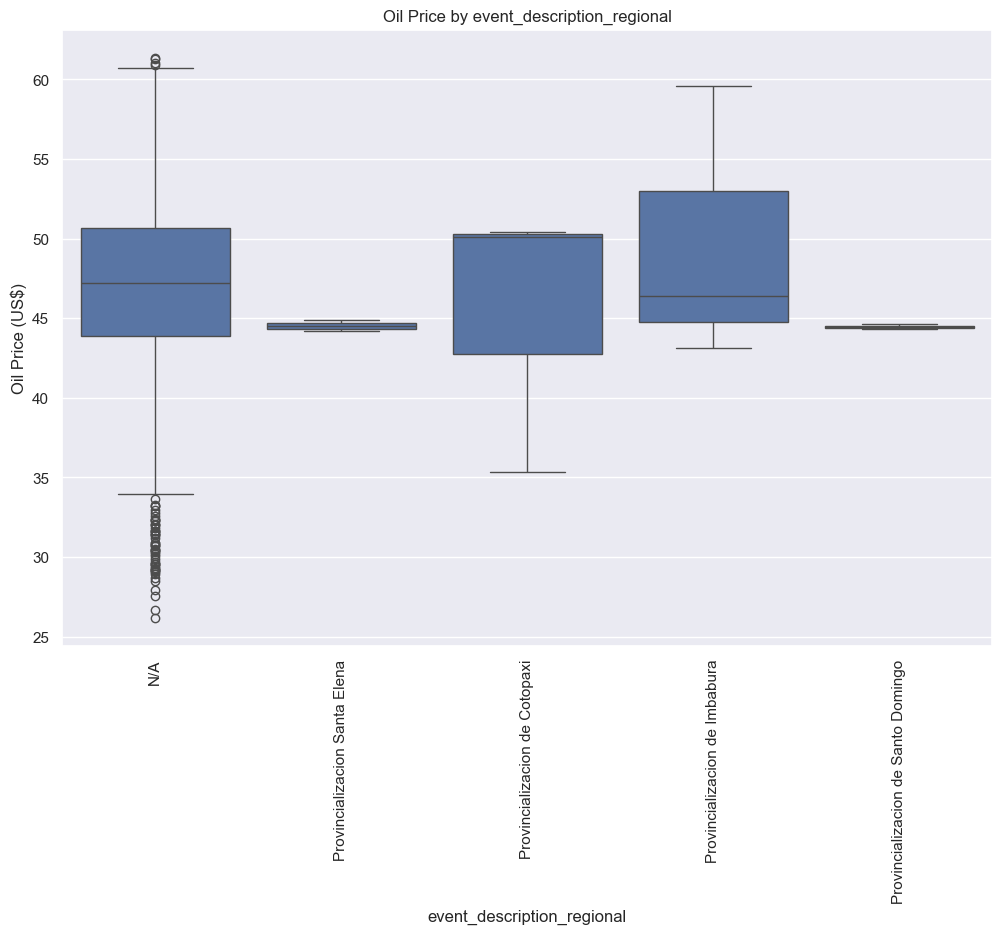

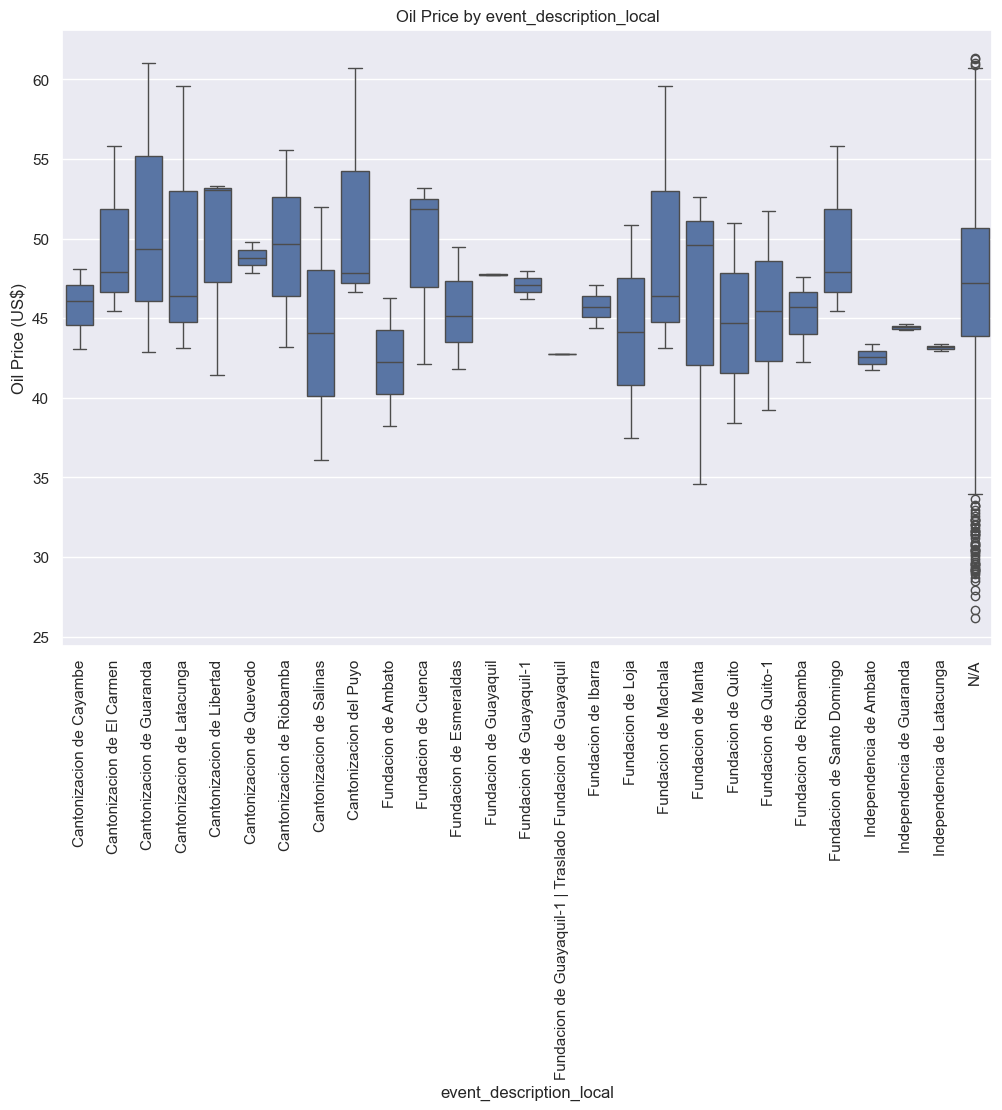

In [62]:
for categorical_var in categorical_features:
    df_oil_price_by_day = df_sales[df_sales['date'] > oil_price_downfall_period_end].groupby([categorical_var, 'date'])['dcoilwtico'].mean().reset_index()

    ax = sns.boxplot(
        data=df_oil_price_by_day,
        x=categorical_var,
        y='dcoilwtico'
    )

    ax.set_title(f'Oil Price by {categorical_var}')

    ax.set_xlabel(categorical_var)
    ax.set_ylabel('Oil Price (US$)')

    plt.xticks(rotation=90)

    plt.show()

The oil price only vary based on the events, but that's because the events happen in different days.

### 4. 2. 2. Promotion

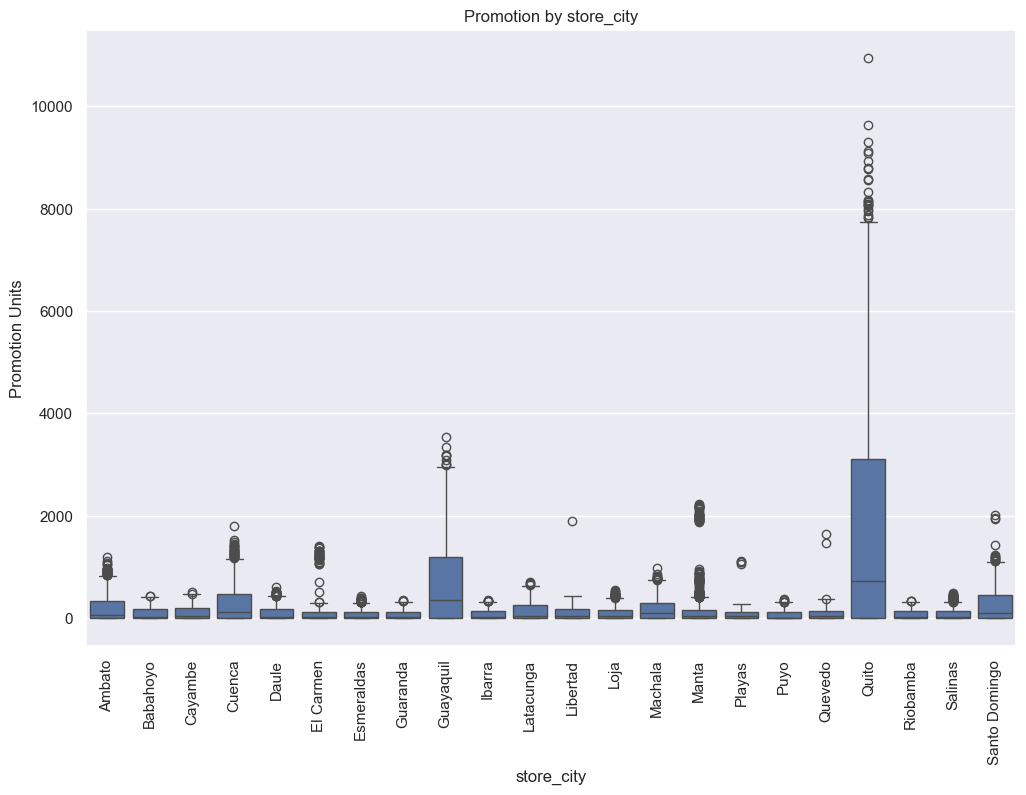

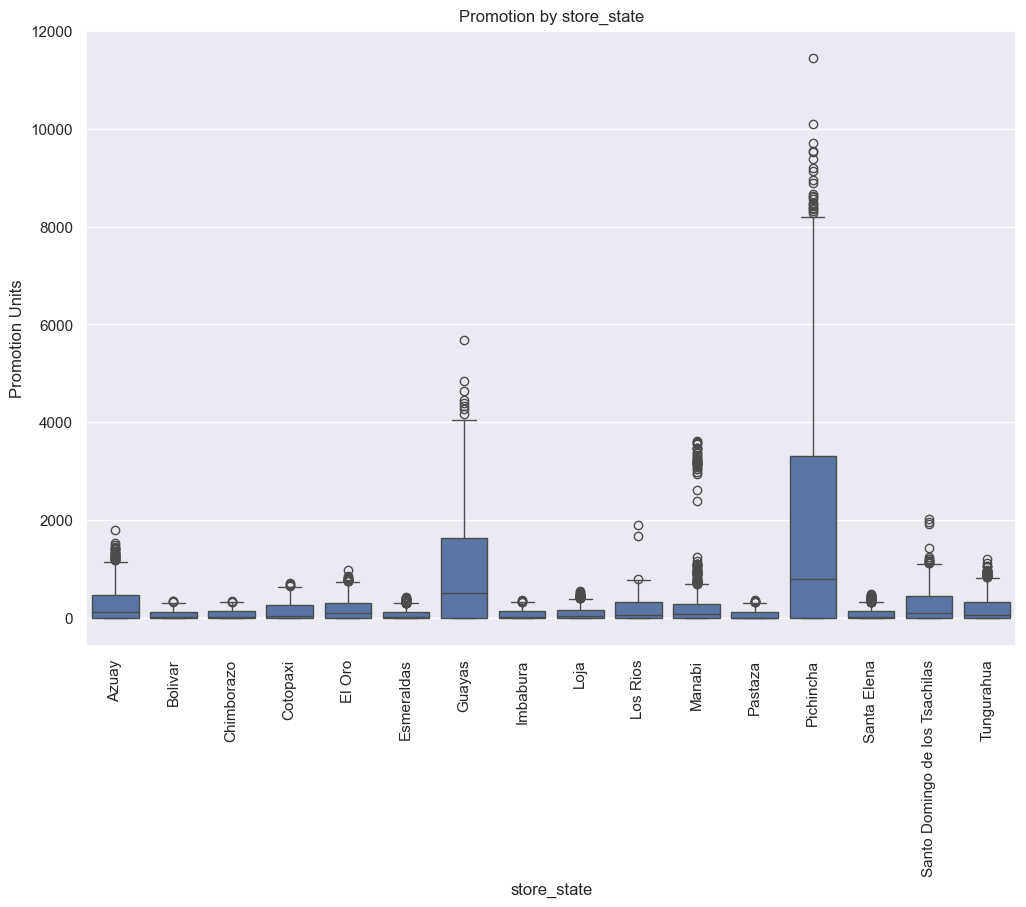

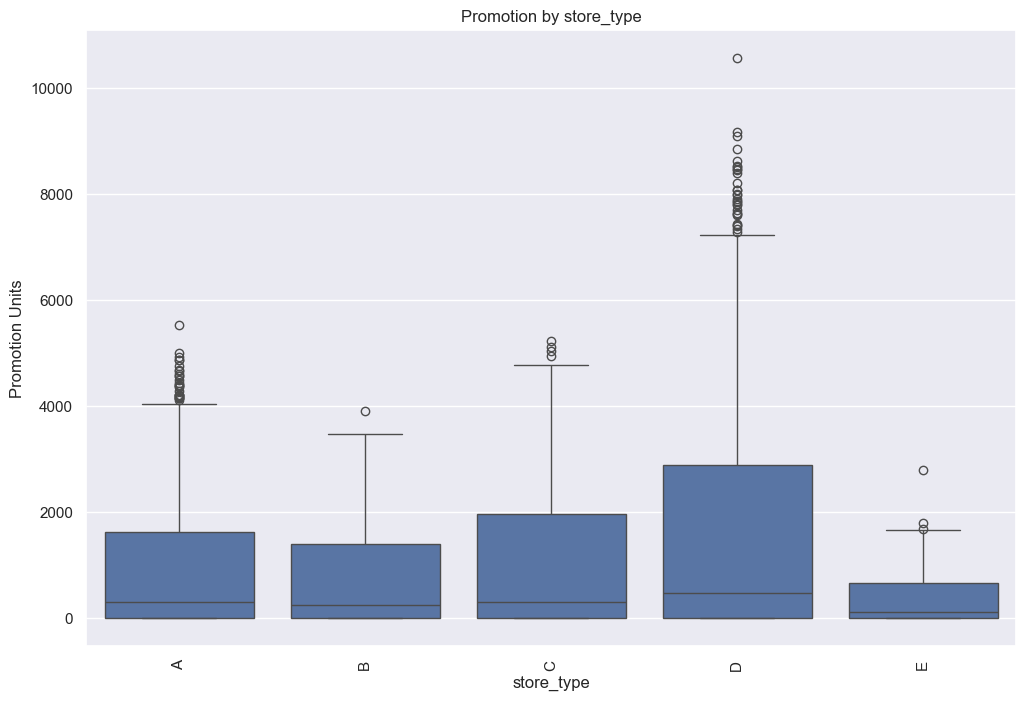

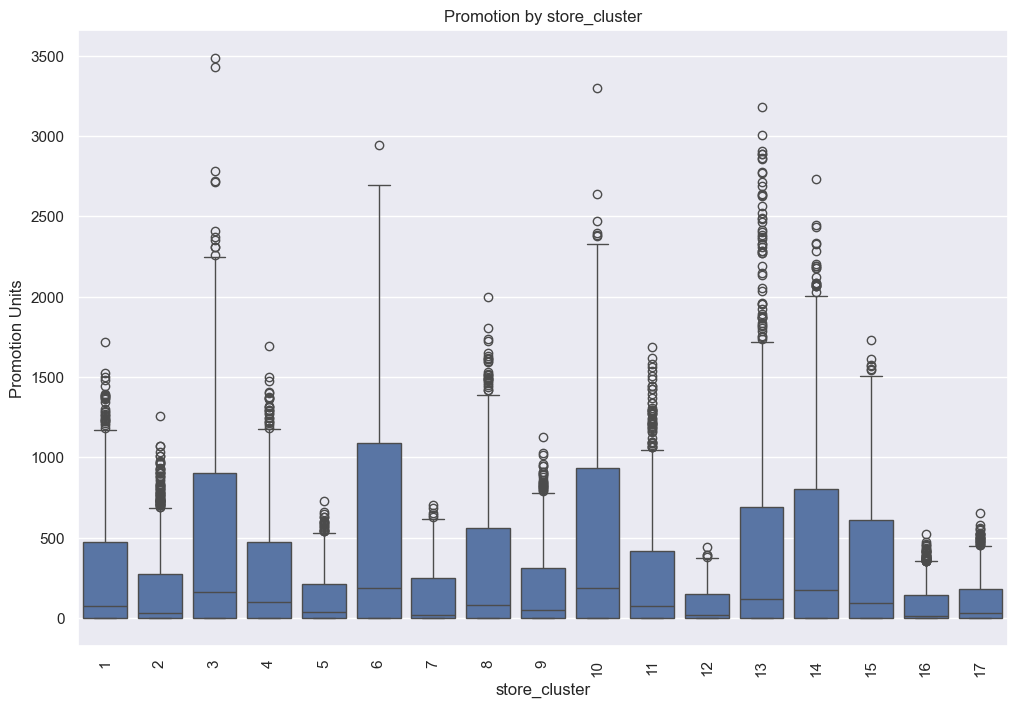

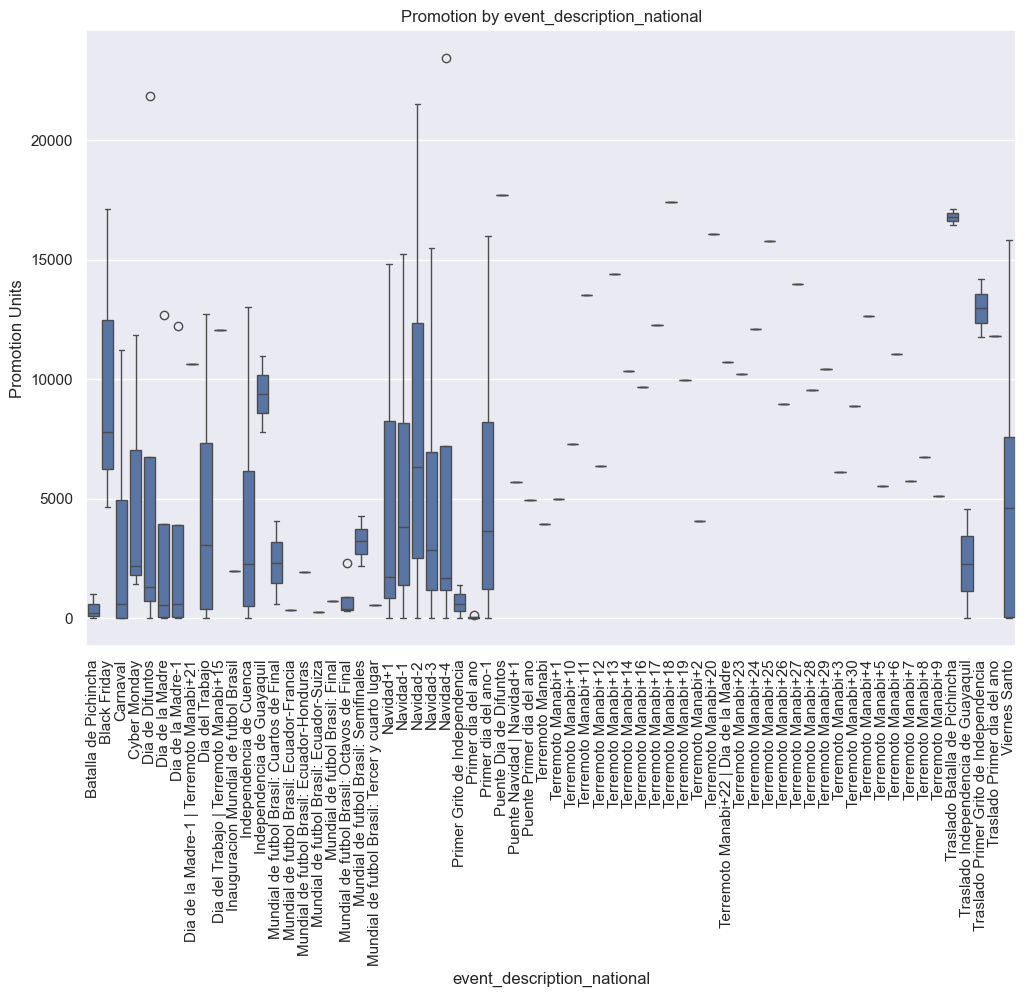

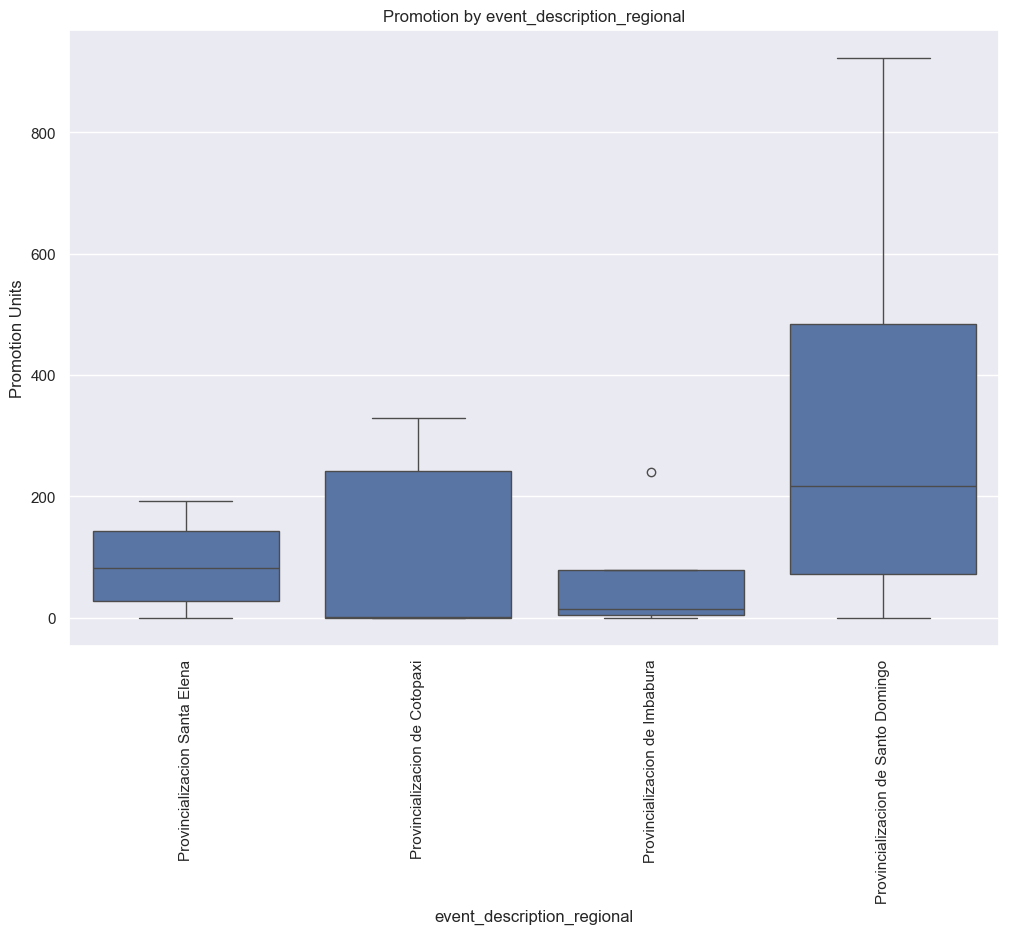

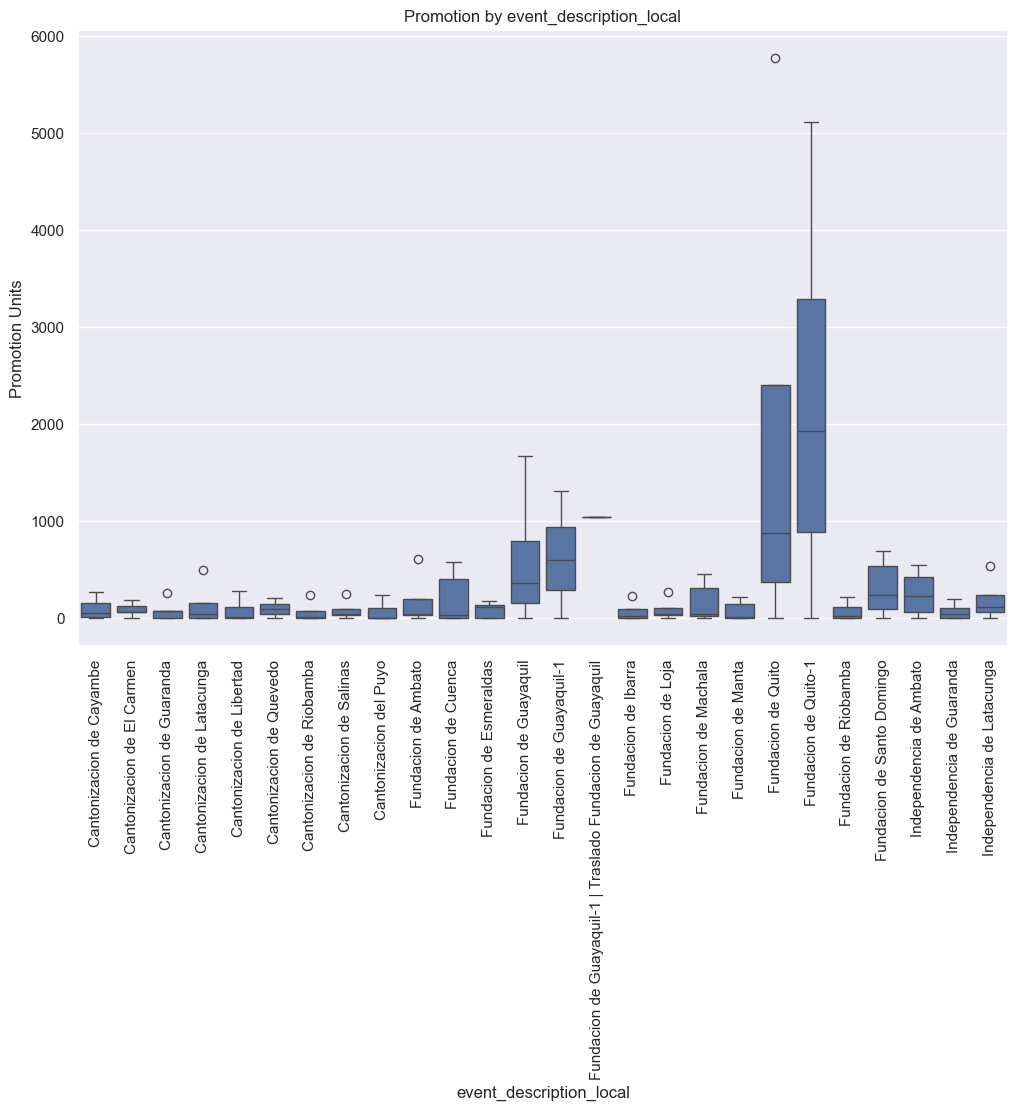

In [63]:
for categorical_var in categorical_features:
    df_promotion_by_day = df_sales.groupby([categorical_var, 'date'])['onpromotion'].sum().reset_index()
    
    ax = sns.boxplot(
        data=df_promotion_by_day if 'event_description' not in categorical_var else df_promotion_by_day[df_promotion_by_day[categorical_var] != 'N/A'],
        x=categorical_var,
        y='onpromotion'
    )

    ax.set_title(f'Promotion by {categorical_var}')

    ax.set_xlabel(categorical_var)
    ax.set_ylabel('Promotion Units')

    plt.xticks(rotation=90)

    plt.show()

We can see that there are more units on promotion on special events and in more important locations. Let's look at it on a table. 

In [64]:
df_sales.groupby(['store_state', 'store_city'])['onpromotion'].sum().reset_index().sort_values(by='onpromotion', ascending=False)

,store_state,store_city,onpromotion
18,Pichincha,Quito,2964961
7,Guayas,Guayaquil,1092838
0,Azuay,Cuenca,449329
20,Santo Domingo de los Tsachilas,Santo Domingo,407629
21,Tungurahua,Ambato,303104
4,El Oro,Machala,281383
15,Manabi,Manta,234830
3,Cotopaxi,Latacunga,221515
17,Pichincha,Cayambe,173787
8,Guayas,Libertad,158527


# 5. Summary

- there is a significant difference in the behavior of some features according to the period related to the oil price (before, during and after the downfall). Therefore it will be probably needed to have a dummy variable to indicate if a row refers to an observation before, during or after this event;
- the units on promotion's variable has a high positive correlation with the target variable, and therefore it must be used as a feature. The last analysis revealed that there are more unit on sales for more relevant locations/events;
- the series with a strong weekly seasonal component are the one with most sales. Therefore, it's essential to choose features and models that allow this pattern to be recognized. However, noisy/short series still make up a significant part of the sales. So it will probably be needed to choose different models for different types of series;
- there is a significant difference in sales all variables related to the stores: city, state, type, cluster. Therefore, if a single model will be trained for all the granularities, it is needed to use them as features;
- there is a significant correlation between stores' cities/states and their types/cluster. This may be a problem for some models if a single one is trained for all the granularities;
- there is a significant difference in sales in events (national, regional and local), and therefore they need to be used as features.